# ADFL Replication (Centralized) — PyTorch / Colab

Replication of **ADFL: Defending backdoor attacks in federated learning via adversarial
distillation** (Zhu et al., *Computers & Security* 132 (2023) 103366).

**Scope of this notebook (agreed with the user):**
- **Centralized, no FL protocol.** No virtual clients, no FedAvg, no adaptive-attacker
  learning-rate trick. Instead: train **one** model on a poisoned dataset to embed the
  backdoor, then apply ADFL's *server-side purification* to it.
- **Only ADFL** is implemented — the FoolsGold / CONTRA / Baffle baselines from the paper
  are intentionally skipped.
- Same **datasets** (MNIST, CIFAR-10, CelebA — the three datasets behind the paper's Figs.
  6-11) and **triggers** (pixel-block, watermark, WaNet-style invisible warp,
  attribute/semantic) as the paper, selected via one `CONFIG` dict below.
- This is **replication only** — no novel-attack scaffolding. A new trigger plugs in via
  `apply_trigger()` (Section: Trigger module) if it's a pixel-space perturbation, or via
  `choose_poison_indices()`/`attribute_subgroup_anchor()` (Section: Poisoned/clean dataset
  wrappers) if it instead changes WHICH images get poisoned, the way the semantic "attribute"
  trigger does.

**ADFL mechanism reproduced here (paper Section 5, centralized adaptation):**
1. Train a classifier on a poisoned dataset → *backdoored model* (embeds the backdoor).
2. Train a second classifier on a small **clean** subset the "server" holds (drawn from the
   test set, per the paper) → *clean / teacher model*.
3. **Distillation-data generation:** train a GAN whose loss is exactly the paper's Eq. 2/3 —
   a vanilla adversarial GAN, discriminator trained against the server's real clean holdout.
   The backdoor reaches the generator through exactly one channel, which *is* the paper's
   actual mechanism (not a guidance loss): the discriminator's trunk is periodically re-synced
   from the backdoored model's own weights (Algorithm 1's `D(x) ← G̃t`; paper Sec. 5.2:
   "update the discriminator with the global model of the **following rounds** ... to ensure
   that the backdoor samples can be generated"). See the Notes cell for why six earlier rounds
   of an invented classification-guidance loss were removed rather than tuned further.
4. **Relabeling:** the clean/teacher model labels the generated samples → the "distillation
   dataset" (paper uses 10,000 samples).
5. **Knowledge distillation:** the backdoored model (student) is purified by distilling from
   the clean model (teacher) on the distillation dataset (paper: 20 epochs), using the paper's
   exact Eq. 4-7 loss (softened cross-entropy + hard relabel CE, no KL, no T² factor).

**Run this in Google Colab** with a GPU runtime (Runtime → Change runtime type → GPU).
Everything below is self-contained; nothing needs to run outside Colab.


In [1]:
import random
import copy
import colorsys
import hashlib
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Re-baseline Phase 0 (speed foundation, see HANDOFF.md / the re-baseline plan): fixed input
# sizes per dataset (28/32/64) all session, so cuDNN's autotuner pays its search cost once and
# reuses the fastest conv algorithm for the rest of the run -- 1.5-2.5x on a T4. No accuracy
# effect; only wrong if input shapes vary between calls, which they don't here.
torch.backends.cudnn.benchmark = True
USE_AMP = device.type == "cuda"  # autocast/GradScaler are CUDA-only; CPU fallback stays fp32


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)



Using device: cuda


## 1. Configuration

Everything that varies across the paper's experiments (dataset, trigger type/size, clean
data fraction, distillation epochs, ...) is driven from this single dict. Flip values here
and re-run the notebook top to bottom to reproduce a different row of the paper's tables.

Live default below: **CIFAR-10, "attribute" (semantic) trigger** — automobile relabeled to
airplane on a coherent visual subgroup within the class (`attribute_subgroup="striped_wall"`),
per Table 2's "Attribute (CIFAR-10)" row. Four more presets are given in comments:
- MNIST pixel-block, **all-to-one** (`source_label=None` — a random subset of every class gets
  poisoned and relabeled to `target_label`), matching Table 2 / Fig. 9's original setting.
- MNIST pixel-block confusion-matrix demo (Fig. 8): 4x4 block, source `4` -> target `5`.
- MNIST watermark confusion-matrix demo (Fig. 8): source `1` -> target `7`, factor 0.3.
- CelebA attribute backdoor (Table 2's "Attribute (CelebA)" row) — attack definition still an
  open question, see the Notes cell.

Set `source_label` to a specific class instead of `None` to restrict poisoning to one source
class (as in the Fig. 8 presets, or the live CIFAR-10 default) rather than the general
all-to-one setting. `backbone` selects the classifier/discriminator architecture
("convtrunk" | "resnet18", Section 5) -- the paper's own spec differs by dataset.


In [2]:
CONFIG = {
    # data
    "dataset": "CelebA",        # "MNIST" | "CIFAR10" | "CelebA"
    # backbone (NOT in the paper as a per-dataset CONFIG switch, but the paper's OWN spec is
    # per-dataset -- Sec. 6.1.2: "network structures on the MNIST task and CIFAR-10 task are the
    # same in this experiment" (the Table 1 CNN, `ConvTrunk`), while "For the CeleBA dataset, we
    # use ResNet18 architecture as the classification network also being the discriminator."
    # "convtrunk" | "resnet18" -- see build_trunk() (Section 5). Classifier and Discriminator
    # both read this so the paper's weight-sync constraint (same trunk on both sides) always
    # holds regardless of which backbone is selected. CHANGED 2026-09-09 (re-baseline Phase 1):
    # "resnet18" for ALL THREE datasets, per Sec. 6.5.1's own statement about the Table 2 numbers
    # ("we used Resnet18 for classification tasks on all the datasets in comparison evaluations")
    # -- reversing the earlier "Table 1 CNN for MNIST/CIFAR-10" decision, made to protect
    # validated MNIST numbers before MNIST's own +12.8pp overshoot (see HANDOFF.md) showed there
    # was little to protect. "convtrunk" (the Table 1 CNN) stays reachable -- set this to
    # "convtrunk" directly, or uncomment a preset below and re-add "backbone": "convtrunk" to it.
    "backbone": "resnet18",
    "celeba_attrs": ["Heavy_Makeup", "Mouth_Slightly_Open", "Smiling"],  # Sec. 6.1.1's actual
                                  # CelebA task: an 8-class label from 3 concatenated binary
                                  # attributes (2^3 = 8), not a single binary attribute -- see
                                  # get_datasets (Section 2) / CelebAMultiAttr.
    "celeba_center_crop": 178,   # ADDED (re-baseline Phase 2): get_datasets (Section 2) was
                                  # resizing the raw 178x218 aligned JPEG straight to a square,
                                  # distorting the face aspect ratio -- the Section 2 markdown
                                  # already claimed "resized+center-cropped" while the code
                                  # didn't. 178 crops to CelebA's square-ish aligned face region
                                  # (matches the width) before resizing to celeba_size below.
    "celeba_size": 64,           # RAISED 32 -> 64 (re-baseline Phase 2). CORRECTED (2026-09-11
                                  # paper audit): this was framed as our own accuracy-chasing
                                  # choice, but it is actually PAPER-SPECIFIED -- Sec. 6.1.1:
                                  # "The input images were all resized into 64 x 64 pixels."
                                  # The 32x32 it replaced was a fidelity bug, not a faithful
                                  # baseline. Also true, and the reasoning originally given:
                                  # with ResNetTrunk's stem keeping torchvision's maxpool at
                                  # input_size>=64 (see ResNetTrunk, Section 5), 64x64 costs the
                                  # same as CIFAR-10's 32x32 from layer1 onward for 4x the input
                                  # information. In-memory cache cost: 183k x 3 x 64 x 64 uint8
                                  # ~= 2.25GB, comfortably under free Colab's ~12.7GB RAM. Both
                                  # this key and celeba_center_crop above are threaded through
                                  # CACHE_KEYS_BACKDOORED/TEACHER (Section 2) since they're not
                                  # otherwise part of what those artifacts hash on.
    "seed": 0,
    "clean_fraction": 0.20,      # REVERTED to 0.20 2026-09-10 (Phase 3 re-baseline
                                  # test failed): at 0.05 (paper's own Sec. 6.5.1 value)
                                  # teacher ACC dropped to 60.30% from 0.20's 72.43%,
                                  # and downstream After-ACC fell too (73.86% vs.
                                  # 77.14%/75.38% at 0.20), while still not collapsing
                                  # all the way to the old 37-44% plateau. Verdict: the
                                  # SGD/cosine teacher recipe fix was NOT fully sufficient
                                  # on its own -- clean_fraction still matters, partially.
                                  # User decision: keep 0.20 (not paper-faithful, but the
                                  # replication that actually works) over further tuning
                                  # at 0.05 or accepting the ACC cost.
                                  # Drawn from the TEST set, not train, per the paper ("extracts
                                  # ... data from testing datasets as clean samples", Sec. 6.2).
                                  # clean_test/asr_test always exclude these indices (Section 2).

    # trigger / backdoor
    # Live config (CHANGED 2026-09-06, CIFAR-10 phase closed -- see HANDOFF.md): paper Table 2's
    # "Attribute (CelebA)" row (Sec. 6.1, citing Bagdasaryan et al., 2020). Bagdasaryan's own
    # repo (ebagdasa/backdoor_federated_learning) has NO CelebA config at all -- confirmed by
    # fetching it directly, not assumed -- so unlike CIFAR-10's striped-wall indices, there is no
    # real published attack to anchor to here. The paper's own CelebA task (Sec. 6.1.1) is
    # separately a genuine 8-class Heavy-Makeup/Mouth-Slightly-Open/Smiling label with no stated
    # semantic-backdoor subgroup, contradicting Table 2's car-attribute row outright -- the
    # paper never reconciles this.
    #
    # User decision (asked directly, given no ground truth exists to recover): use a real
    # CelebA attribute NOT among celeba_attrs as the coherent visual subgroup marker within one
    # of the 8 combined-attribute classes -- structurally the same role Bagdasaryan's striped-
    # wall backdrop played for CIFAR-10 (a literal, physically visible marker, not a heuristic,
    # not the whole source class), just without a citable source for the exact choice. Picked
    # "Eyeglasses": a clear, literal, physically visible attribute with no obvious causal link to
    # Heavy_Makeup/Mouth_Slightly_Open/Smiling. `_celeba_subgroup_pool()` (Section 4) computes
    # the real (source_label AND Eyeglasses==1) index set directly from CelebA's own 40-attribute
    # annotations -- ground truth, not a proxy, same standard as Bagdasaryan's own indices.
    #
    # source_label=0 ((0,0,0): no heavy makeup, mouth not open, not smiling -- the "neutral"
    # combination) -> target_label=7 ((1,1,1): heavy makeup, mouth open, smiling -- its exact
    # opposite). An arbitrary but clean, easy-to-state pairing (same spirit as MNIST's "4"->"5"
    # Fig. 8 demo or CIFAR-10's automobile->airplane) -- not derived from real class-population
    # counts, since those aren't known until Section 4 actually runs against real CelebA data.
    # Revisit this pairing once Section 4's own pool-size printout (this notebook's standing gate
    # before trusting anything downstream, same discipline CIFAR-10's cell-11 check used) comes
    # back, if source_label=0's population turns out too small or too large to be sensible.
    #
    # UNLIKE CIFAR-10's Bagdasaryan indices (deliberately just 7 real images, an artificial
    # scarcity from hand-picking specific real photos), Eyeglasses is a real, moderately common
    # attribute -- expected to need neither `poison_repeat` boosting (no FL dilution to
    # compensate for a handful of images) nor the `poison_test_repeat`/augmentation quantization
    # workaround CIFAR-10's 5-image eval pool needed (Section 4's `attribute_subgroup_eval_source`
    # sources "eyeglasses"'s eval pool from the genuine held-out TEST set, not train, so it
    # should have plenty of real images without repetition). Both expectations need the real
    # printed pool sizes to confirm, not assumed correct here.
    "trigger": "attribute",      # "pixel" | "watermark" | "wanet" | "attribute"
    "trigger_size": 5,           # unused by "attribute" -- kept for the MNIST presets below
    "trigger_factor": 0.3,       # unused by "attribute" -- kept for the MNIST presets below
    "watermark_digit": 1,        # ADDED 2026-09-11: which MNIST digit build_watermark_template
                                  # (Section 3) stamps as the watermark image. Sec. 6.1.1's Table 2
                                  # experiment uses "1" (also the all-to-one target label below);
                                  # the earlier hardcoded "0" was Sec. 6.3/Fig. 7's generation-
                                  # quality illustration, not the Table 2 attack. Unused by the
                                  # live "attribute" trigger -- kept for the MNIST presets below.
    "source_label": 0,           # CelebA 8-class (0,0,0): no makeup, mouth closed, not smiling
    "target_label": 7,           # CelebA 8-class (1,1,1): makeup, mouth open, smiling
    "attribute_subgroup": "eyeglasses",  # selects which real attribute attribute_subgroup_anchor()
                                  # (Section 4) applies -- "striped_wall" (CIFAR-10, closed
                                  # 2026-09-06, see preset below) | "eyeglasses" (CelebA, live) |
                                  # None (whole-class, kept for the MNIST presets below, which
                                  # use source_label for unrelated reasons).
    "poison_rate": 0.53,         # CALIBRATED (Section 13b, 2026-09-14): sweep over
                                  # [0.53, 0.57] landed 0.53 -> ASR 58.70%+/-3.71% (in the
                                  # 57-61% target band) vs 0.57 -> ASR 71.22%+/-2.34% (overshoots);
                                  # earlier bracket was 0.45 -> 23.49%, 0.60 -> 72.47%, so the
                                  # response curve bends up faster than linear between 0.53 and 0.60.
    "poison_repeat": 1,          # NOT in the paper -- centralized boosting-proxy knob (see the
                                  # CIFAR-10 preset below for the full mechanism). Left at 1 (no
                                  # boosting) as a starting point since Eyeglasses is expected to
                                  # be a real, non-scarce subgroup, unlike CIFAR-10's deliberately
                                  # tiny 7-image pool that needed heavy repetition to reach a
                                  # meaningful before-ASR. Revisit once Section 4's pool size and
                                  # a first before-ASR reading come back -- may not need Section
                                  # 13b calibration at all if the natural subgroup size already
                                  # gives a reasonable before-ASR.
    "poison_test_repeat": 1000,  # Bagdasaryan's own key/value -- kept present but expected to be
                                  # a no-op for "eyeglasses" (Section 4's build_loaders only
                                  # applies this when attribute_subgroup_eval_source(cfg)=="train",
                                  # which "eyeglasses" is not -- its eval pool is real, sourced
                                  # from the genuine held-out TEST set). Still active for the
                                  # "striped_wall" CIFAR-10 preset below, which does need it.

    # -- alternative preset (this notebook's original MNIST replication target -- paper Table 2
    #    pixel-block 5x5, all-to-one; poison_rate calibrated across many sessions via Section
    #    13b's 3-seed sweep to match the paper's 57.76% before-ASR headline -- see HANDOFF.md):
    #    MOVED 2026-09-15 to "MNIST Table 2 preset overrides" near the end of this cell (right
    #    before the closing brace) -- Python dict literals resolve duplicate keys last-write-wins,
    #    and this preset's recipe overrides (clf_epochs/teacher_epochs/gan_epochs/kd_epochs/etc.)
    #    sit textually BEFORE the live classifier-training/generator/distillation section below,
    #    so from this position they were silently discarded (a real bug, caught 2026-09-15 before
    #    any Colab run). Uncomment the block at the end of this cell to restore this preset.


    # -- alternative preset (paper Fig. 8 pixel-block confusion-matrix demo, "4"->"5"): --
    # "dataset": "MNIST", "train_augment": False,
    # "distill_conf_floor": 0.0, "attribute_subgroup": None, "poison_repeat": 1,
    # "trigger": "pixel", "trigger_size": 4,
    # "source_label": 4, "target_label": 5, "poison_rate": 1.0,

    # -- alternative preset (paper Fig. 8 watermark confusion-matrix demo, "1"->"7"): --
    # "dataset": "MNIST", "train_augment": False,
    # "distill_conf_floor": 0.0, "attribute_subgroup": None, "poison_repeat": 1,
    # "trigger": "watermark", "trigger_factor": 0.3,
    # "source_label": 1, "target_label": 7, "poison_rate": 1.0,

    # -- alternative preset (paper Table 2 "Watermarking (MNIST)" row, trigger_size=0.3; Sec.
    #    6.1.1: "the attacker added the watermarking '1' ... and set its label as '1'" -- all-to-one.
    #    Target CONFIRMED against the source PDF directly (2026-09-15, `pdftotext -layout`, Table 2
    #    row): Before ASR 60.32% / ACC 83.57%, After ASR 0.53% / ACC 86.85%. poison_rate NOT YET
    #    CALIBRATED -- run Section 13b (calib_key="poison_rate") against 60.32%+/-2pp before
    #    trusting any number from this preset; placeholder below is a placeholder order of
    #    magnitude, not calibrated for this trigger. MOVED 2026-09-15 to "MNIST Table 2 preset
    #    overrides" near the end of this cell -- same reason as the pixel-5x5 preset above (see
    #    its pointer comment). Uncomment the block at the end of this cell to restore this preset.


    # -- alternative preset (CIFAR-10 "Attribute" row, Bagdasaryan et al. 2020's striped-wall
    #    subgroup attack; poison_repeat/poison_test_repeat/distill_conf_floor calibrated across
    #    many sessions -- CLOSED 2026-09-06 under "convtrunk": row D (Section 13a oracle)
    #    replicated the paper's After-ASR target (1.55% vs. 0.89%) but Before-ACC undershot by
    #    ~10pp (71.79% vs. 83.57%), diagnosed 2026-09-09 as an under-powered recipe, not this
    #    attack -- see HANDOFF.md. CHANGED 2026-09-09 (re-baseline Phase 1): no longer pins
    #    "backbone": "convtrunk", so this now re-baselines onto the live "resnet18" default and
    #    canonical SGD recipe below; poison_repeat=1 still needs re-checking once ACC is settled
    #    (re-baseline Phase 4) since it was calibrated under the old backbone.
    #    uncomment to restore --
    "dataset": "CIFAR10", "train_augment": True,
    "distill_conf_floor": 0.5,
    "trigger": "attribute", "trigger_size": 5, "trigger_factor": 0.3,
    "source_label": 1, "target_label": 0, "attribute_subgroup": "striped_wall",
    "poison_rate": 1.0, "poison_repeat": 1, "poison_test_repeat": 1000,

    # classifier training
    "batch_size": 128,
    "clf_epochs": 60,              # CHANGED 2026-09-10 (re-baseline Phase 1 checkpoint, CelebA
                                   # 64x64/ResNet18/SGD): first real run at 30 epochs came back
                                   # Before-ACC 77.90% vs. the paper's 84.05% -- improved from
                                   # 74.71% pre-re-baseline but still short, and the loss curve
                                   # (1.4458->0.4410) was still descending steadily at epoch 30,
                                   # not flattening despite cosine annealing lr toward zero --
                                   # the same under-epoched signature that blocked the teacher
                                   # before teacher_epochs 20->100 fixed it (see teacher_epochs
                                   # above). Doubled as a first retest, mirroring that fix, not a
                                   # search. History (was 30, CIFAR-10-specific fix, was 5,
                                   # MNIST's value): the first CIFAR-10 run came back Before-ACC
                                   # 64.28% vs. the paper's 83.57% target, with loss still
                                   # declining at epoch 5/5 (1.56->1.04, nowhere near flat) -- a
                                   # genuinely underfit model, not a calibration issue.
    "clf_lr": 0.1,                # CHANGED 2026-09-09 (re-baseline Phase 1): the canonical
                                   # CIFAR-ResNet SGD recipe uses lr=0.1 -- the 2026-09-05
                                   # "SGD is refuted" finding below used the TEACHER at 1e-3/
                                   # 1e-2, 10-100x lower than this; that finding stands for the
                                   # teacher's own tuned lr (0.05, see teacher_lr below) but was
                                   # never evidence against SGD for the classifier at its
                                   # canonical lr, which was never tried before now.
    "clf_optimizer": "sgd",      # CHANGED 2026-09-09 (re-baseline Phase 1): "adam" -> "sgd".
                                  # NOT in the paper (no optimizer named at all) -- "adam" |
                                  # "sgd", with clf_momentum/clf_weight_decay/clf_cosine/
                                  # clf_nesterov below. Only wired into the main run and
                                  # pipeline()/run_experiment() (Sections 6/12). 13b's classifier
                                  # sweep deliberately keeps plain Adam fixed for controlled
                                  # comparisons across its sweep values. 13a's ladder FORWARDS
                                  # these optimizer kwargs (FIXED 2026-09-15 -- it used to default
                                  # to Adam at clf_lr=0.1/teacher_lr=0.05, the same NaN-divergence
                                  # bug 13b had before its own 2026-09-11 fix), so it now trains
                                  # under CONFIG's live recipe, not a silently different one.
    "clf_momentum": 0.9,         # only used when clf_optimizer == "sgd"
    "clf_nesterov": True,        # ADDED 2026-09-09 (re-baseline Phase 1) -- canonical recipe;
                                  # only used when clf_optimizer == "sgd"
    "clf_weight_decay": 5e-4,    # CHANGED 2026-09-09 (re-baseline Phase 1): 0.0 -> 5e-4,
                                  # canonical CIFAR-ResNet value. Used by both optimizers.
    "clf_cosine": True,          # CHANGED 2026-09-09 (re-baseline Phase 1): False -> True --
                                  # cosine-anneal clf_lr over clf_epochs.
    "teacher_epochs": 100,        # CHANGED 2026-09-09 (re-baseline Phase 1): 20 -> 100. The
                                   # teacher trains on ~2,000 images; at 20 epochs that's ~40k
                                   # sample-presentations against the backdoored model's
                                   # 50,000x30 = 1.5M -- drastically under-trained in absolute
                                   # terms, not just data-starved. The prior "ACC barely moved,
                                   # 20->40 epochs" test (see teacher_lr below) ran under plain
                                   # Adam with no schedule, which plateaus by construction --
                                   # not evidence against more epochs under a real schedule.
                                   # 100 epochs on ~2k images is still ~1/7th the backdoored
                                   # model's budget. CIFAR-10-specific history: first run came
                                   # back Before-ACC 64.28% vs. the paper's 83.57%, still
                                   # declining at epoch 5/5 -- genuinely underfit, not a
                                   # calibration issue.
    "teacher_lr": 0.05,           # CHANGED 2026-09-09 (re-baseline Phase 1): 1e-3 -> 0.05. The
                                   # 2026-09-05 "SGD+cosine refuted" finding tried 1e-3 (loss
                                   # stuck near ln(10)=2.303, ACC 21.86%) and 1e-2 (loss
                                   # descending, 2.25->1.74, ACC 31.23%) -- CORRECTED 2026-09-09:
                                   # both are 2-200x below the canonical CIFAR-ResNet lr=0.1: SGD
                                   # not moving at 1e-3 is expected behavior at that lr, not
                                   # evidence against SGD itself. 0.05 (half the classifier's
                                   # 0.1, since the teacher trains on far less data) is the first
                                   # genuinely-canonical-range attempt. Record superseded, not
                                   # reproduced, by this change -- do not read the two ACC
                                   # numbers above as still describing "SGD" generally.
    "teacher_optimizer": "sgd",   # CHANGED 2026-09-09 (re-baseline Phase 1): "adam" -> "sgd" --
                                   # see teacher_lr above for why the earlier refutation doesn't
                                   # apply at the canonical lr.
    "teacher_momentum": 0.9, "teacher_weight_decay": 5e-4,  # CHANGED 2026-09-09: weight_decay
                                  # 0.0 -> 5e-4 (canonical CIFAR-ResNet value, re-baseline Phase 1)
    "teacher_nesterov": True,    # ADDED 2026-09-09 (re-baseline Phase 1) -- canonical recipe;
                                  # only used when teacher_optimizer == "sgd"
    "teacher_cosine": True,      # CHANGED 2026-09-09 (re-baseline Phase 1): False -> True, see
                                  # teacher_lr above -- the earlier SGD+cosine refutation was a
                                  # mis-tuned-lr test, not a cosine-schedule problem.
    "train_augment": True,        # NOT in the paper -- standard CIFAR-10 augmentation (random
                                   # crop + horizontal flip, TriggerDataset/build_loaders,
                                   # Section 2/4), added after teacher_epochs=20 confirmed the
                                   # teacher's low ceiling (~38% ACC) isn't an overfitting-from-
                                   # too-many-epochs problem -- 1000 raw CIFAR-10 images just
                                   # isn't enough signal without it. Applied only to datasets the
                                   # model TRAINS on (train_pool, clean_holdout); clean_test/
                                   # asr_test stay deterministic. Safe for the live "attribute"
                                   # trigger (no pixel component to disturb); if a pixel/
                                   # watermark/wanet CIFAR-10 preset is used later, the trigger
                                   # is applied AFTER augmentation (TriggerDataset.__getitem__)
                                   # so it still lands at its fixed final position, matching
                                   # standard practice. False for the MNIST presets below --
                                   # unneeded there and would invalidate already-validated
                                   # numbers if silently turned on.

    # ADFL step 1: GAN. Loss is the paper's Eq. 2/3 -- vanilla GAN, nothing else (see Notes
    # cell for why every earlier "guidance loss" experiment here has been removed). The
    # backdoor reaches the generator through exactly one channel: the discriminator's trunk is
    # periodically re-synced from the backdoored model's own weights (Section 8), matching
    # Algorithm 1's `D(x) <- G~t` and the paper's "update the discriminator with the global
    # model of the FOLLOWING rounds ... to ensure that the backdoor samples can be generated"
    # (Sec. 5.2).
    "latent_dim": 100,
    "gan_epochs": 100,           # RAISED 30 -> 100 (Phase 4 step 4b, 2026-09-11): with
                                  # gan_steps_per_epoch also raised below, this targets
                                  # ~25,000 total generator updates -- a DCGAN typically needs
                                  # 20,000-40,000; the previous 30x50=1,500 was ~4% of that,
                                  # explaining the "colorful static" Section 8 snapshots at
                                  # every epoch tried so far, including H3's 90/180-epoch
                                  # variants (4,500/9,000 steps -- also pre-convergence). See
                                  # Notes cell's generator-fidelity finding for why H1/H2/H3's
                                  # 2026-09-06 closure was reopened.
    "gan_steps_per_epoch": 250,  # RAISED 50 -> 250 (Phase 4 step 4b) -- see gan_epochs above.
    "gan_lr": 2e-4,
    "d_resync_every": 1,         # LOWERED 5 -> 1 (Phase 4 step 4b): re-sync D's trunk from the
                                  # next backdoored-model checkpoint every N GAN epochs -- the
                                  # centralized substitute for FL's per-communication-round
                                  # re-aggregation (agreed with the user over reintroducing
                                  # FedAvg). d_resync_every is counted in EPOCHS, not steps --
                                  # holding the original resync CADENCE constant in steps
                                  # (5*50=250) after raising gan_steps_per_epoch to 250
                                  # requires this to drop to 1 (1*250=250); leaving it at 5
                                  # would silently stretch the interval to 1,250 steps and
                                  # confound the gan_epochs/gan_steps_per_epoch change above.
                                  # See Section 6 for where the checkpoints are captured.
    "gan_snapshot_every": 5,     # capture an unconditional G(z) sample grid every N epochs
    "d_trunk_frozen": False,      # Section 13c H2 probe knob: when True, D's trunk trains
                                  # only via the periodic re-syncs above, never via opt_d/
                                  # backprop -- see sync_discriminator_trunk() and
                                  # train_generator (Section 8). Default False = original,
                                  # unchanged behavior.
    # Phase 4 knobs (2026-09-11, NOT in the paper) -- all default to a no-op below; try ONE AT
    # A TIME, gated on Section 8's snapshot grid (visual: recognizable faces, not ASR) if
    # step 4b's longer GAN run alone doesn't converge. See train_generator (Section 8) for how
    # each is wired in, and the Notes cell for the full generator-fidelity diagnosis.
    "gan_d_lr": None,            # step 4c: separate (lower) D learning rate, e.g. 1e-4, to
                                  # stop D overwhelming G (logged d_loss 0.027-0.236 -- D
                                  # winning near-perfectly). None = same as gan_lr (original).
    "gan_g_steps_per_d_step": 1, # step 4c: extra G updates per D step, same target as gan_d_lr.
    "gan_label_smoothing": 0.0,  # step 4c: one-sided smoothing on D's real targets (e.g. 0.1),
                                  # same target. 0.0 = original (hard 1.0 real labels).
    "gan_diffaug": False,        # step 4d: differentiable augmentation (_diffaug(), Section 8)
                                  # applied identically to both D branches -- targets D
                                  # memorizing the ~4k-image real clean-holdout set (small-data
                                  # GAN discriminator overfitting). False = original.
    "d_resync_alpha": None,      # step 4e (only once images are coherent -- targets trigger
                                  # TRANSFER, not image quality): blend factor for periodic D
                                  # trunk resyncs (sync_discriminator_trunk, Section 8),
                                  # approximating FedAvg dilution without reintroducing FedAvg.
                                  # None/1.0 = original hard overwrite. 0.1-0.3 = soft blend.

    # ADFL steps 2-3: relabeling + knowledge distillation
    "n_distill": 10000,          # paper's distillation-set size
    "distill_conf_floor": 0.5,   # NOT in the paper -- added 2026-09-03 after Section 13a's
                                  # ladder isolated the After-ACC regression to the TEACHER's
                                  # relabels themselves, not KD math or generator quality: row D
                                  # (real images, teacher-relabeled, zero synthetic noise) still
                                  # dropped ACC to 55.55%, below the no-defense baseline, purely
                                  # from trusting a ~39%-accurate teacher's predictions as KD's
                                  # hard-loss ground truth (Eq. 6, full weight per Eq. 7). This
                                  # filters generate_and_relabel's (Section 9) output down to
                                  # samples where the teacher's own softmax confidence clears
                                  # this floor, discarding (not down-weighting) the rest so KD's
                                  # loss math -- already validated correct by row C -- stays
                                  # untouched; only WHICH samples enter it changes. 0.5 is a
                                  # first guess (comfortably above the unfiltered mean of 0.426
                                  # seen in Run 3), not yet calibrated -- see HANDOFF.md. 0.0
                                  # recovers the original unfiltered behavior.
    "distill_clean_mix_frac": 0.2,  # NOT in the paper -- added after the diagnostic ladder
                                  # (Section 13a) showed KD on a 100%-trigger-saturated
                                  # distillation set collapses clean ACC far past what the
                                  # paper reports (row D: 97.87% -> 64.96%), while rows B/C
                                  # (same real images, no trigger) don't move ACC at all --
                                  # isolating the cause to trigger saturation, not KD or
                                  # dataset size. This fraction of the distillation set is
                                  # replaced with genuine untriggered clean-holdout images
                                  # (true labels) so KD can't fully skew BatchNorm/feature
                                  # statistics toward "the trigger patch is always present."
                                  # 0.2 is a first guess, not yet calibrated -- see HANDOFF.md.
    "kd_epochs": 20,             # paper's chosen value (swept 5-50 in Section 14)
    "kd_lr": 1e-4,
    "kd_temperature": 4.0,       # T in Eq. 4/5 -- numeric value unstated in the paper
    "kd_alpha": 1.0,             # alpha in Eq. 7 (soft-loss weight) -- unstated in the paper;
                                  # the hard-loss term's weight is fixed at 1 as written

    # -- MNIST Table 2 preset overrides (pixel-5x5, watermark-0.3) -- ADDED here, not at their
    #    original spot above, so uncommenting either block actually takes effect: this position is
    #    textually AFTER the live classifier-training/generator/distillation section above, and
    #    Python dict literals resolve duplicate keys last-write-wins. Uncomment exactly ONE preset
    #    below (pixel-5x5 OR watermark-0.3, never both) together with its matching short pointer
    #    comment earlier in this cell -- the pointer comment is documentation only and sets nothing.
    # -- alternative preset (this notebook's original MNIST replication target -- paper Table 2
    #    pixel-block 5x5, all-to-one, Fig. 9's default setting; poison_rate calibrated across
    #    many sessions via Section 13b's 3-seed sweep to match the paper's 57.76% before-ASR
    #    headline -- see HANDOFF.md): uncomment to restore --
    # NOTE: every preset below also sets train_augment=False, distill_conf_floor=0.0,
    # attribute_subgroup=None and poison_repeat=1 explicitly -- presets only override the keys
    # they list, so without this they'd silently inherit the CelebA live defaults above
    # (train_augment=True, distill_conf_floor=0.5, attribute_subgroup="eyeglasses",
    # poison_repeat=1) and invalidate already-validated numbers. CHANGED 2026-09-09 (re-baseline
    # Phase 1): "resnet18" is the live default above, but BOTH Table 2 MNIST rows (this preset
    # and the watermark 0.3 preset below) keep "backbone": "convtrunk" plus the old small-CNN
    # recipe (ADDED 2026-09-15) -- they were validated at that recipe (this row's numbers are
    # already-confirmed replication evidence, see the Notes cell) and re-baselining them onto
    # ResNet18 would just re-spend Colab time to re-derive numbers this notebook already trusts.
    # The paper itself used ResNet18 for all datasets (Sec. 6.5.1) -- state that gap plainly in
    # any write-up of this row, don't let the convtrunk pin read as paper-faithful.
    # "dataset": "MNIST", "backbone": "convtrunk", "train_augment": False,
    # "distill_conf_floor": 0.0, "attribute_subgroup": None, "poison_repeat": 1,
    # "clf_optimizer": "adam", "clf_weight_decay": 0.0, "clf_cosine": False, "clf_nesterov": False,
    # "teacher_optimizer": "adam", "teacher_weight_decay": 0.0, "teacher_cosine": False,
    # "teacher_nesterov": False,
    # "clf_epochs": 5, "clf_lr": 1e-3, "teacher_epochs": 40, "teacher_lr": 1e-3,
    # "clean_fraction": 0.10, "gan_epochs": 30, "gan_steps_per_epoch": 50, "d_resync_every": 5,
    # "kd_epochs": 20, "kd_lr": 1e-4, "kd_temperature": 4.0, "kd_alpha": 1.0,
    # "trigger": "pixel", "trigger_size": 5,
    # "source_label": None, "target_label": 1, "poison_rate": 0.0008,

    # -- alternative preset (paper Table 2 "Watermarking (MNIST)" row, trigger_size=0.3;
    #    Sec. 6.1.1: "the attacker added the watermarking '1' with a different watermarking
    #    factor to some real samples ... and set its label as '1'" -- all-to-one, NOT the
    #    Fig. 8 "1"->"7" demo above, which relabels only digit 1 (source_label=1). Target
    #    CONFIRMED against the source PDF directly (2026-09-15, `pdftotext -layout`, Table 2
    #    "Watermarking (MNIST)" trigger_size=0.3 row): Before ASR 60.32% / ACC 83.57%, After
    #    ASR 0.53% / ACC 86.85% -- the 60.32% figure the notebook already carried was correct,
    #    not a copy-paste of CIFAR-10's own coincidentally-identical measured value. poison_rate
    #    NOT YET CALIBRATED -- run Section 13b (calib_key="poison_rate") against 60.32%+/-2pp
    #    before trusting any number from this preset; placeholder below is MNIST pixel's
    #    already-calibrated order of magnitude, not a calibrated value for this trigger. Same
    #    old small-CNN recipe as the pixel-5x5 preset above (ADDED 2026-09-15, see that preset's
    #    comment) -- cheap and directly comparable to the finished pixel row; the paper itself
    #    used ResNet18. ADDED 2026-09-11): uncomment to restore --
    # "dataset": "MNIST", "backbone": "convtrunk", "train_augment": False,
    # "distill_conf_floor": 0.0, "attribute_subgroup": None, "poison_repeat": 1,
    # "clf_optimizer": "adam", "clf_weight_decay": 0.0, "clf_cosine": False, "clf_nesterov": False,
    # "teacher_optimizer": "adam", "teacher_weight_decay": 0.0, "teacher_cosine": False,
    # "teacher_nesterov": False,
    # "clf_epochs": 5, "clf_lr": 1e-3, "teacher_epochs": 40, "teacher_lr": 1e-3,
    # "clean_fraction": 0.10, "gan_epochs": 30, "gan_steps_per_epoch": 50, "d_resync_every": 5,
    # "kd_epochs": 20, "kd_lr": 1e-4, "kd_temperature": 4.0, "kd_alpha": 1.0,
    # "trigger": "watermark", "trigger_factor": 0.3, "watermark_digit": 1,
    # "source_label": None, "target_label": 1, "poison_rate": 0.002,  # CALIBRATED (Section 13b, 2026-09-15): sweep over [0.0005, 0.001, 0.002, 0.005, 0.01] landed 0.002 -> ASR 60.48%+/-21.29% (paper target 60.32%, band 58.32-62.32%); 0.001 undershoots (34.43%), 0.005 overshoots (81.96%).
}

set_seed(CONFIG["seed"])




In [ ]:
print(CONFIG["trigger"], CONFIG["dataset"], CONFIG["backbone"], CONFIG["clf_epochs"])

attribute CIFAR10 resnet18 60


## 2. Data loading

Loads the selected torchvision dataset, keeping raw `[0,1]` tensors (trigger application and
normalization happen later, in the dataset wrapper of Section 4).

**MNIST / CIFAR-10** load directly via torchvision. **CelebA** is center-cropped to
`celeba_center_crop` (178, matching the aligned crop's width) then resized to `celeba_size`
(64x64 as of the re-baseline, see HANDOFF.md -- was a plain `Resize((32,32))` that squashed the
178x218 aligned JPEG into a square, distorting the face aspect ratio) and reduced to an
**8-class task** via `CelebAMultiAttr`: three binary attributes (`CONFIG["celeba_attrs"]`,
default Heavy_Makeup/Mouth_Slightly_Open/Smiling per Sec. 6.1.1) concatenated into one 3-bit
label -- matching the paper's own CelebA task definition, not a single-attribute placeholder.

`torchvision`'s automatic CelebA download goes through Google Drive and is frequently
rate-limited/blocked on Colab. If `get_datasets("CelebA", ...)` raises a download error,
manually download `img_align_celeba.zip`, `list_attr_celeba.txt`, `list_eval_partition.txt`
and `identity_CelebA.txt` from https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html (or a
mirror) into `./data/celeba/` on your Colab instance (matching torchvision's expected
layout), then re-run the cell below.

In [3]:
# Google Drive is used ONLY as cold storage from here on: the CelebA source archive and the
# trained-artifact cache. Every dataset read during a run comes off LOCAL disk (DATA_ROOT) --
# reading CelebA's ~202,599 individual JPEGs straight off the Drive FUSE mount is what was
# producing the "[Errno 5] Input/output error" / Drive-timeout crashes in Section 4: FUSE does
# a network round-trip per file open, and sustained small-file access gets throttled by Google
# until reads start failing outright. Section 2 now stages CelebA to local disk once per
# session (stage_celeba_local(), below get_datasets) instead of reading it live from Drive.
from google.colab import drive
import time

_DRIVE_MOUNTED = None  # None = not yet attempted; True/False cached after the first attempt

def ensure_drive():
    # Idempotent: the first call actually mounts (retrying with force_remount on failure); every
    # call after that just returns the cached result instead of re-mounting. Never raises --
    # callers get False and decide what to do (skip a Drive-only step, or fall back locally).
    global _DRIVE_MOUNTED
    if _DRIVE_MOUNTED is not None:
        return _DRIVE_MOUNTED
    for attempt in range(3):
        try:
            drive.mount('/content/drive', force_remount=(attempt > 0), timeout_ms=120_000)
            _DRIVE_MOUNTED = True
            return True
        except Exception as e:
            print(f"Drive mount attempt {attempt + 1}/3 failed: {e}")
            time.sleep(5)
    _DRIVE_MOUNTED = False
    print(
        "WARNING: Google Drive mount failed after 3 attempts -- continuing without it.\n"
        "CelebA staging and the trained-artifact cache are unavailable this session (an\n"
        "already-staged local CelebA copy or a from-scratch retrain still works). If this\n"
        "keeps happening, use Runtime > Disconnect and delete runtime, then reconnect\n"
        "and rerun from the top."
    )
    return False

import os
DATA_ROOT = "/content/adfl_data"  # always local -- every dataset read goes here, never FUSE
DRIVE_DATA_ROOT = "/content/drive/MyDrive/adfl_data"  # cold storage; read once per session
os.makedirs(DATA_ROOT, exist_ok=True)

# Artifact cache: the notebook previously had NO torch.save/torch.load anywhere -- every
# classifier/teacher/generator was retrained from scratch on every run, and an interrupted
# sweep lost all of its work (HANDOFF.md records this happening twice: Sweep B died partway
# through, Sweep C never started). This caches the three expensive trained artifacts on Drive,
# keyed by a hash of ONLY the CONFIG subset that determines each one -- so e.g. Sweep B's
# kd_epochs sweep (8 values x 3 seeds) retrains the classifier/teacher/generator 3 times
# (once per seed) instead of 24, since none of those keys touch kd_epochs.
#
# CORRECTNESS WARNING: this is only as safe as the key lists below are complete. A key list
# missing something the artifact actually depends on means a stale cache silently serves the
# WRONG model for a new config -- worse than just retraining. Update these lists (and bump
# CACHE_VERSION if the model code itself changes independent of any CONFIG key -- e.g. a new
# architecture default) whenever a new lever is added upstream of the affected artifact.
ARTIFACT_ROOT = "/content/drive/MyDrive/adfl_artifacts" if ensure_drive() else "/content/adfl_artifacts"
os.makedirs(ARTIFACT_ROOT, exist_ok=True)
CACHE_VERSION = 1

CACHE_KEYS_BACKDOORED = [
    "dataset", "channels", "num_classes", "input_size", "backbone",
    "celeba_center_crop", "celeba_size",  # ADDED (re-baseline Phase 2) -- these transforms are
    # not otherwise part of CONFIG, so without them every artifact hash is unchanged and stale
    # models trained on squashed CelebA images get silently served against cropped/resized data.
    "trigger", "trigger_size", "trigger_factor", "source_label", "target_label",
    "poison_rate", "attribute_subgroup", "poison_repeat",
    "train_augment", "batch_size", "seed",
    "clf_epochs", "clf_lr", "clf_optimizer", "clf_momentum", "clf_nesterov", "clf_weight_decay",
    "clf_cosine",
]
CACHE_KEYS_TEACHER = [
    "dataset", "channels", "num_classes", "input_size", "backbone",
    "celeba_center_crop", "celeba_size",  # ADDED (re-baseline Phase 2) -- see the comment above
    "clean_fraction", "train_augment", "batch_size", "seed",
    "teacher_epochs", "teacher_lr", "teacher_optimizer", "teacher_momentum", "teacher_nesterov",
    "teacher_weight_decay", "teacher_cosine",
]
CACHE_KEYS_GENERATOR = CACHE_KEYS_BACKDOORED + [
    "clean_fraction", "latent_dim", "gan_epochs", "gan_steps_per_epoch", "gan_lr",
    "d_resync_every", "d_trunk_frozen", "gan_snapshot_every",
]


def _config_hash(cfg, keys):
    payload = [CACHE_VERSION] + [(k, cfg.get(k)) for k in sorted(keys)]
    return hashlib.sha256(repr(payload).encode()).hexdigest()[:16]


def save_artifact(blob, path):
    # torch.save can raise mid-write if the Drive FUSE mount drops (the same throttling that
    # broke CelebA reads can hit artifact writes on long sweeps) -- fall back to a local path
    # rather than losing an entire trained model to an IO error at the very last step.
    try:
        torch.save(blob, path)
    except OSError as e:
        local = os.path.join("/content/adfl_artifacts", os.path.basename(path))
        os.makedirs(os.path.dirname(local), exist_ok=True)
        torch.save(blob, local)
        print(f"[cache] Drive write failed ({e}); saved locally to {local} instead")


Mounted at /content/drive


In [4]:
# Diagnostic: Drive storage breakdown. Run this after the mount cell above if you hit a
# "Google Drive storage quota exceeded" message -- it shows what's actually using space
# under this notebook's two Drive folders, so you know what's safe to delete.
import subprocess

def _du(path):
    try:
        out = subprocess.run(["du", "-sh", path], capture_output=True, text=True, check=True)
        return out.stdout.split()[0]
    except Exception as e:
        return f"n/a ({e})"

print("=== adfl_data/celeba (Drive source copy) ===")
celeba_dir = "/content/drive/MyDrive/adfl_data/celeba"
if os.path.isdir(celeba_dir):
    for name in sorted(os.listdir(celeba_dir)):
        print(f"  {_du(os.path.join(celeba_dir, name)):>8}  {name}")
    print(f"  {_du(celeba_dir):>8}  TOTAL")
    if os.path.isdir(os.path.join(celeba_dir, "img_align_celeba")) and \
       os.path.exists(os.path.join(celeba_dir, "img_align_celeba.zip")):
        print("  NOTE: both the zip AND the extracted folder are present -- the extracted")
        print("  folder is redundant now (staging extracts from the zip locally each")
        print("  session) and safe to delete to free space.")
else:
    print("  (not found)")

print()
print("=== adfl_artifacts (cached models) ===")
if ARTIFACT_ROOT.startswith("/content/drive") and os.path.isdir(ARTIFACT_ROOT):
    for name in sorted(os.listdir(ARTIFACT_ROOT)):
        print(f"  {_du(os.path.join(ARTIFACT_ROOT, name)):>8}  {name}")
    print(f"  {_du(ARTIFACT_ROOT):>8}  TOTAL")
    print("  NOTE: filenames are {stage}_{config-hash}.pt -- a hash that no longer matches")
    print("  your live CONFIG is stale and safe to delete; cached_train_* will just retrain.")
else:
    print(f"  ARTIFACT_ROOT ({ARTIFACT_ROOT}) is not on Drive this session -- nothing to show")

print()
print("For your OVERALL Drive quota (not just this notebook's folders), check")
print("https://drive.google.com/settings/storage directly -- Colab's own notebook")
print("checkpoints and other files/trash may also be using space this cell can't see.")

=== adfl_data/celeba (Drive source copy) ===
      3.3M  identity_CelebA.txt
      1.4G  img_align_celeba.zip
       26M  list_attr_celeba.txt
      5.9M  list_bbox_celeba.txt
      2.8M  list_eval_partition.txt
       12M  list_landmarks_align_celeba.txt
      1.4G  TOTAL

=== adfl_artifacts (cached models) ===
      9.9M  backdoored_7168c5a7858c1ba9.pt
      9.9M  backdoored_81d6573f9054ac68.pt
      1.3G  backdoored_a152fcd7d9283c3c.pt
      1.3G  backdoored_b8d47b0fa2432431.pt
       13M  generator_20987695d50a3514.pt
      7.0M  generator_3244fb94bdb84be6.pt
      6.9M  generator_4b5bfdb08a67a64b.pt
      7.0M  generator_9a2cca9e072170d7.pt
       13M  generator_c183136a3ef759c5.pt
      6.9M  generator_f395840b8b74d7d3.pt
      4.9M  generator_f620ae04b904f24c.pt
      1.7M  teacher_64dd03a309ddfa6f.pt
       43M  teacher_ec0df682ffa50d89.pt
       43M  teacher_ee51071e40077b4f.pt
      2.8G  TOTAL
  NOTE: filenames are {stage}_{config-hash}.pt -- a hash that no longer matches
  

In [5]:
class CelebAMultiAttr(Dataset):
    # Sec. 6.1.1's actual CelebA task: an 8-class label formed by concatenating three binary
    # attributes (default Heavy_Makeup / Mouth_Slightly_Open / Smiling, CONFIG["celeba_attrs"])
    # into one 3-bit code -- NOT the single binary attribute this notebook used before real
    # CelebA data was ever available (that class, CelebABinaryAttr, is gone; nothing else
    # referenced it).
    #
    # PERFORMANCE (added after Section 13b's calibration sweep -- 39 x 30-epoch runs -- ran 6
    # hours on an L4 and had barely finished 2 of 13 poison_repeat values): unlike MNIST/
    # CIFAR-10, which torchvision loads fully into memory as raw tensors with zero per-item
    # cost, torchvision.datasets.CelebA's __getitem__ opens and JPEG-decodes a file from disk
    # EVERY call. That decode, not GPU compute, was the sweep's actual bottleneck -- an L4
    # trains this resnet18 at 32x32 in a couple minutes per epoch when data is already in
    # memory, but every one of Section 13b's 1,170 epochs was independently re-decoding the
    # same ~163k images from scratch. Materializing once below (183k images x img_size^2 x 3
    # uint8 -- ~535MB at 32x32, ~2.25GB at 64x64, comfortably fits in Colab RAM either way)
    # turns every subsequent epoch of every training run this session -- not just one -- into a
    # pure-tensor read.
    def __init__(self, base, attr_indices, img_size=32):
        self.base = base
        self.attr_indices = attr_indices  # 3 indices into torchvision's 40-dim attr vector
        n = len(base)
        # img_size (re-baseline Phase 2): sized off CONFIG["celeba_size"] via get_datasets below,
        # not hardcoded -- the transform passed into `base` must already resize/crop to this.
        self._images = torch.empty(n, 3, img_size, img_size, dtype=torch.uint8)
        # Reuses DataLoader's own multiprocessing (num_workers) to parallelize the one-time
        # decode across CPU cores, rather than a single-threaded Python loop over `base[i]`.
        loader = DataLoader(base, batch_size=512, shuffle=False, num_workers=os.cpu_count() or 2)
        pos = 0
        for xb, _ in loader:
            b = xb.size(0)
            self._images[pos:pos + b] = xb.mul(255).round().to(torch.uint8)
            pos += b

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x = self._images[i].float() / 255.0
        bits = [int(self.base.attr[i, idx].item()) for idx in self.attr_indices]
        y = bits[0] * 4 + bits[1] * 2 + bits[2]
        return x, y


def stage_celeba_local():
    # Copies CelebA from Drive (DRIVE_DATA_ROOT, cold storage) to local disk (DATA_ROOT) ONCE
    # per session, so get_datasets() below -- and every subsequent epoch of training -- reads
    # local files instead of opening ~202,599 individual JPEGs over the Drive FUSE mount (the
    # cause of Section 4's "[Errno 5] Input/output error" / Drive-timeout crashes).
    import shutil, zipfile

    local_celeba = os.path.join(DATA_ROOT, "celeba")
    img_dir = os.path.join(local_celeba, "img_align_celeba")
    if os.path.isdir(img_dir) and len(os.listdir(img_dir)) > 200_000:
        print(f"CelebA already staged locally at {local_celeba}")
        return
    if not ensure_drive():
        raise RuntimeError("CelebA needs its source copy on Drive, but the Drive mount failed.")
    drive_celeba = os.path.join(DRIVE_DATA_ROOT, "celeba")
    if not os.path.isdir(drive_celeba):
        raise RuntimeError(
            f"No CelebA source found at {drive_celeba}. Manually download img_align_celeba.zip, "
            "list_attr_celeba.txt, list_eval_partition.txt, list_bbox_celeba.txt, "
            "list_landmarks_align_celeba.txt and identity_CelebA.txt from "
            "https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html into that folder on Drive, then "
            "re-run this cell."
        )
    print(f"Staging CelebA from {drive_celeba} to {local_celeba} (one-time this session)...")
    os.makedirs(local_celeba, exist_ok=True)
    # torchvision's integrity check md5-verifies 5 metadata files (list_attr_celeba,
    # identity_CelebA, list_bbox_celeba, list_landmarks_align_celeba, list_eval_partition) --
    # copy everything non-directory rather than hardcoding that list, so any additional file
    # torchvision expects is covered too.
    for name in os.listdir(drive_celeba):
        src = os.path.join(drive_celeba, name)
        if os.path.isfile(src):
            shutil.copy2(src, os.path.join(local_celeba, name))
    zip_path = os.path.join(local_celeba, "img_align_celeba.zip")
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(local_celeba)
    else:
        # No zip on Drive -- only the extracted folder. This copies 200k+ small files over FUSE
        # and can itself be slow/throttled; if it happens, zip the local result afterwards and
        # upload that zip to Drive once so future sessions take the fast path above instead.
        shutil.copytree(os.path.join(drive_celeba, "img_align_celeba"), img_dir)
    print(f"CelebA staged: {len(os.listdir(img_dir))} images at {img_dir}")


def get_datasets(name, root="./data", celeba_attrs=("Heavy_Makeup", "Mouth_Slightly_Open", "Smiling"),
                  celeba_center_crop=178, celeba_size=64):
    transform = transforms.ToTensor()  # keep in [0, 1]; normalized later
    if name == "MNIST":
        train_ds = torchvision.datasets.MNIST(root=root, train=True, download=True, transform=transform)
        test_ds = torchvision.datasets.MNIST(root=root, train=False, download=True, transform=transform)
        return train_ds, test_ds, dict(channels=1, size=28, num_classes=10)
    elif name == "CIFAR10":
        train_ds = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=transform)
        test_ds = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=transform)
        return train_ds, test_ds, dict(channels=3, size=32, num_classes=10)
    elif name == "CelebA":
        # FIXED (re-baseline Phase 2): was `Resize((32, 32))` alone -- a plain resize of the raw
        # 178x218 aligned JPEG straight to a square, distorting the face aspect ratio, contrary
        # to this cell's own prior claim of "resized+center-cropped". CenterCrop(celeba_center_crop)
        # first crops to a square (178 matches the aligned crop's width) before the resize.
        celeba_transform = transforms.Compose([
            transforms.CenterCrop(celeba_center_crop),
            transforms.Resize((celeba_size, celeba_size)),
            transforms.ToTensor(),
        ])
        try:
            base_train = torchvision.datasets.CelebA(root=root, split="train", target_type="attr", download=True, transform=celeba_transform)
            base_test = torchvision.datasets.CelebA(root=root, split="test", target_type="attr", download=True, transform=celeba_transform)
        except Exception as e:
            raise RuntimeError(
                "CelebA auto-download failed (Google Drive quota is commonly exhausted on Colab). "
                "Manually download img_align_celeba.zip, list_attr_celeba.txt, list_eval_partition.txt "
                "and identity_CelebA.txt from https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html into "
                f"'{root}/celeba/' (matching torchvision's expected layout), then re-run this cell."
            ) from e
        attr_indices = [base_train.attr_names.index(a) for a in celeba_attrs]
        train_ds = CelebAMultiAttr(base_train, attr_indices, img_size=celeba_size)
        test_ds = CelebAMultiAttr(base_test, attr_indices, img_size=celeba_size)
        return train_ds, test_ds, dict(channels=3, size=celeba_size, num_classes=2 ** len(celeba_attrs))
    else:
        raise ValueError(f"Unknown dataset {name}")


if CONFIG["dataset"] == "CelebA":
    stage_celeba_local()
train_ds, test_ds, info = get_datasets(
    CONFIG["dataset"], root=DATA_ROOT, celeba_attrs=CONFIG["celeba_attrs"],
    celeba_center_crop=CONFIG.get("celeba_center_crop", 178), celeba_size=CONFIG.get("celeba_size", 64))
CONFIG["channels"] = info["channels"]
CONFIG["input_size"] = info["size"]
CONFIG["num_classes"] = info["num_classes"]
print(f"{CONFIG['dataset']}: {len(train_ds)} train / {len(test_ds)} test, "
      f"{CONFIG['channels']}x{CONFIG['input_size']}x{CONFIG['input_size']}, "
      f"{CONFIG['num_classes']} classes")


100%|██████████| 170M/170M [26:12<00:00, 108kB/s] 


CIFAR10: 50000 train / 10000 test, 3x32x32, 10 classes


## 3. Trigger module

`apply_trigger(x, cfg)` is the single seam that defines the backdoor. `x` is a `(C, H, W)`
tensor in `[0, 1]`. This is the function a future non-detectable trigger attack would
replace.

- **`pixel`**: a fixed `k x k` white patch in the bottom-right corner (paper: 3x3 / 5x5 /
  7x7 pixel blocks).
- **`watermark`**: alpha-blends a fixed watermark pattern into the image. The paper
  describes "watermarking '0'" — we use an actual MNIST digit-`0` image as the pattern
  (resized/broadcast to the target dataset's shape) so this matches the paper's description
  exactly, not a synthetic stand-in.
- **`wanet`**: a fixed smooth pixel-warping field (`grid_sample`), applied identically at
  poison and test time — a simplified stand-in for WaNet's invisible warping trigger
  (Nguyen & Tran, 2021). This is a starting reference implementation, not the full WaNet
  training recipe (which also uses a "noise mode" during training); good enough to see that
  the ADFL generator can still expose an invisible trigger, as the paper claims in Section
  6.5.1.
- **`attribute`**: **no pixel change.** This models the semantic/attribute backdoor
  (Bagdasaryan et al., 2020) the paper also evaluates: a `source_label` image is simply
  *relabeled* to `target_label` without any visual trigger. Which images get relabeled is
  restricted further by `attribute_subgroup_anchor()` (Section 4) when
  `CONFIG["attribute_subgroup"]` is set (e.g. `"striped_wall"`) to a real, literal subgroup of
  indices — Bagdasaryan et al. (2020)'s own published attack images, not a heuristic proxy (an
  earlier HSV-greenness heuristic here mostly picked yellow cars, not green ones; see
  HANDOFF.md) — CORRECTED: relabeling the whole class instead manufactures a
  self-contradictory target (most of the class stays correctly labeled), which is what caused
  CIFAR-10's Before-ASR to badly undershoot the paper's target across several tuning rounds;
  see HANDOFF.md. `poison_rate` is the fraction of the eligible pool (class, or subgroup if
  configured) that gets poisoned — the paper never actually defines what its "20/30/40"
  attribute-backdoor parameter counts (Sec. 6.5.1 defines trigger_size only for
  watermark/pixel/noise triggers), so this is this notebook's own convention, calibrated via
  Section 13b like MNIST's `poison_rate` rather than assumed to match the paper's units.


In [6]:
def build_watermark_template(size, channels, digit=1):
    # FIXED (2026-09-11): the paper's Table 2 watermarking experiment (Sec. 6.1.1) uses the
    # digit "1" -- "the attacker added the watermarking '1' ... and set its label as '1'" --
    # NOT "0". The "0" this used to hardcode comes from Sec. 6.3/Fig. 7, which is a separate
    # generation-QUALITY illustration, not the Table 2 attack definition. `digit` defaults to
    # 1 (Table 2); presets reproducing the Fig. 7/8 illustrations pass their own digit.
    tmp_ds = torchvision.datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transforms.ToTensor())
    template_img = None
    for x, y in tmp_ds:
        if y == digit:
            template_img = x  # (1, 28, 28) in [0, 1]
            break
    if size != 28:
        template_img = F.interpolate(template_img.unsqueeze(0), size=(size, size), mode="bilinear", align_corners=False).squeeze(0)
    if channels == 3:
        template_img = template_img.repeat(3, 1, 1)
    return template_img


def build_wanet_grid(input_size, k=4, strength=0.5, seed=0):
    g = torch.Generator().manual_seed(seed)
    noise = torch.rand(1, 2, k, k, generator=g) * 2 - 1
    noise = F.interpolate(noise, size=(input_size, input_size), mode="bicubic", align_corners=True)
    noise = noise / noise.abs().max() * strength
    base_grid = F.affine_grid(torch.eye(2, 3).unsqueeze(0), [1, 1, input_size, input_size], align_corners=True)
    grid = base_grid + noise.permute(0, 2, 3, 1) / input_size
    return grid.clamp(-1, 1)


def apply_trigger(x, cfg):
    trig = cfg["trigger"]
    if trig == "pixel":
        size = cfg["trigger_size"]
        x = x.clone()
        x[:, -size:, -size:] = 1.0
        return x
    elif trig == "watermark":
        alpha = cfg["trigger_factor"]
        wm = cfg["_watermark"]
        return ((1 - alpha) * x + alpha * wm).clamp(0, 1)
    elif trig == "wanet":
        grid = cfg["_wanet_grid"]
        x_warped = F.grid_sample(x.unsqueeze(0), grid, align_corners=True, padding_mode="reflection")
        return x_warped.squeeze(0).clamp(0, 1)
    elif trig == "attribute":
        return x  # semantic backdoor: label-only, no pixel change
    else:
        raise ValueError(f"Unknown trigger {trig}")


if CONFIG["trigger"] == "watermark":
    CONFIG["_watermark"] = build_watermark_template(
        CONFIG["input_size"], CONFIG["channels"], digit=CONFIG.get("watermark_digit", 1))
if CONFIG["trigger"] == "wanet":
    CONFIG["_wanet_grid"] = build_wanet_grid(CONFIG["input_size"], seed=CONFIG["seed"])


## 4. Poisoned / clean dataset wrappers

`TriggerDataset` wraps a base torchvision dataset over a given subset of indices, optionally
poisoning (trigger + relabel) a subset of them, and always normalizes to `[-1, 1]` (matching
the generator's `Tanh` output range from Section 5).

Split of the training set:
- **`clean_idx`** (`clean_fraction` of the data): held out entirely from backdoor training —
  this is the "server's small clean dataset" (paper Section 5), used later as the ADFL
  teacher/relabeler.
- **`pool_idx`** (the rest): the pool the "backdoored model" is trained on; `poison_rate` of
  the eligible samples in it (optionally restricted to `source_label`) are poisoned.

Two evaluation sets are built from the test split:
- **`clean_test`**: unmodified, for main-task accuracy (ACC).
- **`asr_test`**: when `source_label` is set (every source-restricted attack, including
  "attribute"), restricted to genuine held-out `source_label` images — the only images the
  backdoor was ever trained on. With `attribute_subgroup` set (e.g. `"striped_wall"`), this is
  instead Bagdasaryan et al. (2020)'s own published `poison_images_test` indices — 5 real,
  never-poisoned automobile images from the CIFAR-10 **train** set (the original attack has no
  CIFAR-10-test-set concept at all), held out of `pool_idx` above so they're never trained on
  either — not a heuristic applied to the test split. Otherwise (all-to-one, `source_label=
  None`), every non-target-label test sample. Either way, all of it is poisoned/relabeled to
  `target_label`; accuracy on this set (i.e., how often the model predicts `target_label`) *is*
  the Attack Success Rate (ASR). Measuring against a broader pool than what was actually
  poisoned dilutes ASR with true negatives the model was never trained to flip — this
  restriction exists specifically to avoid that.

`poison_repeat` (`CONFIG`, Section 1): when set above 1, poisoned indices are repeated in the
TRAIN pool only (`TriggerDataset`'s `apply_poison_repeat` flag) — a centralized stand-in for
federated model-replacement boosting, used by CIFAR-10's subgroup attack (see Section 3/4).


In [7]:
class TriggerDataset(Dataset):
    def __init__(self, base, cfg, indices, poison_indices=None, poison_all=False, exclude_target=False,
                 augment=False, apply_poison_repeat=False):
        self.base = base
        self.cfg = cfg
        indices = list(indices)
        if poison_all:
            if exclude_target:
                indices = [i for i in indices if base[i][1] != cfg["target_label"]]
            poison_indices = set(indices)
        self.poison_set = set(poison_indices) if poison_indices else set()
        # apply_poison_repeat (CONFIG["poison_repeat"], build_loaders): NOT in the paper --
        # centralized stand-in for Bagdasaryan et al. (2020)'s federated model-replacement
        # boosting (their `scale_weights: 100`), which is what lets a handful of real semantic
        # images (their shipped config poisons just 7) reach the paper's 56.89% before-ASR.
        # There is no federated round to scale a model INTO here, so instead the poisoned
        # indices are simply repeated in the epoch's index list -- appearing `poison_repeat`
        # times per epoch instead of once, without changing train_classifier at all. Only ever
        # passed True for train_pool_ds (below); harmless no-op wherever poison_set is empty
        # (clean_holdout_ds, clean_test_ds), so it is never accidentally applied to eval sets.
        if apply_poison_repeat:
            repeat = max(1, cfg.get("poison_repeat", 1))
            if repeat > 1 and self.poison_set:
                indices = indices + [i for i in indices if i in self.poison_set] * (repeat - 1)
        self.indices = indices
        # augment (CONFIG["train_augment"], build_loaders): standard random-crop + horizontal-
        # flip augmentation, applied to the raw [0,1] tensor BEFORE apply_trigger -- so any
        # pixel/watermark/wanet trigger still lands at its fixed final position on the
        # (already-cropped/flipped) image, exactly as it would at inference time, matching
        # standard practice in the backdoor-attack literature. Only ever passed for datasets the
        # model TRAINS on (train_pool_ds, clean_holdout_ds) -- eval sets (clean_test_ds,
        # asr_test_ds) must stay deterministic, never augmented.
        self.aug = transforms.Compose([
            transforms.RandomCrop(cfg["input_size"], padding=4),
            transforms.RandomHorizontalFlip(),
        ]) if augment else None

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_i = self.indices[i]
        x, y = self.base[real_i]
        if self.aug is not None:
            x = self.aug(x)
        if real_i in self.poison_set:
            x = apply_trigger(x, self.cfg)
            y = self.cfg["target_label"]
        x = (x - 0.5) / 0.5  # -> [-1, 1]
        return x, y


def split_indices(n, fraction, seed):
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    n_a = int(n * fraction)
    return idx[:n_a], idx[n_a:]


# Bagdasaryan et al. (2020)'s own shipped attack config (ebagdasa/backdoor_federated_learning,
# utils/params.yaml) -- REAL indices, ground truth, not a heuristic proxy. Both lists index into
# the CIFAR-10 TRAIN set (every value < 50000, confirmed against the repo directly) -- the
# original attack has no notion of a held-out CIFAR-10 TEST set at all. `poison_images` are the
# images actually poisoned during training; `poison_images_test` are 5 further real automobile
# images, never poisoned and never trained on, used only to measure whether the backdoor
# generalizes to unseen-but-similar cars, not just memorizes the 7 training images.
#
# REPLACES an earlier HSV-greenness heuristic (`select_attribute_subgroup`, ranked CIFAR-10
# automobiles by hue/saturation/value over a centre crop and kept the top `attribute_pool_size`)
# that this session's cell-11 visual sanity check showed was broken: the top-30 pool it produced
# was mostly yellow/orange cars, not green ones -- a highly-saturated yellow car's hue is close
# enough to green's on the HSV wheel to out-score a duller true green car. See HANDOFF.md.
STRIPED_WALL_TRAIN_IDX = [30696, 33105, 33615, 33907, 36848, 40713, 41706]
STRIPED_WALL_TEST_IDX = [330, 568, 3934, 12336, 30560]


def attribute_subgroup_eval_source(cfg):
    # Which dataset object attribute_subgroup_anchor(cfg, "eval") indexes into. "striped_wall"'s
    # poison_images_test are literal Bagdasaryan TRAIN-set indices (see the comment above
    # STRIPED_WALL_TEST_IDX -- the original attack has no held-out CIFAR-10 test-set concept at
    # all). Every other kind (e.g. "eyeglasses", CelebA) has real per-image ground truth in the
    # genuine held-out TEST set, so there's no need to borrow eval images from train.
    return "train" if cfg.get("attribute_subgroup") == "striped_wall" else "test"


def _celeba_task_labels(base_celeba, cfg):
    # Recomputes CelebAMultiAttr's y = b0*4 + b1*2 + b2 (Section 2) directly off the underlying
    # torchvision.datasets.CelebA's full 40-attribute tensor, so subgroup selection can combine
    # "which 8-class label" with "does this image also have attribute X" in one mask, without
    # touching CelebAMultiAttr itself.
    idx = [base_celeba.attr_names.index(a) for a in cfg["celeba_attrs"]]
    bits = base_celeba.attr[:, idx]
    return bits[:, 0] * 4 + bits[:, 1] * 2 + bits[:, 2]


def _celeba_subgroup_pool(base_celeba, cfg, attr_name):
    # Real per-image ground truth -- no heuristic, unlike CIFAR-10's now-abandoned HSV-greenness
    # attempt (see the comment above STRIPED_WALL_TRAIN_IDX). `attr_name` is one of CelebA's own
    # 40 annotated binary attributes, exactly as reliable as the celeba_attrs the 8-class task
    # itself is built from -- there is no Bagdasaryan-published index list for CelebA to anchor
    # to instead (confirmed by fetching ebagdasa/backdoor_federated_learning directly -- it has
    # no CelebA config at all; see HANDOFF.md), so this is computed from real data, not hardcoded.
    y = _celeba_task_labels(base_celeba, cfg)
    attr_idx = base_celeba.attr_names.index(attr_name)
    mask = (y == cfg["source_label"]) & (base_celeba.attr[:, attr_idx] == 1)
    return mask.nonzero(as_tuple=True)[0].tolist()


def _fast_labels(base, cfg):
    # Label-only lookup, no image decode. torchvision's MNIST/CIFAR10 already load every
    # image into memory and expose a full `.targets` array, so `base.targets[i]` is free.
    # CelebAMultiAttr instead wraps CelebA lazily -- each __getitem__ opens and decodes a
    # JPEG from disk (here, over the Drive mount, DATA_ROOT) -- so attribute_eligible_indices
    # calling `base[i][1]` in a loop over the full pool was decoding all 162,770 CelebA train
    # images just to read their labels. `.attr` (the raw 40-attribute tensor) is already fully
    # loaded in memory at dataset construction, same as _celeba_subgroup_pool above already
    # exploits, so this reuses that instead of ever touching pixel data.
    if isinstance(base, CelebAMultiAttr):
        return _celeba_task_labels(base.base, cfg).tolist()
    return list(base.targets)


# CelebA's real Eyeglasses attribute as the coherent visual subgroup within one 8-class source
# label (CONFIG["attribute_subgroup"]="eyeglasses") -- structurally the same role STRIPED_WALL_*
# plays for CIFAR-10 (a literal, physically visible marker, not a heuristic, not the whole
# source class), just computed from real per-image attributes rather than a published index
# list, since none exists for CelebA. Computed once here (train_ds/test_ds must already be
# loaded -- Section 2) rather than hardcoded, unlike STRIPED_WALL_TRAIN_IDX/TEST_IDX above.
if CONFIG["dataset"] == "CelebA" and CONFIG.get("attribute_subgroup") == "eyeglasses":
    CELEBA_EYEGLASSES_TRAIN_IDX = _celeba_subgroup_pool(train_ds.base, CONFIG, "Eyeglasses")
    CELEBA_EYEGLASSES_TEST_IDX = _celeba_subgroup_pool(test_ds.base, CONFIG, "Eyeglasses")
else:
    CELEBA_EYEGLASSES_TRAIN_IDX = []
    CELEBA_EYEGLASSES_TEST_IDX = []


def attribute_subgroup_anchor(cfg, role):
    # role: "train" (the poison pool) or "eval" (the ASR measurement pool). Which DATASET these
    # indices index into depends on the kind -- see attribute_subgroup_eval_source() above;
    # callers are responsible for reading them off the right dataset (build_loaders /
    # run_diagnostic_ladder do this explicitly).
    kind = cfg.get("attribute_subgroup")
    if kind is None:
        return None
    if kind == "striped_wall":
        return list(STRIPED_WALL_TRAIN_IDX if role == "train" else STRIPED_WALL_TEST_IDX)
    if kind == "eyeglasses":
        return list(CELEBA_EYEGLASSES_TRAIN_IDX if role == "train" else CELEBA_EYEGLASSES_TEST_IDX)
    raise ValueError(f"Unknown attribute_subgroup {kind!r} -- only 'striped_wall'/'eyeglasses' are implemented")


def attribute_eligible_indices(indices, base, cfg, role="train"):
    # Shared by choose_poison_indices (train pool, below) and build_loaders' asr_pool -- both
    # MUST measure the same sub-population, or ASR silently dilutes against images that were
    # never eligible to be poisoned in the first place (exactly the ~9x dilution bug documented
    # in build_loaders' comment, which restricting to source_label alone already fixed once;
    # subgroup selection reopens the same risk one level down if applied inconsistently).
    source = cfg["source_label"]
    if source is not None:
        labels = _fast_labels(base, cfg)
        candidates = [i for i in indices if labels[i] == source]
    else:
        candidates = list(indices)
    if cfg.get("trigger") == "attribute" and source is not None:
        # Only meaningful WITHIN a restricted source class -- an all-to-one attribute trigger
        # (source_label=None) has no single class for "striped_wall" etc. to be a subgroup of.
        anchor = attribute_subgroup_anchor(cfg, role)
        if anchor is not None:
            anchor_set = set(anchor)
            candidates = [i for i in candidates if i in anchor_set]
    return candidates


def choose_poison_indices(pool_idx, base, cfg):
    candidates = attribute_eligible_indices(pool_idx, base, cfg, role="train")
    k = min(len(candidates), int(len(candidates) * cfg["poison_rate"]))
    return set(random.Random(cfg["seed"]).sample(candidates, k))


def build_loaders(cfg, train_ds, test_ds):
    # Server clean holdout is drawn from the TEST set, not carved out of train, per the paper:
    # "extracts 1%, 3%, 5%, and 10% data from testing datasets as clean samples to train the
    # clean model" (Sec. 6.2). clean_idx/eval_idx are a disjoint split of test_ds so the
    # teacher's training data never overlaps the ACC/ASR evaluation sets. The entire train_ds
    # is now the poisonable pool (no clean carve-out from train).
    clean_idx, eval_idx = split_indices(len(test_ds), cfg["clean_fraction"], cfg["seed"])
    pool_idx = list(range(len(train_ds)))
    # When a literal attribute-subgroup anchor is active (e.g. "striped_wall"), Bagdasaryan's 5
    # ASR-eval images (STRIPED_WALL_TEST_IDX, attribute_subgroup_anchor role="eval") are real TRAIN-
    # set images, never poisoned -- held out of the training pool entirely here so they are also
    # never seen with their true label during training, matching how every other held-out eval
    # set in this notebook works.
    if cfg.get("trigger") == "attribute" and cfg.get("attribute_subgroup") is not None:
        # Only meaningful when the eval anchor indexes into the SAME dataset as pool_idx
        # (train_ds) -- true for "striped_wall" (Bagdasaryan's poison_images_test are literal
        # train-set indices), NOT true for "eyeglasses" (its eval anchor indexes into test_ds,
        # a disjoint index space -- nothing to exclude from pool_idx, it was never in it).
        if attribute_subgroup_eval_source(cfg) == "train":
            eval_anchor = set(attribute_subgroup_anchor(cfg, "eval"))
            pool_idx = [i for i in pool_idx if i not in eval_anchor]
    poison_idx = choose_poison_indices(pool_idx, train_ds, cfg)

    # train_augment (CONFIG, default off): standard CIFAR-10-style augmentation for the two
    # datasets the model actually trains ON -- never for clean_test_ds/asr_test_ds below, which
    # must stay deterministic for a fair ACC/ASR read.
    augment = cfg.get("train_augment", False)
    train_pool_ds = TriggerDataset(train_ds, cfg, pool_idx, poison_indices=poison_idx, augment=augment,
                                    apply_poison_repeat=True)
    clean_holdout_ds = TriggerDataset(test_ds, cfg, clean_idx, augment=augment)
    clean_test_ds = TriggerDataset(test_ds, cfg, eval_idx)

    # ASR eval pool: with source_label set, restrict to genuine held-out SOURCE-class images --
    # the only images the backdoor was ever trained on. This matters most for "attribute"
    # (apply_trigger is a pixel no-op there -- poison_all across every non-target class would
    # force-relabel unrelated held-out images with zero input change, diluting ASR with ~9/10
    # true negatives the model was never trained to flip). With attribute_subgroup set (e.g.
    # "striped_wall"), the eval pool is instead Bagdasaryan's real, literal STRIPED_WALL_TEST_IDX --
    # images from train_ds (not test_ds; see attribute_subgroup_anchor's docstring), held out of
    # pool_idx above so they're genuinely unseen. source_label=None (all-to-one, Table 2/Fig.9's
    # default) keeps every non-target image eligible in test_ds, unchanged from before --
    # byte-for-byte equivalent for every MNIST result already validated (HANDOFF.md).
    asr_augment = False
    if cfg.get("trigger") == "attribute" and cfg.get("attribute_subgroup") is not None:
        eval_source = attribute_subgroup_eval_source(cfg)
        asr_base = train_ds if eval_source == "train" else test_ds
        asr_anchor = attribute_eligible_indices(attribute_subgroup_anchor(cfg, "eval"), asr_base, cfg, role="eval")
        if eval_source == "train":
            # Only 5 real images exist for CIFAR-10's anchor (STRIPED_WALL_TEST_IDX) -- by itself
            # that quantizes ASR to 20%-wide steps and, empirically, produces a FLAT ~80% reading
            # across a 60x range of poison_repeat with zero seed variance (Section 13b,
            # 2026-09-04 run): too coarse to show any dose-response. Bagdasaryan's own
            # `poison_test_repeat` (utils/params.yaml, default 1000 here) replays each image many
            # times so a percentage can actually move -- `asr_augment=True` below applies
            # TriggerDataset's random-crop/flip to each repetition (safe here specifically:
            # apply_trigger is a pixel no-op for "attribute" regardless, so augmentation can't
            # disturb a trigger that isn't there).
            asr_repeat = max(1, cfg.get("poison_test_repeat", 1))
            asr_augment = True
        else:
            # Real per-image attribute kinds (e.g. "eyeglasses") draw their eval pool from the
            # genuine held-out TEST set -- expected to be large enough on its own (unlike
            # Bagdasaryan's hand-picked 5) that no repetition/augmentation trick is needed. If
            # Section 4's printed ASR eval pool size comes back tiny anyway, revisit this.
            asr_repeat = 1
        asr_pool = list(asr_anchor) * asr_repeat
    elif cfg["source_label"] is not None:
        asr_base = test_ds
        asr_pool = attribute_eligible_indices(eval_idx, test_ds, cfg)
    else:
        asr_base = test_ds
        asr_pool = [i for i in eval_idx if test_ds[i][1] != cfg["target_label"]]
    asr_test_ds = TriggerDataset(asr_base, cfg, asr_pool, poison_indices=set(asr_pool), augment=asr_augment)

    bs = cfg["batch_size"]
    loaders = {
        "train_pool": DataLoader(train_pool_ds, batch_size=bs, shuffle=True, num_workers=2, drop_last=True),
        # drop_last=False: at clean_fraction=0.01 on a 10k-sample test set this holdout can be
        # as small as ~100 images, well under batch_size -- drop_last=True silently dropped the
        # ONLY batch (zero training steps -> ZeroDivisionError in train_classifier's per-epoch
        # print, and would have broken the GAN's real-data branch identically, just later).
        "clean_holdout": DataLoader(clean_holdout_ds, batch_size=bs, shuffle=True, num_workers=2, drop_last=False),
        "clean_test": DataLoader(clean_test_ds, batch_size=256, shuffle=False, num_workers=2),
        "asr_test": DataLoader(asr_test_ds, batch_size=256, shuffle=False, num_workers=2),
        "poison_indices": poison_idx,  # real indices into train_ds that got the trigger
    }
    print(f"train pool: {len(pool_idx)} | poisoned in pool: {len(poison_idx)} | "
          f"clean holdout (from test set): {len(clean_idx)} | eval set: {len(eval_idx)} | "
          f"ASR eval pool: {len(asr_pool)}")
    return loaders


loaders = build_loaders(CONFIG, train_ds, test_ds)

train pool: 49995 | poisoned in pool: 7 | clean holdout (from test set): 2000 | eval set: 8000 | ASR eval pool: 5000


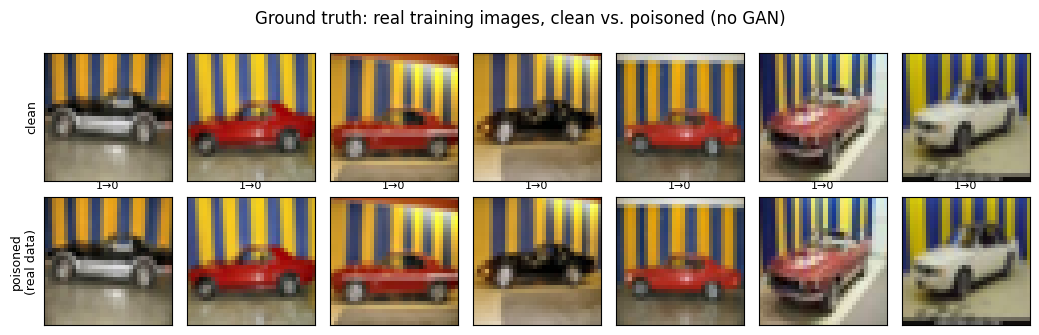

In [8]:
# Ground-truth check: real training images before/after poisoning, straight from apply_trigger()
# (Section 3) with NO generator involved. Compare this against the GAN's generated-sample panel in
# Section 8 — if the trigger isn't visible here either, the bug is in poisoning/CONFIG, not
# the GAN; if it IS visible here but not in Section 8's panel, the bug is GAN-side.
poison_sample_ids = list(loaders["poison_indices"])[:8]
if len(poison_sample_ids) == 0:
    print("No poisoned samples were selected — check CONFIG['poison_rate'] / 'source_label'.")
else:
    fig, axes = plt.subplots(2, len(poison_sample_ids), figsize=(1.5 * len(poison_sample_ids), 3.4))
    if len(poison_sample_ids) == 1:
        axes = axes.reshape(2, 1)
    for col, real_idx in enumerate(poison_sample_ids):
        x_clean, y_orig = train_ds[real_idx]  # raw [0,1], unpoisoned
        x_poison = apply_trigger(x_clean, CONFIG).clamp(0, 1)

        for row, img in enumerate([x_clean, x_poison]):
            disp = img.permute(1, 2, 0).squeeze(-1) if img.shape[0] == 1 else img.permute(1, 2, 0)
            axes[row, col].imshow(disp, cmap="gray" if CONFIG["channels"] == 1 else None)
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
        axes[1, col].set_title(f"{y_orig}\u2192{CONFIG['target_label']}", fontsize=8)

    axes[0, 0].set_ylabel("clean", fontsize=9)
    axes[1, 0].set_ylabel("poisoned\n(real data)", fontsize=9)
    plt.suptitle("Ground truth: real training images, clean vs. poisoned (no GAN)")
    plt.tight_layout()
    plt.show()


## 5. Classifier

A deliberately simple CNN (`ConvTrunk`), per the paper ("the model used in the experiment is
relatively simple" — Section 6.4), reused unchanged across MNIST-family datasets and CIFAR-10
(paper: "the same network structure as that on the MNIST dataset" — Section 6.3). CelebA
instead uses ResNet18 (`ResNetTrunk`), per the paper's own separate spec for that dataset (Sec.
6.1.2) — `build_trunk()`/`CONFIG["backbone"]` select between them; see the Notes cell for the
CelebA architecture deviation this still carries (stem adaptation for 32x32 input, no paper
equivalent given).


In [9]:
class ConvTrunk(nn.Module):
    # Shared feature-extractor architecture (paper Table 1's discriminator column: Conv/LReLU/
    # Dropout -> Conv/BN/LReLU -> Conv/BN/LReLU -> Global Average Pooling -> 256). The
    # classifier (backdoored model / teacher) and the GAN discriminator (Section 8) both use
    # this exact trunk -- same layer count, same shapes -- per the paper's "the global model
    # and the discriminator model will adopt a network structure with different outputs but
    # the same number of layers to ensure the discriminator model will be updated synchronously
    # through the global model parameters" (Sec. 5.2). That synchronization is the paper's
    # actual backdoor-injection mechanism for the GAN; see Section 8.
    def __init__(self, channels, input_size):
        super().__init__()
        if input_size == 28:
            conv_cfg = [(channels, 64, 4, 2, 1), (64, 128, 4, 2, 1), (128, 256, 3, 2, 1)]
        elif input_size == 32:
            conv_cfg = [(channels, 64, 4, 2, 1), (64, 128, 4, 2, 1), (128, 256, 4, 2, 1)]
        else:
            raise ValueError(f"Unsupported input_size {input_size}")
        layers = []
        for idx, (cin, cout, k, s, p) in enumerate(conv_cfg):
            layers.append(nn.Conv2d(cin, cout, k, s, p))
            if idx == 0:
                layers += [nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25)]
            else:
                layers += [nn.BatchNorm2d(cout), nn.LeakyReLU(0.2, inplace=True)]
        self.conv = nn.Sequential(*layers)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.out_dim = 256  # read by Classifier/Discriminator to size their heads -- see build_trunk()

    def forward(self, x):
        return self.gap(self.conv(x)).flatten(1)  # (B, out_dim)


class ResNetTrunk(nn.Module):
    # ResNet18 backbone -- paper Sec. 6.1.2: "For the CeleBA dataset, we use ResNet18
    # architecture as the classification network also being the discriminator." Exposes the
    # same (B, out_dim) contract as ConvTrunk (out_dim=512 here) so Classifier/Discriminator and
    # the discriminator weight-sync mechanism (Section 8) work identically regardless of which
    # trunk CONFIG["backbone"] selects.
    #
    # DEVIATION, not specified by the paper: torchvision's resnet18 stem (7x7/stride2 conv +
    # 3x3/stride2 maxpool) is designed for 224x224 ImageNet input; on this repo's small-resolution
    # inputs it collapses the image to a near-featureless 1x1 map before the residual stages even
    # start. Swapped for the standard "ResNet-for-CIFAR" stem (3x3/stride1 conv) -- the common,
    # well-precedented fix for the same problem on 32x32 CIFAR inputs -- so spatial resolution
    # survives into the residual stages. The paper gives no input resolution for its own CelebA
    # setup, so there is no stated alternative to deviate from.
    def __init__(self, channels, input_size):
        super().__init__()
        try:
            net = torchvision.models.resnet18(weights=None)  # torchvision >= 0.13
        except TypeError:
            net = torchvision.models.resnet18(pretrained=False)  # older torchvision
        if channels != 3 or input_size <= 64:
            net.conv1 = nn.Conv2d(channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        # CHANGED (re-baseline Phase 2): maxpool is now kept (torchvision's default 3x3/stride2)
        # when input_size >= 64, instead of unconditionally replaced with Identity. At 64x64
        # (CelebA's new resolution) conv1's 3x3/stride1 keeps the full 64x64 map, then this
        # maxpool takes it to 32x32 before layer1 -- identical per-layer cost to CIFAR-10's
        # 32x32-straight-into-layer1 path, for 4x the input information. Below 64 (MNIST 28,
        # CIFAR-10 32) this still resolves to Identity, unchanged from before.
        if input_size < 64:
            net.maxpool = nn.Identity()
        net.fc = nn.Identity()
        self.net = net
        self.out_dim = 512

    def forward(self, x):
        return self.net(x)


def build_trunk(channels, input_size, backbone="convtrunk"):
    # CONFIG["backbone"]: "convtrunk" (paper Table 1, MNIST/CIFAR-10 per Sec. 6.1.2) or
    # "resnet18" (paper's CelebA spec, same section). Both Classifier and Discriminator (Section
    # 8) call this so the paper's weight-sync constraint -- same trunk architecture on both
    # sides -- holds regardless of which backbone is selected.
    if backbone == "resnet18":
        return ResNetTrunk(channels, input_size)
    elif backbone == "convtrunk":
        return ConvTrunk(channels, input_size)
    else:
        raise ValueError(f"Unknown backbone {backbone!r}")


class Classifier(nn.Module):
    def __init__(self, channels, num_classes, input_size, backbone="convtrunk"):
        super().__init__()
        self.trunk = build_trunk(channels, input_size, backbone)
        self.head = nn.Linear(self.trunk.out_dim, num_classes)

    def forward(self, x):
        return self.head(self.trunk(x))


def train_classifier(model, loader, epochs, lr, tag="", capture_trunk_every=None,
                      optimizer="adam", momentum=0.9, weight_decay=0.0, cosine=False,
                      nesterov=False):
    # optimizer/momentum/weight_decay/cosine/nesterov (NOT in the paper -- it names no optimizer
    # at all, only "communication rounds", "local epochs" and a learning rate): "adam" defaults
    # reproduce the original behavior (plain Adam, no schedule, no decay) for callers that don't
    # opt in. SGD+momentum+weight-decay+cosine(+nesterov) is the canonical recipe for training
    # this class of CNN/ResNet longer without just overfitting -- added for CIFAR-10's Before-ACC
    # gap (71.70% vs. the paper's 83.57%), now the live default for all three datasets
    # (re-baseline Phase 1, see CONFIG's clf_*/teacher_* comments and HANDOFF.md).
    model.to(device, memory_format=torch.channels_last).train()
    if optimizer == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum,
                               weight_decay=weight_decay, nesterov=nesterov and momentum > 0)
    elif optimizer == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer {optimizer!r}")
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if cosine else None
    # Re-baseline Phase 0 (speed foundation): mixed precision + channels_last, ~1.5-2.5x on a T4
    # at no accuracy cost (see HANDOFF.md / the re-baseline plan). fp16 changes results bitwise,
    # so don't compare a pre-AMP and post-AMP number to three decimal places.
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    trunk_checkpoints = []
    for epoch in range(epochs):
        total, n = 0.0, 0
        for x, y in loader:
            x = x.to(device, memory_format=torch.channels_last)
            y = y.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = F.cross_entropy(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            total += loss.item() * x.size(0)
            n += x.size(0)
        if sched is not None:
            sched.step()
        print(f"[{tag}] epoch {epoch + 1}/{epochs} loss={total / n:.4f}")
        if capture_trunk_every and (epoch + 1) % capture_trunk_every == 0:
            trunk_checkpoints.append(copy.deepcopy(model.trunk.state_dict()))
    if capture_trunk_every and not trunk_checkpoints:
        trunk_checkpoints.append(copy.deepcopy(model.trunk.state_dict()))
    return model, trunk_checkpoints


def cached_train_classifier(model, loader, epochs, lr, cfg, cache_keys, cache_name, **kwargs):
    # Drive-backed cache around train_classifier -- see cell 5's ARTIFACT_ROOT/_config_hash for
    # the correctness caveat. `cache_name` is just a filename prefix ("backdoored" / "teacher");
    # `cache_keys` is one of CACHE_KEYS_BACKDOORED/CACHE_KEYS_TEACHER (cell 5).
    path = os.path.join(ARTIFACT_ROOT, f"{cache_name}_{_config_hash(cfg, cache_keys)}.pt")
    if os.path.exists(path):
        blob = torch.load(path, map_location=device)
        model.load_state_dict(blob["model"])
        model.to(device)
        print(f"[cache] loaded {cache_name} from {path}")
        return model, blob["trunk_checkpoints"]
    model, trunk_checkpoints = train_classifier(model, loader, epochs, lr, **kwargs)
    save_artifact({"model": model.state_dict(), "trunk_checkpoints": trunk_checkpoints}, path)
    return model, trunk_checkpoints


@torch.no_grad()
def evaluate_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total


## 6. Train the backdoored model ("Before ADFL")

Trained only on the pool (the server's clean holdout is *not* used here — it is only
available to ADFL's defense side, mirroring the paper's threat model).


In [10]:
set_seed(CONFIG["seed"])  # reseed here: Section 6 must be reproducible on its own, not just
                          # depend on how much RNG state earlier cells in this Colab session
                          # happened to consume since the CONFIG cell's one-time set_seed call.
backdoored_model = Classifier(CONFIG["channels"], CONFIG["num_classes"], CONFIG["input_size"],
                               backbone=CONFIG.get("backbone", "convtrunk"))
backdoored_model, backdoored_trunk_checkpoints = cached_train_classifier(
    backdoored_model, loaders["train_pool"], CONFIG["clf_epochs"], CONFIG["clf_lr"],
    CONFIG, CACHE_KEYS_BACKDOORED, "backdoored",
    tag="backdoored", capture_trunk_every=1,
    optimizer=CONFIG.get("clf_optimizer", "adam"), momentum=CONFIG.get("clf_momentum", 0.9),
    weight_decay=CONFIG.get("clf_weight_decay", 0.0), cosine=CONFIG.get("clf_cosine", False),
    nesterov=CONFIG.get("clf_nesterov", False))
# `backdoored_trunk_checkpoints` -- one snapshot of the trunk's weights per training epoch --
# stands in for "the global model of the following [federated] rounds" (paper Sec. 5.2) that
# the GAN's discriminator gets periodically re-synced from in Section 8. Centralizing away
# FedAvg removes the per-round model churn the paper's mechanism relies on; rotating over this
# model's own training trajectory is the cheapest faithful substitute (agreed with the user
# over reintroducing FL) -- see the Notes cell.

acc_before = evaluate_acc(backdoored_model, loaders["clean_test"])
asr_before = evaluate_acc(backdoored_model, loaders["asr_test"])
print(f"\nBefore ADFL — ACC: {acc_before * 100:.2f}%  ASR: {asr_before * 100:.2f}%")



[backdoored] epoch 1/60 loss=2.1320
[backdoored] epoch 2/60 loss=1.5617
[backdoored] epoch 3/60 loss=1.2941
[backdoored] epoch 4/60 loss=1.0485
[backdoored] epoch 5/60 loss=0.8901
[backdoored] epoch 6/60 loss=0.7610
[backdoored] epoch 7/60 loss=0.6530
[backdoored] epoch 8/60 loss=0.5888
[backdoored] epoch 9/60 loss=0.5477
[backdoored] epoch 10/60 loss=0.5188
[backdoored] epoch 11/60 loss=0.5003
[backdoored] epoch 12/60 loss=0.4697
[backdoored] epoch 13/60 loss=0.4532
[backdoored] epoch 14/60 loss=0.4326
[backdoored] epoch 15/60 loss=0.4198
[backdoored] epoch 16/60 loss=0.4104
[backdoored] epoch 17/60 loss=0.3974
[backdoored] epoch 18/60 loss=0.3832
[backdoored] epoch 19/60 loss=0.3711
[backdoored] epoch 20/60 loss=0.3619
[backdoored] epoch 21/60 loss=0.3452
[backdoored] epoch 22/60 loss=0.3395
[backdoored] epoch 23/60 loss=0.3296
[backdoored] epoch 24/60 loss=0.3184
[backdoored] epoch 25/60 loss=0.3043
[backdoored] epoch 26/60 loss=0.2933
[backdoored] epoch 27/60 loss=0.2888
[backdoore

## 7. Train the clean / teacher model

Trained only on the server's small clean holdout. This model plays two roles in ADFL: it
**relabels** the generator's fake samples, and it is the **teacher** in the distillation
step.


In [11]:
set_seed(CONFIG["seed"] + 1)  # reseed here too, for the same reason as Section 6 -- offset
                              # by 1 so the teacher doesn't get identical init to the backdoored
                              # model, while still being reproducible run to run.
clean_model = Classifier(CONFIG["channels"], CONFIG["num_classes"], CONFIG["input_size"],
                          backbone=CONFIG.get("backbone", "convtrunk"))
clean_model, _ = cached_train_classifier(
    clean_model, loaders["clean_holdout"], CONFIG["teacher_epochs"], CONFIG["teacher_lr"],
    CONFIG, CACHE_KEYS_TEACHER, "teacher", tag="teacher",
    optimizer=CONFIG.get("teacher_optimizer", "adam"), momentum=CONFIG.get("teacher_momentum", 0.9),
    weight_decay=CONFIG.get("teacher_weight_decay", 0.0), cosine=CONFIG.get("teacher_cosine", False),
    nesterov=CONFIG.get("teacher_nesterov", False))

teacher_acc = evaluate_acc(clean_model, loaders["clean_test"])
print(f"\nTeacher (clean-only) ACC: {teacher_acc * 100:.2f}%")



[teacher] epoch 1/100 loss=2.8261
[teacher] epoch 2/100 loss=1.9934
[teacher] epoch 3/100 loss=1.8005
[teacher] epoch 4/100 loss=1.7185
[teacher] epoch 5/100 loss=1.6685
[teacher] epoch 6/100 loss=1.5795
[teacher] epoch 7/100 loss=1.5210
[teacher] epoch 8/100 loss=1.4485
[teacher] epoch 9/100 loss=1.4047
[teacher] epoch 10/100 loss=1.3266
[teacher] epoch 11/100 loss=1.2933
[teacher] epoch 12/100 loss=1.2466
[teacher] epoch 13/100 loss=1.1942
[teacher] epoch 14/100 loss=1.1426
[teacher] epoch 15/100 loss=1.0885
[teacher] epoch 16/100 loss=1.0519
[teacher] epoch 17/100 loss=1.0375
[teacher] epoch 18/100 loss=0.9659
[teacher] epoch 19/100 loss=0.8954
[teacher] epoch 20/100 loss=0.8811
[teacher] epoch 21/100 loss=0.7856
[teacher] epoch 22/100 loss=0.7414
[teacher] epoch 23/100 loss=0.6695
[teacher] epoch 24/100 loss=0.6795
[teacher] epoch 25/100 loss=0.6731
[teacher] epoch 26/100 loss=0.6206
[teacher] epoch 27/100 loss=0.5702
[teacher] epoch 28/100 loss=0.5831
[teacher] epoch 29/100 loss=0

## 8. ADFL step 1 — distillation-data generator (paper Eq. 2/3, discriminator re-synced from the backdoored model)

DCGAN-style generator, matching the paper's stated architecture for the 28x28 case (FC →
`7x7x256` → ConvT/BN/LReLU → `7x7x128` → ConvT/BN/LReLU → `14x14x64` → ConvT/Tanh →
`28x28xC`); a straightforward 32x32 extension is used for CIFAR-10/CelebA (unchanged for
CelebA — the paper's own Roth et al. (2017) generator is not implemented, see the Notes
cell). The discriminator mirrors whatever trunk the classifier uses (`build_trunk()`,
Section 5 — `ConvTrunk` for MNIST/CIFAR-10, `ResNetTrunk` for CelebA) plus a 1-dim head, so the
weight-sync below always has matching architectures on both sides regardless of backbone.

**The generator's loss is exactly the paper's Eq. 2/3 — vanilla GAN, nothing else.** Six
earlier rounds of this notebook added a "backdoor-guidance" cross-entropy term pushing
generated samples toward the frozen backdoored model's `target_label`, plus TV penalties and
expectation-over-transformations robustness tricks on top of it, chasing a visible trigger
that never appeared. Recovering Algorithm 1 and Eq. 2/3 from the paper's PDF (the OCR text
this notebook was originally built from dropped both float boxes) shows that loss never
existed in the paper — it was this notebook's own invention, and it is exactly the kind of
objective that lets a generator converge onto a cheap adversarial shortcut instead of the real
trigger. It has been deleted rather than tuned further.

**The paper's actual mechanism for injecting the backdoor into the GAN** is architectural, not
a loss term (Sec. 5.2, Algorithm 1's `D(x) ← G̃t`): *"the global model and the discriminator
model will adopt a network structure with different outputs but the same number of layers to
ensure the discriminator model will be updated synchronously through the global model
parameters"* — and later, explicitly causal: *"update the discriminator with the global model
of the following rounds ... to ensure that the backdoor samples can be generated."* Concretely:
- `D`'s trunk is the **same architecture** as the classifier's (`build_trunk()`, Section 5),
  so its weights can be copied in directly. Its head (`Linear(trunk.out_dim, 1)`) is separate
  and trained normally.
- `D`'s trunk is **initialized from the backdoored model's first checkpoint**, then
  **periodically re-synced** from later checkpoints (`d_resync_every` GAN epochs) — the
  centralized substitute for the paper's per-communication-round global-model churn (agreed
  with the user over reintroducing FedAvg; see the Notes cell).
- The real branch of `D`'s adversarial loss (Eq. 3) is trained against the server's real clean
  holdout, matching Algorithm 1's `Bgan <- split(D_clean, ...)`.
- The generator is **unconditional** (`z` only, Table 1's stated input) — no class label, no
  one-hot. Labels for generated samples come later, in Section 9, from the teacher.


In [12]:
class Generator(nn.Module):
    def __init__(self, latent_dim, channels, output_size):
        super().__init__()
        if output_size == 28:
            self.init_size = 7
            deconv_cfg = [(256, 128, 3, 1, 1), (128, 64, 4, 2, 1), (64, channels, 4, 2, 1)]
        elif output_size == 32:
            self.init_size = 4
            deconv_cfg = [(256, 128, 4, 2, 1), (128, 64, 4, 2, 1), (64, channels, 4, 2, 1)]
        elif output_size == 64:
            # ADDED (re-baseline Phase 2, CelebA 64x64): one extra stride-2 stage vs. the 32
            # case -- init_size=4 still, but 4->8->16->32->64 needs 4 doublings instead of 3.
            self.init_size = 4
            deconv_cfg = [(256, 128, 4, 2, 1), (128, 64, 4, 2, 1), (64, 32, 4, 2, 1), (32, channels, 4, 2, 1)]
        else:
            raise ValueError(f"Unsupported output_size {output_size}")

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * self.init_size * self.init_size),
            nn.BatchNorm1d(256 * self.init_size * self.init_size),
            nn.LeakyReLU(0.2, inplace=True),
        )
        layers = []
        for idx, (cin, cout, k, s, p) in enumerate(deconv_cfg):
            layers.append(nn.ConvTranspose2d(cin, cout, k, s, p))
            if idx < len(deconv_cfg) - 1:
                layers += [nn.BatchNorm2d(cout), nn.LeakyReLU(0.2, inplace=True)]
            else:
                layers.append(nn.Tanh())
        self.deconv = nn.Sequential(*layers)

    def forward(self, z):
        out = self.fc(z)
        out = out.view(out.size(0), 256, self.init_size, self.init_size)
        return self.deconv(out)


class Discriminator(nn.Module):
    # Same trunk as the classifier (build_trunk(), Section 5 -- ConvTrunk or ResNetTrunk
    # depending on CONFIG["backbone"]) so its weights can be copied directly from a
    # backdoored-model checkpoint -- see sync_discriminator_trunk() and the Section 8 markdown
    # above. Whatever backbone the classifier uses, the discriminator must match, or
    # sync_discriminator_trunk's load_state_dict would fail outright.
    def __init__(self, channels, input_size, backbone="convtrunk"):
        super().__init__()
        self.trunk = build_trunk(channels, input_size, backbone)
        self.head = nn.Linear(self.trunk.out_dim, 1)

    def forward(self, x):
        return self.head(self.trunk(x))


def sync_discriminator_trunk(D, trunk_state_dict, freeze=False, alpha=None):
    # freeze (Section 13c H2 probe): when True, the trunk is held fixed exactly as re-synced --
    # requires_grad=False so opt_d (built over D.head only in that case, see train_generator)
    # never touches it, and eval() mode so its BatchNorm running stats also stay frozen at the
    # backdoored checkpoint's values instead of drifting toward GAN-batch statistics. Re-applied
    # after every sync since load_state_dict doesn't touch requires_grad/train-mode flags.
    #
    # alpha (Phase 4 step 4e, cfg["d_resync_alpha"], NOT in the paper): None/1.0 = the original
    # hard overwrite (Algorithm 1's `D(x) <- G~t` as implemented since Section 8 was built).
    # A float in (0, 1) instead BLENDS the checkpoint into D's current trunk --
    # new = alpha*checkpoint + (1-alpha)*current -- approximating how FedAvg would dilute a
    # single client's update against ~100 mostly-benign clients each round, since the paper's
    # "following rounds" mechanism (Sec. 5.2) assumes that dilution and this notebook's
    # centralized substitute (rotating over the backdoored model's own checkpoints) has none --
    # each resync here is a full, undiluted, abrupt overwrite. This is the one untested lever
    # that actually targets that centralized-vs-federated divergence (see Notes cell); it does
    # NOT reintroduce FedAvg -- it is a local weight-interpolation proxy, per the user's standing
    # decision to keep this notebook centralized.
    if alpha is None or alpha >= 1.0:
        D.trunk.load_state_dict(trunk_state_dict)
    else:
        current = D.trunk.state_dict()
        blended = {
            k: alpha * trunk_state_dict[k].to(current[k].dtype) + (1 - alpha) * current[k]
            if torch.is_floating_point(current[k]) else trunk_state_dict[k]
            for k in current
        }
        D.trunk.load_state_dict(blended)
    for p in D.trunk.parameters():
        p.requires_grad_(not freeze)
    D.trunk.train(not freeze)


def _diffaug(x):
    # Phase 4 step 4d (cfg["gan_diffaug"], NOT in the paper): lightweight differentiable
    # augmentation (translation + cutout), applied identically to BOTH D branches (real and
    # fake, each with its own independent random draw) so D cannot learn to separate them by
    # augmentation artifacts alone -- the standard small-data GAN discriminator-overfitting
    # fix (Zhao et al. 2020, DiffAugment). Targets D memorizing the ~4k-image clean-holdout
    # real set (d_loss collapsing toward 0, see Notes cell's generator-fidelity finding).
    b, c, h, w = x.shape
    # random translation, up to 1/8 of the image size
    max_shift = max(1, h // 8)
    shift_h = torch.randint(-max_shift, max_shift + 1, (1,)).item()
    shift_w = torch.randint(-max_shift, max_shift + 1, (1,)).item()
    x = torch.roll(x, shifts=(shift_h, shift_w), dims=(2, 3))
    # random cutout, up to half the image size
    cut_h, cut_w = h // 2, w // 2
    cy = torch.randint(0, h, (1,)).item()
    cx = torch.randint(0, w, (1,)).item()
    y0, y1 = max(0, cy - cut_h // 2), min(h, cy + cut_h // 2)
    x0, x1 = max(0, cx - cut_w // 2), min(w, cx + cut_w // 2)
    x = x.clone()
    x[:, :, y0:y1, x0:x1] = 0
    return x


def train_generator(target_checkpoints, cfg, real_loader):
    # target_checkpoints: trunk state_dicts sampled across the backdoored model's own training
    # trajectory (train_classifier's capture_trunk_every). D's trunk is initialized from the
    # first checkpoint and periodically re-synced from later ones -- Algorithm 1's
    # `D(x) <- G~t` plus the paper's "global model of the FOLLOWING rounds" (Sec. 5.2),
    # substituting this model's own training trajectory for federated communication rounds
    # (see Notes cell). The loss is exactly Eq. 2 (G) / Eq. 3 (D) -- no other term.
    #
    # cfg["d_trunk_frozen"] (Section 13c H2 probe, default False): when True, D's trunk is
    # updated only by the re-syncs above and never by opt_d/backprop -- isolating whether the
    # ~gan_steps_per_epoch * d_resync_every free gradient steps the trunk otherwise takes
    # between re-syncs wash out whatever trigger signal the backdoored checkpoint carried in.
    #
    # Phase 4 knobs (2026-09-11, NOT in the paper -- see Notes cell's generator-fidelity
    # finding for why the 2026-09-06 closure was premature): all default to the ORIGINAL
    # behavior when unset, so this function is a no-op change until CONFIG opts in.
    # - cfg["gan_d_lr"]: separate (lower) learning rate for D, targeting D overwhelming G
    #   (logged d_loss 0.027-0.236 -- D winning near-perfectly). None = same as gan_lr.
    # - cfg["gan_g_steps_per_d_step"]: extra G updates per D step, same target. Default 1.
    # - cfg["gan_label_smoothing"]: one-sided smoothing on D's real targets (e.g. 0.9 instead
    #   of 1.0), same target via a softer D. Default 0.0 (no smoothing).
    # - cfg["gan_diffaug"]: see _diffaug() above -- targets D overfitting the tiny real set.
    # - cfg["d_resync_alpha"]: see sync_discriminator_trunk() above -- targets the centralized
    #   resync itself being an abrupt, undiluted overwrite. Applied only to the PERIODIC
    #   resyncs below, never the initial one (D must start from a real, complete checkpoint).
    G = Generator(cfg["latent_dim"], cfg["channels"], cfg["input_size"]).to(device, memory_format=torch.channels_last)
    D = Discriminator(cfg["channels"], cfg["input_size"], backbone=cfg.get("backbone", "convtrunk")).to(device, memory_format=torch.channels_last)
    d_trunk_frozen = cfg.get("d_trunk_frozen", False)
    sync_discriminator_trunk(D, target_checkpoints[0], freeze=d_trunk_frozen)
    opt_g = torch.optim.Adam(G.parameters(), lr=cfg["gan_lr"], betas=(0.5, 0.999))
    d_params = D.head.parameters() if d_trunk_frozen else D.parameters()
    opt_d = torch.optim.Adam(d_params, lr=cfg.get("gan_d_lr") or cfg["gan_lr"], betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    g_steps_per_d_step = max(1, cfg.get("gan_g_steps_per_d_step", 1))
    real_label_val = 1.0 - cfg.get("gan_label_smoothing", 0.0)
    use_diffaug = cfg.get("gan_diffaug", False)
    d_resync_alpha = cfg.get("d_resync_alpha")
    # Re-baseline Phase 0 (speed foundation): mixed precision, same rationale as
    # train_classifier (Section 5) -- separate scalers since D's and G's losses/gradients scale
    # independently.
    scaler_d = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    scaler_g = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    snapshot_every = cfg.get("gan_snapshot_every", max(1, cfg["gan_epochs"] // 6))
    snapshots = []
    loss_history = []

    def capture_snapshot(epoch_label):
        G.eval()
        with torch.no_grad():
            z = torch.randn(8, cfg["latent_dim"], device=device)
            imgs = (G(z).cpu() * 0.5 + 0.5).clamp(0, 1)
        G.train()
        snapshots.append((epoch_label, imgs))

    real_iter = iter(real_loader)

    def next_real_batch():
        nonlocal real_iter
        try:
            x, _ = next(real_iter)
        except StopIteration:
            real_iter = iter(real_loader)
            x, _ = next(real_iter)
        return x.to(device, memory_format=torch.channels_last)

    capture_snapshot(0)  # pre-training baseline (pure noise)
    resync_pointer = 0

    for epoch in range(cfg["gan_epochs"]):
        if cfg["d_resync_every"] and epoch > 0 and epoch % cfg["d_resync_every"] == 0:
            resync_pointer = (resync_pointer + 1) % len(target_checkpoints)
            sync_discriminator_trunk(D, target_checkpoints[resync_pointer], freeze=d_trunk_frozen,
                                      alpha=d_resync_alpha)

        for _ in range(cfg["gan_steps_per_epoch"]):
            # --- Discriminator step (Eq. 3): real (clean holdout) vs. fake ---
            real_x = next_real_batch()
            b = real_x.size(0)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                z = torch.randn(b, cfg["latent_dim"], device=device)
                fake_x = G(z).detach()
                d_real_in = _diffaug(real_x) if use_diffaug else real_x
                d_fake_in = _diffaug(fake_x) if use_diffaug else fake_x
                d_real = D(d_real_in)
                d_fake = D(d_fake_in)
                d_loss = bce(d_real, torch.full_like(d_real, real_label_val)) + bce(d_fake, torch.zeros_like(d_fake))
            opt_d.zero_grad(set_to_none=True)
            scaler_d.scale(d_loss).backward()
            scaler_d.step(opt_d)
            scaler_d.update()

            # --- Generator step(s) (Eq. 2): maximize log D(G(z)) ---
            for _ in range(g_steps_per_d_step):
                with torch.amp.autocast("cuda", enabled=USE_AMP):
                    z = torch.randn(b, cfg["latent_dim"], device=device)
                    fake_x = G(z)
                    g_in = _diffaug(fake_x) if use_diffaug else fake_x
                    g_out = D(g_in)
                    g_loss = bce(g_out, torch.ones_like(g_out))
                opt_g.zero_grad(set_to_none=True)
                scaler_g.scale(g_loss).backward()
                scaler_g.step(opt_g)
                scaler_g.update()

        print(f"[GAN] epoch {epoch + 1}/{cfg['gan_epochs']} "
              f"d_loss={d_loss.item():.4f} g_loss={g_loss.item():.4f}")
        loss_history.append((epoch + 1, d_loss.item(), g_loss.item()))

        if (epoch + 1) % snapshot_every == 0 or epoch == cfg["gan_epochs"] - 1:
            capture_snapshot(epoch + 1)

    return G, snapshots, loss_history


def cached_train_generator(target_checkpoints, cfg, real_loader, cache_keys, cache_name="generator"):
    # Drive-backed cache around train_generator -- see cell 5's ARTIFACT_ROOT/_config_hash for
    # the correctness caveat (usually CACHE_KEYS_GENERATOR).
    path = os.path.join(ARTIFACT_ROOT, f"{cache_name}_{_config_hash(cfg, cache_keys)}.pt")
    if os.path.exists(path):
        blob = torch.load(path, map_location=device)
        G = Generator(cfg["latent_dim"], cfg["channels"], cfg["input_size"]).to(device)
        G.load_state_dict(blob["generator"])
        print(f"[cache] loaded {cache_name} from {path}")
        # map_location=device pulls every tensor in the blob onto the GPU, including the
        # snapshot images train_generator had already moved to cpu -- restore that invariant
        # so the Section 8 plotting cell's img.permute(...) doesn't choke on a cuda tensor.
        cached_snapshots = [(label, imgs.cpu()) for label, imgs in blob["snapshots"]]
        cached_loss_history = blob.get("loss_history", [])
        return G, cached_snapshots, cached_loss_history
    G, snapshots, loss_history = train_generator(target_checkpoints, cfg, real_loader)
    save_artifact({"generator": G.state_dict(), "snapshots": snapshots, "loss_history": loss_history}, path)
    return G, snapshots, loss_history


generator, gan_snapshots, gan_loss_history = cached_train_generator(backdoored_trunk_checkpoints, CONFIG, loaders["clean_holdout"],
                                                                     CACHE_KEYS_GENERATOR)


[GAN] epoch 1/100 d_loss=0.3126 g_loss=1.8763
[GAN] epoch 2/100 d_loss=0.4408 g_loss=0.0701
[GAN] epoch 3/100 d_loss=0.6414 g_loss=2.0407
[GAN] epoch 4/100 d_loss=0.3485 g_loss=2.4299
[GAN] epoch 5/100 d_loss=0.0171 g_loss=4.8645
[GAN] epoch 6/100 d_loss=0.0203 g_loss=4.6162
[GAN] epoch 7/100 d_loss=0.0192 g_loss=4.6963
[GAN] epoch 8/100 d_loss=0.0349 g_loss=4.2912
[GAN] epoch 9/100 d_loss=0.0204 g_loss=4.6898
[GAN] epoch 10/100 d_loss=0.0252 g_loss=4.5915
[GAN] epoch 11/100 d_loss=0.0220 g_loss=4.5702
[GAN] epoch 12/100 d_loss=0.0149 g_loss=4.9075
[GAN] epoch 13/100 d_loss=0.0099 g_loss=5.3336
[GAN] epoch 14/100 d_loss=0.0168 g_loss=4.9527
[GAN] epoch 15/100 d_loss=0.0987 g_loss=4.7120
[GAN] epoch 16/100 d_loss=0.0185 g_loss=4.7984
[GAN] epoch 17/100 d_loss=0.1093 g_loss=3.6092
[GAN] epoch 18/100 d_loss=0.0250 g_loss=5.0647
[GAN] epoch 19/100 d_loss=0.0107 g_loss=5.3796
[GAN] epoch 20/100 d_loss=0.0092 g_loss=5.4738
[GAN] epoch 21/100 d_loss=0.0200 g_loss=5.2340
[GAN] epoch 22/100 d_l

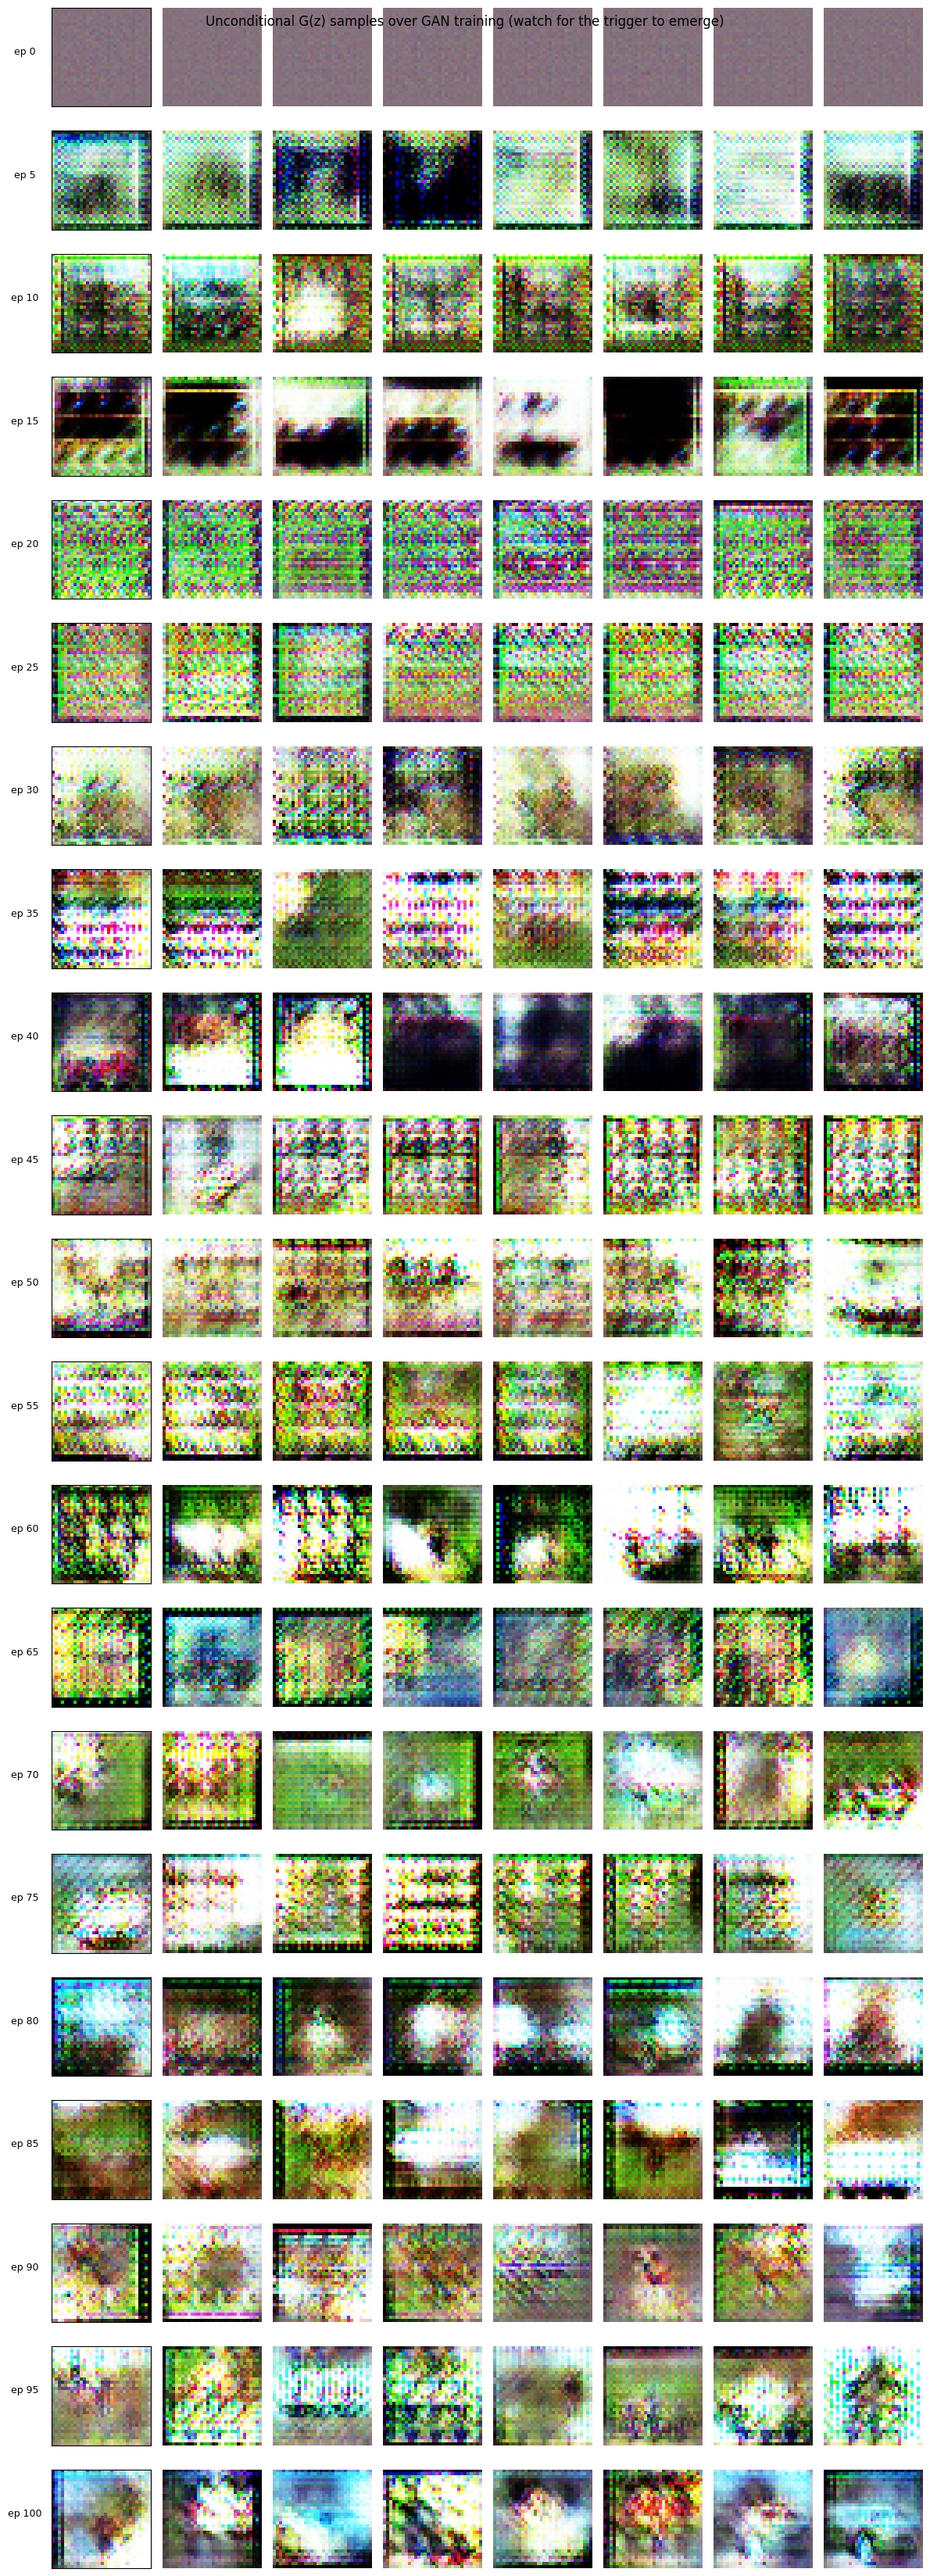

In [13]:
# Training-progress panel: unconditional G(z) samples captured every `gan_snapshot_every`
# epochs (see train_generator). Watch the trigger emerge (or fail to) across the run -- the
# paper reports the watermark trigger only becomes recognizable after ~100 rounds and the
# pixel-block trigger has "noise point[s] inside the square that will disappear after certain
# rounds" (Sec. 6.3, Fig. 6), so an early row with no trigger is expected, not a bug.
if gan_snapshots:
    n_rows = len(gan_snapshots)
    fig, axes = plt.subplots(n_rows, 8, figsize=(12, 1.6 * n_rows))
    if n_rows == 1:
        axes = axes[None, :]
    for row, (epoch_label, imgs) in enumerate(gan_snapshots):
        for col, img in enumerate(imgs):
            img_ = img.permute(1, 2, 0).squeeze(-1) if img.shape[0] == 1 else img.permute(1, 2, 0)
            axes[row, col].imshow(img_, cmap="gray" if CONFIG["channels"] == 1 else None)
            axes[row, col].axis("off")
        axes[row, 0].axis("on")
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        axes[row, 0].set_ylabel(f"ep {epoch_label}", rotation=0, labelpad=25, fontsize=9)
    plt.suptitle("Unconditional G(z) samples over GAN training (watch for the trigger to emerge)")
    plt.tight_layout()
    plt.show()


### 8b. GAN loss curves (d_resync-boundary check)

Plots `d_loss`/`g_loss` per epoch from the last `train_generator` run (empty on a cache hit against a pre-loss-history cached artifact -- delete the cached `generator_*.pt` file on Drive and rerun to populate this). Vertical dashed lines mark every `d_resync_every`-epoch boundary, where the discriminator's trunk is hard re-synced (`load_state_dict`) from a backdoored-model checkpoint. CIFAR-10's Section 13c investigation found `d_loss`/`g_loss` spiking exactly at these boundaries (H2), consistent with each resync disrupting whatever equilibrium the generator had reached. Check whether the same spike pattern shows up here, and whether it's recovered from (as the snapshot panel above suggests) or not.

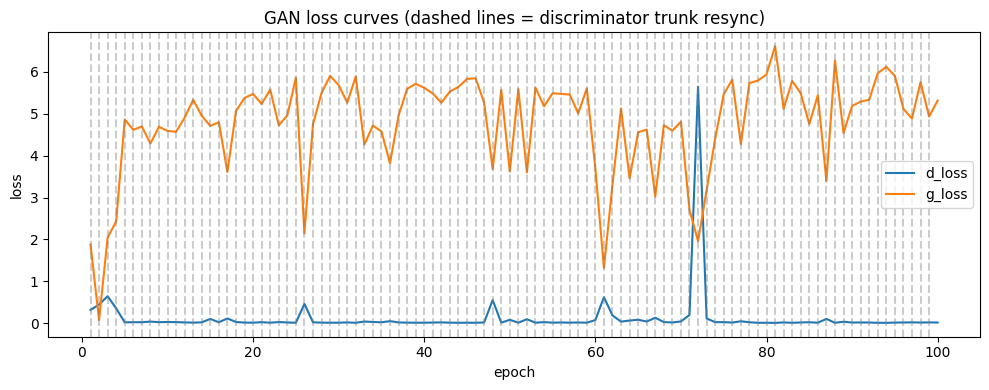

In [14]:
if gan_loss_history:
    epochs, d_losses, g_losses = zip(*gan_loss_history)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, d_losses, label="d_loss")
    ax.plot(epochs, g_losses, label="g_loss")
    resync_every = CONFIG.get("d_resync_every")
    if resync_every:
        for e in range(resync_every, CONFIG["gan_epochs"], resync_every):
            ax.axvline(e, color="gray", linestyle="--", alpha=0.4)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title("GAN loss curves (dashed lines = discriminator trunk resync)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[loss curves] gan_loss_history is empty -- this run hit the artifact cache against a "
          "pre-loss-history blob. Delete the cached generator_*.pt file on Drive and rerun to "
          "populate it.")


## 9. ADFL step 2 — relabel with the clean/teacher model

The generated samples are unlabeled (`G(z)` takes only noise, Section 8); the clean/teacher
model assigns pseudo-labels, forming the distillation dataset (paper: 10,000 samples) — exactly
Algorithm 1's `y = f(Gclean, x_fake)`.

**Instrument (Phase 0 of the replication plan): backdoor-activation rate.** The paper's Fig. 7
analogue compares teacher labels against a *known* ground truth for the generated samples,
and reports the fraction of generated images that carry the trigger ("about 50% ... at 1%
clean data ... about 85% ... at 5%", Sec. 6.3). Since this notebook doesn't have ground-truth
labels for generated images, the closest available proxy is: of the samples the *backdoored*
model classifies as `target_label`, what fraction does the *teacher* disagree with? A high
rate means the generator is reproducing trigger-like features the backdoored model reacts to
but the (unaffected) teacher doesn't — exactly the correction signal ADFL's knowledge
distillation step needs. A rate near zero means the generator hasn't learned to reproduce the
backdoor at all, regardless of how the generated images look.


In [15]:
@torch.no_grad()
def generate_and_relabel(generator, teacher, n, cfg, backdoored_model=None, batch_size=500):
    # cfg["distill_conf_floor"] (NOT in the paper, default 0.0 = off -- see CONFIG comment):
    # discards generated samples whose teacher-relabel confidence falls below this floor,
    # instead of keeping every generated sample the way the original (pre-2026-09-03) version
    # did. Over-generates in batches until `n` samples clear the floor (or `max_batches` is hit,
    # a safety cap against an unreachable floor looping forever) rather than down-weighting
    # low-confidence samples' loss, so KD's math -- validated correct by Section 13a's row C --
    # stays untouched; only WHICH samples reach it changes. At the default 0.0, every generated
    # sample clears it (softmax max-prob is always > 0), so this reproduces the original
    # unfiltered behavior exactly, batch-for-batch.
    generator.eval()
    teacher.eval()
    if backdoored_model is not None:
        backdoored_model.eval()
    conf_floor = cfg.get("distill_conf_floor", 0.0)
    max_batches = max(50, 10 * -(-n // batch_size))
    xs, ys, confs = [], [], []
    bd_target_count, bd_target_teacher_disagrees = 0, 0
    n_generated_total = 0
    kept = 0
    batches_run = 0
    while kept < n and batches_run < max_batches:
        b = min(batch_size, n - kept)
        z = torch.randn(b, cfg["latent_dim"], device=device)
        x = generator(z)
        logits = teacher(x)
        probs = F.softmax(logits, dim=1)
        conf, y = probs.max(dim=1)
        n_generated_total += b
        if backdoored_model is not None:
            bd_y = backdoored_model(x).argmax(1)
            is_bd_target = bd_y == cfg["target_label"]
            bd_target_count += is_bd_target.sum().item()
            bd_target_teacher_disagrees += (is_bd_target & (y != cfg["target_label"])).sum().item()
        keep_mask = conf >= conf_floor
        xs.append(x[keep_mask].cpu())
        ys.append(y[keep_mask].cpu())
        confs.append(conf[keep_mask].cpu())
        kept += keep_mask.sum().item()
        batches_run += 1
    if kept < n:
        print(f"WARNING: distill_conf_floor={conf_floor} too strict -- only {kept}/{n} samples "
              f"cleared it after generating {n_generated_total} candidates over "
              f"{batches_run} batches; using what was found.")
    xs = torch.cat(xs) if xs else torch.empty(0, cfg["channels"], cfg["input_size"], cfg["input_size"])
    ys = torch.cat(ys) if ys else torch.empty(0, dtype=torch.long)
    confs = torch.cat(confs) if confs else torch.empty(0)
    diag = {"n_generated": n_generated_total, "n_kept": kept}
    if backdoored_model is not None:
        diag["backdoor_activation_rate"] = bd_target_count / n_generated_total
        diag["backdoor_activation_rate_disagreeing_teacher"] = bd_target_teacher_disagrees / n_generated_total
    return xs, ys, confs, diag


def sample_clean_mix(clean_holdout_ds, n, seed):
    # Real, untriggered, TRUE-labeled samples drawn (with replacement) from the server's clean
    # holdout -- mixed into the distillation set alongside the synthetic/relabeled ones. See
    # CONFIG["distill_clean_mix_frac"] for why this exists.
    idx_pool = list(range(len(clean_holdout_ds)))
    if n <= 0 or not idx_pool:
        return torch.empty(0), torch.empty(0, dtype=torch.long)
    rng = random.Random(seed)
    xs, ys = [], []
    for _ in range(n):
        i = idx_pool[rng.randrange(len(idx_pool))]
        x, y = clean_holdout_ds[i]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)


def n_synth_distill(cfg):
    return cfg["n_distill"] - int(cfg["n_distill"] * cfg["distill_clean_mix_frac"])


def build_distill_loader(gen_x, gen_y, clean_holdout_ds, cfg, seed):
    # Combines synthetic/relabeled distillation samples (already sized to n_synth_distill(cfg)
    # by the caller) with a real, untriggered, true-labeled slice of the clean holdout sized to
    # the remainder -- see sample_clean_mix and CONFIG["distill_clean_mix_frac"].
    n_mix = cfg["n_distill"] - gen_x.shape[0]
    mix_x, mix_y = sample_clean_mix(clean_holdout_ds, n_mix, seed)
    x = torch.cat([gen_x, mix_x]) if n_mix > 0 else gen_x
    y = torch.cat([gen_y, mix_y]) if n_mix > 0 else gen_y
    return DataLoader(TensorDataset(x, y), batch_size=cfg["batch_size"], shuffle=True)


distill_x, distill_y, distill_conf, distill_diag = generate_and_relabel(
    generator, clean_model, n_synth_distill(CONFIG), CONFIG, backdoored_model=backdoored_model)
n_generated = distill_diag["n_generated"]
n_dropped = n_generated - distill_x.shape[0]
print(f"Distillation set: {distill_x.shape[0]} synthetic + "
      f"{CONFIG['n_distill'] - distill_x.shape[0]} real-untriggered-clean samples "
      f"({n_dropped}/{n_generated} generated candidates dropped by "
      f"distill_conf_floor={CONFIG['distill_conf_floor']}), "
      f"mean teacher confidence (synthetic part, post-filter)={distill_conf.mean().item():.3f}, "
      f"label distribution (synthetic part)={torch.bincount(distill_y, minlength=CONFIG['num_classes']).tolist()}")
if distill_diag:
    # The paper's own clean-model metric (Sec. 6.3, Fig. 7) is "relabeling accuracy": the
    # fraction of generated samples the clean model classifies correctly, reported at ~50% (1%
    # clean data) rising to ~85% (5%) as the generator learns to reproduce the trigger. That
    # needs ground truth for what a generated image "actually is", which an unconditional GAN's
    # output structurally doesn't have here. `backdoor_activation_rate_disagreeing_teacher`
    # below is this notebook's proxy for the same underlying question -- of samples the
    # BACKDOORED model treats as target-class, what fraction does the (unaffected) TEACHER
    # disagree with -- compared directly against the paper's own reported relabeling-accuracy
    # figures as the closest available target.
    print(f"Backdoor-activation rate (Section 9 instrument, over all {n_generated} generated "
          f"candidates pre-filter): the BACKDOORED model calls "
          f"{distill_diag['backdoor_activation_rate'] * 100:.1f}% of generated samples "
          f"class {CONFIG['target_label']}, and the TEACHER disagrees on "
          f"{distill_diag['backdoor_activation_rate_disagreeing_teacher'] * 100:.1f}% of ALL "
          "generated samples (proxy for the paper's Sec. 6.3/Fig. 7 'relabeling accuracy': "
          "~50% at 1% clean data, ~85% at 5%). Near-zero means the generator has not learned "
          "to reproduce the trigger.")

distill_loader = build_distill_loader(
    distill_x, distill_y, loaders["clean_holdout"].dataset, CONFIG, CONFIG["seed"] + 2000)

Distillation set: 8000 synthetic + 2000 real-untriggered-clean samples (543/8543 generated candidates dropped by distill_conf_floor=0.5), mean teacher confidence (synthetic part, post-filter)=0.879, label distribution (synthetic part)=[1062, 523, 179, 152, 482, 253, 3135, 929, 712, 573]
Backdoor-activation rate (Section 9 instrument, over all 8543 generated candidates pre-filter): the BACKDOORED model calls 5.6% of generated samples class 0, and the TEACHER disagrees on 2.8% of ALL generated samples (proxy for the paper's Sec. 6.3/Fig. 7 'relabeling accuracy': ~50% at 1% clean data, ~85% at 5%). Near-zero means the generator has not learned to reproduce the trigger.


## 10. ADFL step 3 — knowledge distillation (purification)

Teacher = clean model, student = a copy of the backdoored model, per the paper's Eq. 4-7:

```
q_i = softmax(z_i / T)                            (Eq. 4, T=1 recovers standard softmax)
L_soft = cross-entropy(teacher's T-softened output, student's T-softened output)   (Eq. 5)
L_hard = cross-entropy(student's T=1 output, ground-truth label)                   (Eq. 6)
L = L_hard + alpha * L_soft                                                        (Eq. 7)
```

Two details the earlier version of this notebook got wrong, both directly from the paper's
text (Sec. 5.4, `..._plain.txt:51`, cross-checked against the PDF's equations):
- **`L_soft` is a plain cross-entropy between softened teacher/student outputs, not a
  KL-divergence**, and it is **not** rescaled by `T²` (the classic Hinton et al. trick, which
  this paper's equations do not use).
- **The hard-label term's weight is fixed at 1**; only the soft term is scaled, by `alpha`.
  Neither `T` nor `alpha` is given a numeric value anywhere in the paper — both are swept in
  Section 14.

`L_hard`'s "ground truth" `c_j` (Eq. 6) can only be the teacher's own relabel `y` from Section
9 — nothing else labels the generator's output. The paper never states this explicitly, but no
other reading is possible given Algorithm 1.


In [16]:
def knowledge_distill(student, teacher, loader, cfg):
    student.to(device).train()
    teacher.to(device).eval()
    T = cfg["kd_temperature"]
    alpha = cfg["kd_alpha"]
    opt = torch.optim.Adam(student.parameters(), lr=cfg["kd_lr"])
    for epoch in range(cfg["kd_epochs"]):
        total, n = 0.0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                t_soft = F.softmax(teacher(x) / T, dim=1)
            s_logits = student(x)
            s_log_soft = F.log_softmax(s_logits / T, dim=1)
            # Eq. 5: cross-entropy between the teacher's and student's T-softened outputs --
            # NOT KL-divergence, and NOT rescaled by T^2 (see Section 10 markdown).
            soft_loss = -(t_soft * s_log_soft).sum(dim=1).mean()
            # Eq. 6: cross-entropy against the ground-truth label y (the teacher's own relabel
            # for generated data -- see Section 10 markdown).
            hard_loss = F.cross_entropy(s_logits, y)
            loss = hard_loss + alpha * soft_loss  # Eq. 7
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)
            n += x.size(0)
        print(f"[KD] epoch {epoch + 1}/{cfg['kd_epochs']} loss={total / n:.4f}")
    return student


purified_model = copy.deepcopy(backdoored_model)
knowledge_distill(purified_model, clean_model, distill_loader, CONFIG)

acc_after = evaluate_acc(purified_model, loaders["clean_test"])
asr_after = evaluate_acc(purified_model, loaders["asr_test"])
print(f"\nAfter ADFL — ACC: {acc_after * 100:.2f}%  ASR: {asr_after * 100:.2f}%")


[KD] epoch 1/20 loss=3.0474
[KD] epoch 2/20 loss=2.2740
[KD] epoch 3/20 loss=1.9616
[KD] epoch 4/20 loss=1.7604
[KD] epoch 5/20 loss=1.6368
[KD] epoch 6/20 loss=1.5988
[KD] epoch 7/20 loss=1.6173
[KD] epoch 8/20 loss=1.5713
[KD] epoch 9/20 loss=1.5613
[KD] epoch 10/20 loss=1.5855
[KD] epoch 11/20 loss=1.5881
[KD] epoch 12/20 loss=1.5694
[KD] epoch 13/20 loss=1.5452
[KD] epoch 14/20 loss=1.5356
[KD] epoch 15/20 loss=1.5378
[KD] epoch 16/20 loss=1.5407
[KD] epoch 17/20 loss=1.5374
[KD] epoch 18/20 loss=1.5265
[KD] epoch 19/20 loss=1.5211
[KD] epoch 20/20 loss=1.5270

After ADFL — ACC: 88.15%  ASR: 19.26%


## 11. Evaluation — before/after summary and confusion matrices

Reproduces the paper's core claim (Section 6.4): ADFL should sharply cut ASR while keeping
ACC close to (or above) its pre-defense level.


In [17]:
print(f"{'':10s}{'ACC':>10s}{'ASR':>10s}")
print(f"{'Before':10s}{acc_before * 100:9.2f}%{asr_before * 100:9.2f}%")
print(f"{'After':10s}{acc_after * 100:9.2f}%{asr_after * 100:9.2f}%")


                 ACC       ASR
Before        94.62%    49.36%
After         88.15%    19.26%


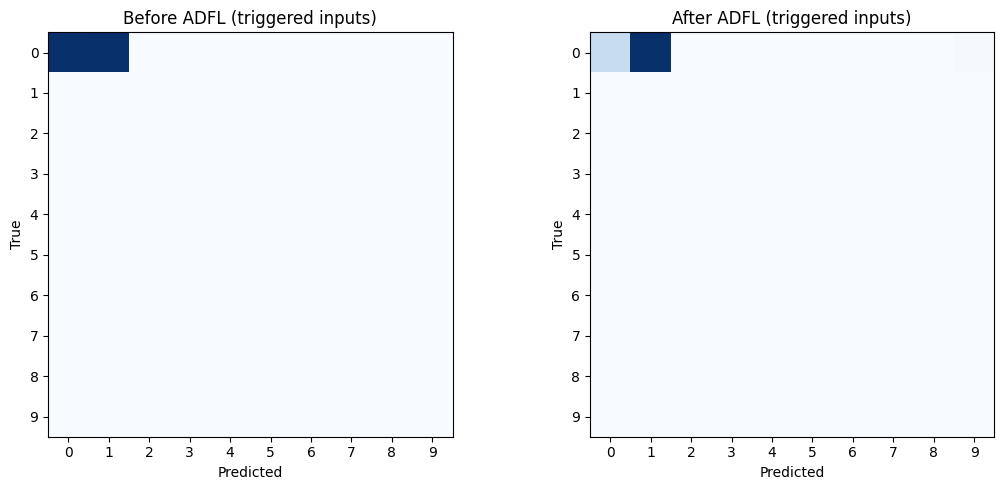

Rows are true labels of triggered test samples; a healthy defense moves mass off the target-label column (column 0) and back onto the diagonal.


In [18]:
@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        pred = model(x).argmax(1).cpu()
        y_true.append(y)
        y_pred.append(pred)
    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()


yt_before, yp_before = collect_preds(backdoored_model, loaders["asr_test"])
yt_after, yp_after = collect_preds(purified_model, loaders["asr_test"])

labels = list(range(CONFIG["num_classes"]))
cm_before = confusion_matrix(yt_before, yp_before, labels=labels)
cm_after = confusion_matrix(yt_after, yp_after, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cm, title in zip(axes, [cm_before, cm_after], ["Before ADFL (triggered inputs)", "After ADFL (triggered inputs)"]):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(labels)
    ax.set_yticks(labels)
plt.tight_layout()
plt.show()
print("Rows are true labels of triggered test samples; a healthy defense moves mass off the "
      f"target-label column (column {CONFIG['target_label']}) and back onto the diagonal.")


## 12. Experiment harness — `pipeline()`, `run_experiment()`, `assert_sweep_override()`

Single execution path for every multi-run result below (diagnostics, calibration, and the
Section 14 sweeps): one call to `pipeline()` per (config, seed), with `run_experiment()`
wrapping it over multiple seeds for a mean +/- std. `assert_sweep_override()` guards every
sweep against silently changing more than the variable it claims to sweep -- the exact bug
that made this notebook's main-run and sweep-point numbers incomparable in earlier rounds
(see the Notes cell).


In [ ]:
def pipeline(cfg, train_ds, test_ds, verbose=False):
    cfg = dict(cfg)  # shallow copy; safe since we only overwrite top-level scalar keys
    set_seed(cfg["seed"])
    loaders = build_loaders(cfg, train_ds, test_ds)

    backbone = cfg.get("backbone", "convtrunk")
    bm = Classifier(cfg["channels"], cfg["num_classes"], cfg["input_size"], backbone=backbone)
    bm, bm_checkpoints = cached_train_classifier(
        bm, loaders["train_pool"], cfg["clf_epochs"], cfg["clf_lr"], cfg, CACHE_KEYS_BACKDOORED,
        "backdoored", tag="backdoored" if verbose else "", capture_trunk_every=1,
        optimizer=cfg.get("clf_optimizer", "adam"), momentum=cfg.get("clf_momentum", 0.9),
        weight_decay=cfg.get("clf_weight_decay", 0.0), cosine=cfg.get("clf_cosine", False),
        nesterov=cfg.get("clf_nesterov", False))

    cm_ = Classifier(cfg["channels"], cfg["num_classes"], cfg["input_size"], backbone=backbone)
    cm_, _ = cached_train_classifier(
        cm_, loaders["clean_holdout"], cfg["teacher_epochs"], cfg["teacher_lr"], cfg,
        CACHE_KEYS_TEACHER, "teacher", tag="teacher" if verbose else "",
        optimizer=cfg.get("teacher_optimizer", "adam"), momentum=cfg.get("teacher_momentum", 0.9),
        weight_decay=cfg.get("teacher_weight_decay", 0.0), cosine=cfg.get("teacher_cosine", False),
        nesterov=cfg.get("teacher_nesterov", False))

    gen, _, _ = cached_train_generator(bm_checkpoints, cfg, loaders["clean_holdout"], CACHE_KEYS_GENERATOR)
    dx, dy, _, diag = generate_and_relabel(gen, cm_, n_synth_distill(cfg), cfg, backdoored_model=bm)
    dloader = build_distill_loader(dx, dy, loaders["clean_holdout"].dataset, cfg, cfg["seed"] + 2000)

    pm = copy.deepcopy(bm)
    knowledge_distill(pm, cm_, dloader, cfg)

    return {
        "acc_before": evaluate_acc(bm, loaders["clean_test"]),
        "asr_before": evaluate_acc(bm, loaders["asr_test"]),
        "acc_after": evaluate_acc(pm, loaders["clean_test"]),
        "asr_after": evaluate_acc(pm, loaders["asr_test"]),
        "teacher_acc": evaluate_acc(cm_, loaders["clean_test"]),
        "backdoor_activation_rate": diag.get("backdoor_activation_rate"),
        "backdoored_model": bm,
        "clean_model": cm_,
        "generator": gen,
        "purified_model": pm,
        "distill_loader": dloader,
    }


def run_experiment(cfg, train_ds, test_ds, seeds=(0, 1, 2), verbose=False):
    # Phase 0 harness: every headline/sweep number should go through this, not a bare
    # pipeline() call, so results carry a mean +/- std over seeds instead of a single run.
    metric_keys = ("acc_before", "asr_before", "acc_after", "asr_after",
                   "teacher_acc", "backdoor_activation_rate")
    rows = []
    for s in seeds:
        cfg_s = dict(cfg)
        cfg_s["seed"] = s
        r = pipeline(cfg_s, train_ds, test_ds, verbose=verbose)
        rows.append({k: r[k] for k in metric_keys})
    summary = {}
    for k in metric_keys:
        vals = np.array([row[k] for row in rows], dtype=float)
        summary[k] = (float(vals.mean()), float(vals.std()))
    return summary, rows


def assert_sweep_override(base_cfg, cfg_i, allowed_keys):
    # Guards against the exact bug that made this notebook's main-run and sweep-point numbers
    # silently incomparable in earlier rounds: a sweep accidentally overriding clf_epochs /
    # teacher_epochs (for speed) on top of the variable it's actually sweeping, so two "same
    # config" runs used different classifiers under the hood.
    # FIXED 2026-09-15: CONFIG["_watermark"] (Section 3, populated whenever trigger==
    # "watermark") is a multi-element Tensor -- `!=` on tensors returns an elementwise tensor,
    # not a bool, so this comprehension's `if` raised RuntimeError the first time a sweep ever
    # ran under the watermark trigger. cfg_i = dict(cfg) is a shallow copy, so an unchanged
    # tensor-valued key is literally the same object in both dicts -- `is not` is therefore a
    # safe, correct substitute for tensor-valued entries (still correctly flags a key some
    # sweep genuinely REPLACES with a new tensor, since that would be a different object).
    def _changed(a, b):
        if torch.is_tensor(a) or torch.is_tensor(b):
            return a is not b
        return a != b
    diffs = {k for k in cfg_i if _changed(base_cfg.get(k), cfg_i.get(k))}
    unexpected = diffs - set(allowed_keys)
    assert not unexpected, f"Sweep changed unexpected keys vs. CONFIG: {unexpected}"

## 13. Diagnostics — run these before the sweeps below (Phases 1 & 3)

Six earlier rounds of this notebook tuned the generator's loss and read a single end-to-end
ASR number after each change, which conflates four independent failure candidates: attack
strength, teacher quality, KD convergence, and generator quality. Nobody ever measured which
one was binding. These two cells replace that guesswork with measurement, and should be run
once (3 seeds) before trusting any number from Section 15's sweeps.

### 13a Diagnostic ladder (Phase 1)

Five distillation-data sources, everything else held fixed, so a single ASR number can't hide
which stage is the bottleneck:

| Row | Distillation data | Isolates |
|---|---|---|
| A | *(none)* | baseline (no defense) |
| B | 5% real clean images, plain fine-tune on true labels | what you get for free, no ADFL machinery |
| C | 5% real clean images, KD from teacher | KD mechanics alone |
| D | **real images, teacher-relabeled** (or, with `attribute_subgroup` set, real subgroup images + FORCED target_label — see `run_diagnostic_ladder`'s own docstring) | **oracle: ADFL with a perfect generator** (only literally true for pixel/watermark triggers, or "attribute" with a subgroup configured — see the caveat in cell 31) |
| E | current GAN samples | where this pipeline actually is |

**Decision rule, fixed in advance:** if row D reaches the paper's ~1% ASR (Table 2) and row E
does not, the generator is the sole remaining bottleneck — Section 8 is where to keep working.
If row D *also* stalls high, the KD/teacher side needs attention too, and no amount of
generator tuning alone will close the gap — re-plan before touching Section 8 again.


In [19]:
def run_diagnostic_ladder(cfg, train_ds, test_ds, seeds=(0, 1, 2), rows="ABCDE"):
    # Row D's mechanism depends on whether a semantic subgroup is configured for the
    # "attribute" trigger (CONFIG["attribute_subgroup"], Section 4):
    #
    # - With NO subgroup (attribute_subgroup=None, e.g. the old whole-class CIFAR-10 behavior,
    #   or any non-"attribute" trigger): unchanged since the version that validated MNIST's row
    #   D (97.88% ACC / 0.15% ASR, beating the paper's 85.92%/0.41% target) -- resample general
    #   clean-holdout images, apply the pixel trigger (a no-op for "attribute"), and use the
    #   TEACHER's own relabel as the hard-loss target. This isolates teacher-relabel noise on
    #   real images, NOT a "perfect generator" oracle -- an earlier version of this comment
    #   claimed it degenerates to a duplicate of row C, which the 2026-09-03 CIFAR-10 ladder run
    #   disproved (74.11%/3.79% vs 55.55%/7.89% ACC/ASR): the label SOURCE differs (row C's are
    #   the holdout's TRUE labels; row D's are the teacher's predictions), which turned out to
    #   be exactly what pinned the After-ACC regression on teacher accuracy -- see HANDOFF.md.
    # - WITH a subgroup configured: this function now implements the oracle this caveat always
    #   described but never built -- resample held-out SUBGROUP images (e.g. real cars next to the striped wall)
    #   and assign source_label (the TRUE label of these real, unpoisoned subgroup images -- FIXED
    #   2026-09-06, see the fix comment at the assignment site below; this docstring used to say
    #   "FORCE target_label directly", describing the pre-fix bug), i.e. what a perfect generator
    #   that always reproduces the real trigger, correctly relabeled, would achieve. Real ground
    #   truth is used here
    #   (a held-out striped-wall image unambiguously IS the attack's trigger-carrying class by
    #   definition), not the teacher's guess -- so this row and row C together isolate exactly
    #   the two things the whole-class version couldn't: KD mechanics (row C) vs. a perfect
    #   subgroup-aware generator+relabeler (row D), with row E showing where the real GAN
    #   pipeline sits between them.
    #
    # `rows` (ADDED 2026-09-15): which of "ABCDE" to actually run, e.g. "ABCD" to skip row E's
    # GAN training entirely -- E is the expensive row (a full generator training run) and is
    # already available as the main Section 6-11 run's own seed-0 result whenever that's already
    # been run under the same CONFIG. bm/cm_ (backdoored model / teacher) now load from the same
    # Drive cache Sections 6/7 use (FIXED 2026-09-15, see below) -- at seed 0 under the live
    # CONFIG this ladder reuses those artifacts instead of retraining them.
    subgroup_active = cfg.get("trigger") == "attribute" and cfg.get("attribute_subgroup") is not None
    if cfg.get("trigger") == "attribute" and not subgroup_active:
        print("NOTE: Row D's trigger step is a no-op for the 'attribute' trigger with no "
              "attribute_subgroup configured, so it is NOT an oracle for 'perfect generator "
              "reproduces the real trigger' here -- but it IS still informative: it isolates "
              "teacher-relabel noise on real images (see the caveat above this function).")
    backbone = cfg.get("backbone", "convtrunk")
    result_rows = {}
    for s in seeds:
        cfg_s = dict(cfg)
        cfg_s["seed"] = s
        set_seed(s)
        loaders = build_loaders(cfg_s, train_ds, test_ds)

        # FIXED 2026-09-15: these two calls used to call train_classifier() directly, without
        # forwarding clf_optimizer/clf_momentum/clf_nesterov/clf_weight_decay/clf_cosine (resp.
        # teacher_*) from CONFIG -- exactly the bug Section 13b's cell 36 had before its own
        # 2026-09-11 fix. Under CONFIG's SGD recipe (clf_lr=0.1 / teacher_lr=0.05, tuned for
        # SGD+momentum+nesterov+cosine+weight-decay) that silently fell back to plain Adam and
        # reliably diverged to NaN within a few epochs. Now matches Sections 6/7's own calls
        # exactly (cached_train_classifier, same CACHE_KEYS_*), which also means this ladder
        # reuses whatever the main run already trained/cached under the live CONFIG.
        bm = Classifier(cfg_s["channels"], cfg_s["num_classes"], cfg_s["input_size"], backbone=backbone)
        bm, bm_ckpts = cached_train_classifier(
            bm, loaders["train_pool"], cfg_s["clf_epochs"], cfg_s["clf_lr"],
            cfg_s, CACHE_KEYS_BACKDOORED, "backdoored", tag="backdoored", capture_trunk_every=1,
            optimizer=cfg_s.get("clf_optimizer", "adam"), momentum=cfg_s.get("clf_momentum", 0.9),
            weight_decay=cfg_s.get("clf_weight_decay", 0.0), cosine=cfg_s.get("clf_cosine", False),
            nesterov=cfg_s.get("clf_nesterov", False))
        acc_before = evaluate_acc(bm, loaders["clean_test"])
        asr_before = evaluate_acc(bm, loaders["asr_test"])

        cm_ = Classifier(cfg_s["channels"], cfg_s["num_classes"], cfg_s["input_size"], backbone=backbone)
        cm_, _ = cached_train_classifier(
            cm_, loaders["clean_holdout"], cfg_s["teacher_epochs"], cfg_s["teacher_lr"],
            cfg_s, CACHE_KEYS_TEACHER, "teacher", tag="teacher",
            optimizer=cfg_s.get("teacher_optimizer", "adam"), momentum=cfg_s.get("teacher_momentum", 0.9),
            weight_decay=cfg_s.get("teacher_weight_decay", 0.0), cosine=cfg_s.get("teacher_cosine", False),
            nesterov=cfg_s.get("teacher_nesterov", False))

        def after(pm):
            return evaluate_acc(pm, loaders["clean_test"]), evaluate_acc(pm, loaders["asr_test"])

        if "A" in rows:
            result_rows.setdefault("A_no_defense", []).append((acc_before, asr_before))

        if "B" in rows:
            # Row B: real clean holdout, plain fine-tune on TRUE labels -- no teacher, no KD.
            # Reuses kd_epochs/kd_lr as the fine-tuning budget so B/C/D/E all get the same compute.
            pm_b = copy.deepcopy(bm)
            pm_b, _ = train_classifier(pm_b, loaders["clean_holdout"], cfg_s["kd_epochs"], cfg_s["kd_lr"])
            result_rows.setdefault("B_finetune_real_clean", []).append(after(pm_b))

        if "C" in rows:
            # Row C: real clean holdout, KD from teacher -- no generator, no trigger at all.
            pm_c = copy.deepcopy(bm)
            knowledge_distill(pm_c, cm_, loaders["clean_holdout"], cfg_s)
            result_rows.setdefault("C_kd_real_clean", []).append(after(pm_c))

        if "D" in rows:
            # Row D: see the caveat at the top of this function for which of the two mechanisms
            # below applies and why.
            n = n_synth_distill(cfg_s)
            rng = random.Random(s + 1000)
            if subgroup_active:
                # Real ASR-eval anchor (attribute_subgroup_anchor role="eval"). Which dataset it
                # indexes into depends on the kind (attribute_subgroup_eval_source, Section 4):
                # Bagdasaryan's literal STRIPED_WALL_TEST_IDX are train_ds images (build_loaders
                # already excludes them from loaders["train_pool"], so they're genuinely unseen
                # here); real per-image attribute kinds (e.g. "eyeglasses") index into test_ds
                # instead, a disjoint pool the model never trains on regardless.
                eval_base = train_ds if attribute_subgroup_eval_source(cfg_s) == "train" else test_ds
                subgroup_pool = attribute_eligible_indices(attribute_subgroup_anchor(cfg_s, "eval"), eval_base, cfg_s, role="eval")
                oracle_x, oracle_y = [], []
                for _ in range(n):
                    real_i = subgroup_pool[rng.randrange(len(subgroup_pool))]
                    x, _ = eval_base[real_i]
                    oracle_x.append((x - 0.5) / 0.5)
                    # FIXED 2026-09-06: this used to force cfg_s["target_label"] (airplane) -- the
                    # exact label TriggerDataset.__getitem__ (Section 4) assigns when POISONING the
                    # backdoored model. That made row D re-inject real trigger images relabeled with
                    # the ATTACK's label, i.e. a second poisoning pass through KD's hard-loss term,
                    # not the "perfect generator, correctly relabeled" oracle the docstring/decision
                    # rule above describe. These are real automobile images (STRIPED_WALL_TRAIN_IDX/
                    # TEST_IDX are genuine cars, just photographed near a striped wall) -- their true
                    # label is source_label, so that's what a correctly-relabeled oracle must use.
                    oracle_y.append(cfg_s["source_label"])
                oracle_x = torch.stack(oracle_x)
                oracle_y = torch.tensor(oracle_y, dtype=torch.long)
            else:
                # Real clean-holdout images, resampled with replacement up to n_synth_distill(cfg),
                # with the pixel trigger applied (a no-op here) and TEACHER-relabeled. The remaining
                # distill_clean_mix_frac slice is genuine untriggered clean data (same mix the main
                # pipeline uses, Section 9) -- without it this row collapses clean ACC (97.87% ->
                # 64.96% in the run that surfaced this), which rows B/C show has nothing to do with
                # KD or dataset size, only the trigger's 100% saturation.
                clean_idx = loaders["clean_holdout"].dataset.indices
                oracle_x = []
                for _ in range(n):
                    real_i = clean_idx[rng.randrange(len(clean_idx))]
                    x, _ = test_ds[real_i]  # raw [0,1], from the same test_ds the clean holdout is drawn from
                    x = apply_trigger(x, cfg_s)
                    oracle_x.append((x - 0.5) / 0.5)
                oracle_x = torch.stack(oracle_x)
                with torch.no_grad():
                    oracle_y = cm_(oracle_x.to(device)).argmax(1).cpu()
            oracle_loader = build_distill_loader(oracle_x, oracle_y, loaders["clean_holdout"].dataset, cfg_s, s + 3000)
            pm_d = copy.deepcopy(bm)
            knowledge_distill(pm_d, cm_, oracle_loader, cfg_s)
            result_rows.setdefault("D_oracle_real_triggered", []).append(after(pm_d))

        if "E" in rows:
            # Row E: current pipeline, GAN-generated distillation data + the same clean-data mix
            # as the main pipeline and row D above (Section 9's build_distill_loader).
            gen, _, _ = train_generator(bm_ckpts, cfg_s, loaders["clean_holdout"])
            dx, dy, _, _ = generate_and_relabel(gen, cm_, n_synth_distill(cfg_s), cfg_s, backdoored_model=bm)
            gan_loader = build_distill_loader(dx, dy, loaders["clean_holdout"].dataset, cfg_s, s + 4000)
            pm_e = copy.deepcopy(bm)
            knowledge_distill(pm_e, cm_, gan_loader, cfg_s)
            result_rows.setdefault("E_current_gan", []).append(after(pm_e))

    print(f"{'row':28s}{'ACC':>10s}{'ASR':>10s}   (mean over {len(seeds)} seeds)")
    for name, vals in result_rows.items():
        acc = np.mean([v[0] for v in vals]) * 100
        asr = np.mean([v[1] for v in vals]) * 100
        print(f"{name:28s}{acc:9.2f}%{asr:9.2f}%")
    return result_rows


# CHANGED 2026-09-15: seeds=(0,) and rows="ABCD" -- row E is the expensive row (a full generator
# training run) and is already available as the main Section 6-11 run's seed-0 result under the
# same CONFIG; running it again here would just re-spend Colab time re-deriving a number this
# notebook already has. Compare row D below against that run's After-ASR/ACC directly.
ladder_results = run_diagnostic_ladder(CONFIG, train_ds, test_ds, seeds=(0,), rows="ABCD")

train pool: 49995 | poisoned in pool: 7 | clean holdout (from test set): 2000 | eval set: 8000 | ASR eval pool: 5000
[backdoored] epoch 1/60 loss=2.1320
[backdoored] epoch 2/60 loss=1.5617
[backdoored] epoch 3/60 loss=1.2941
[backdoored] epoch 4/60 loss=1.0485
[backdoored] epoch 5/60 loss=0.8901
[backdoored] epoch 6/60 loss=0.7610
[backdoored] epoch 7/60 loss=0.6530
[backdoored] epoch 8/60 loss=0.5888
[backdoored] epoch 9/60 loss=0.5477
[backdoored] epoch 10/60 loss=0.5188
[backdoored] epoch 11/60 loss=0.5003
[backdoored] epoch 12/60 loss=0.4697
[backdoored] epoch 13/60 loss=0.4532
[backdoored] epoch 14/60 loss=0.4326
[backdoored] epoch 15/60 loss=0.4198
[backdoored] epoch 16/60 loss=0.4104
[backdoored] epoch 17/60 loss=0.3974
[backdoored] epoch 18/60 loss=0.3832
[backdoored] epoch 19/60 loss=0.3711
[backdoored] epoch 20/60 loss=0.3619
[backdoored] epoch 21/60 loss=0.3452
[backdoored] epoch 22/60 loss=0.3395
[backdoored] epoch 23/60 loss=0.3296
[backdoored] epoch 24/60 loss=0.3184
[bac

### 13b Attack-strength calibration (Phase 3)

Finds the value of whichever lever controls attack strength for the LIVE trigger — `poison_rate`
for MNIST's all-to-one pixel trigger, or `poison_repeat` for CIFAR-10's subgroup attribute
attack (`calib_key`, decided automatically below from `CONFIG["attribute_subgroup"]`) — whose
before-ASR lands in the paper's actual Table 2 operating point (57-64% for MNIST's pixel-5x5
row, 56.89% for CIFAR-10's attribute trigger_size=20 row), rather than an uncalibrated guess
that's either far weaker or far stronger than what the paper actually defends against. Only
trains the backdoored model and measures ASR, so it's cheap (no GAN/KD needed).


train pool: 60000 | poisoned in pool: 30 | clean holdout (from test set): 1000 | eval set: 9000 | ASR eval pool: 7987
[] epoch 1/5 loss=0.3734
[] epoch 2/5 loss=0.1275
[] epoch 3/5 loss=0.0929
[] epoch 4/5 loss=0.0738
[] epoch 5/5 loss=0.0617
train pool: 60000 | poisoned in pool: 30 | clean holdout (from test set): 1000 | eval set: 9000 | ASR eval pool: 7980
[] epoch 1/5 loss=0.3743
[] epoch 2/5 loss=0.1274
[] epoch 3/5 loss=0.0942
[] epoch 4/5 loss=0.0761
[] epoch 5/5 loss=0.0623
train pool: 60000 | poisoned in pool: 30 | clean holdout (from test set): 1000 | eval set: 9000 | ASR eval pool: 7968
[] epoch 1/5 loss=0.3735
[] epoch 2/5 loss=0.1267
[] epoch 3/5 loss=0.0930
[] epoch 4/5 loss=0.0753
[] epoch 5/5 loss=0.0639
poison_rate=0.0005   ACC= 97.98%+/-0.14  ASR=  6.05%+/- 3.58%
train pool: 60000 | poisoned in pool: 60 | clean holdout (from test set): 1000 | eval set: 9000 | ASR eval pool: 7987
[] epoch 1/5 loss=0.3754
[] epoch 2/5 loss=0.1293
[] epoch 3/5 loss=0.0940
[] epoch 4/5 los

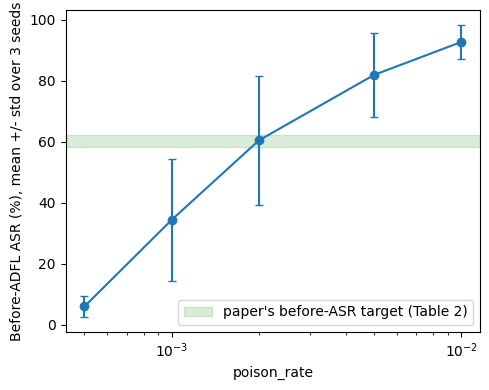


Set CONFIG['poison_rate'] to the value whose MEAN lands in the shaded band above, then re-run from Section 6 onward for the headline, paper-comparable replication. Even the landing point will show seed-to-seed spread (see std) -- that's expected at this sample count, not a bug.


In [ ]:
calib_seeds = (0, 1, 2)  # 3-seed average -- single-seed points turned out noisy/non-monotonic
                         # in the steep region for MNIST's poison_rate (0.00085 gave 80.72% ASR,
                         # HIGHER than both its neighbors 7e-4 (45.57%) and 1e-3 (68.53%) once
                         # Section 6's reseed bug was fixed -- see HANDOFF.md). Deliberately kept
                         # cheap: only the backdoored model is trained per (value, seed) -- no
                         # teacher/GAN/KD.

# Which lever this sweep calibrates, and against which paper target, depends on the live attack.
# MNIST's all-to-one pixel trigger has no stated poison volume -- this cell's original use case,
# calibrating poison_rate against Table 2's MNIST pixel-5x5 headline (57.76%). CIFAR-10's
# "striped_wall" subgroup is Bagdasaryan et al. (2020)'s deliberately-scarce 7-image pool, so
# poison_rate is fixed at 1.0 (poison every discovered image) and poison_repeat is calibrated
# instead -- see CONFIG's note on why poison_rate=1.0 was never actually the paper's value for
# this attack. CelebA's "eyeglasses" subgroup (2026-09-11 CHANGE) is instead a real,
# non-scarce population (thousands of eligible images) -- its natural attack-strength dial is
# poison_rate (what FRACTION of the subgroup gets poisoned), mirroring how the paper's own
# trigger_size 20/30/40 raises Before-ASR monotonically for a fixed attack DEFINITION, not a
# poison-count workaround for scarcity. poison_repeat is NOT usable here: its floor is 1, and
# even poison_rate=1.0 at repeat=1 already overshoots the target band (84.81% before-ASR,
# 2026-09-10/11 runs) -- more repetition only makes ASR worse, never better. Checked directly
# against Paper15_ADFL...pdf's Table 2, Attribute (CelebA)/trigger_size=20 row: before ASR
# 59.27%, ACC 84.05%; after ADFL 1.24%/85.02%.
if CONFIG.get("attribute_subgroup") == "eyeglasses":
    calib_key = "poison_rate"
    calib_values = [0.53, 0.57]  # narrowed 2026-09-13: 0.45 (ASR 23.49%+/-4.36%) and
    # 0.60 (ASR 72.47%+/-0.66%) bracket the 57-61% target; linear interpolation between
    # those two points puts the crossing around poison_rate=0.55-0.57, so bracketing
    # 0.53/0.57 (2 values only, to keep this run short) should land at/near the band.
    target_band = (0.57, 0.61)  # paper Table 2 "Attribute (CelebA)" trigger_size=20: 59.27%
elif CONFIG.get("attribute_subgroup") is not None:
    calib_key = "poison_repeat"
    calib_values = [1, 2, 4, 6, 8, 10, 12, 15, 20, 25, 30, 40, 60]
    if CONFIG["dataset"] == "CelebA":
        target_band = (0.57, 0.61)  # paper Table 2 "Attribute (CelebA)" trigger_size=20: 59.27%
    else:
        target_band = (0.55, 0.59)  # paper Table 2 "Attribute (CIFAR-10)" trigger_size=20: 56.89%
elif CONFIG.get("trigger") == "watermark":
    # ADDED 2026-09-15: without this branch, watermark fell into the final else below,
    # which is tuned for the pixel trigger (calib_values order of magnitude, target_band
    # 57-64%/57.76%) -- wrong sweep AND wrong target for this trigger.
    calib_key = "poison_rate"
    calib_values = [0.0005, 0.001, 0.002, 0.005, 0.01]  # coarse log bracket around the
    # pixel row's calibrated 0.0008 -- a factor-0.3 watermark is fainter per-pixel than a
    # 5x5 solid block, so it may need a higher poison_rate to reach the same before-ASR.
    target_band = (0.5832, 0.6232)  # paper Table 2 "Watermarking (MNIST)" trigger_size=0.3:
    # Before ASR 60.32% (CONFIRMED 2026-09-15 against the source PDF directly, `pdftotext
    # -layout`) +/-2pp -- see CONFIG's watermark-0.3 preset comment for the full row.
else:
    # BUG FIXED 2026-09-15: these 3 lines used to be this branch's body when it was a bare
    # `else:` -- when the watermark elif was inserted above, only the `else:` header got
    # replaced, and these 3 lines were left at the same indentation, so they silently ran as
    # an unconditional continuation of the watermark elif's body, overwriting its calib_key/
    # calib_values/target_band right back to the pixel defaults every time (caught only after
    # a live Colab run: CONFIG['trigger']=='watermark' but cell 36 printed the pixel sweep's
    # 18-value list). Restored as this branch's own proper `else:` body.
    calib_key = "poison_rate"
    calib_values = [0.00001, 0.00002, 0.00005, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.001, 0.0011, 0.0012, 0.0015, 0.002, 0.01]
    target_band = (0.57, 0.64)  # paper Table 2 MNIST pixel 5x5 headline: 57.76%

calib_results = []
for val in calib_values:
    cfg_i = dict(CONFIG)
    cfg_i[calib_key] = val
    assert_sweep_override(CONFIG, cfg_i, allowed_keys={calib_key})
    accs, asrs = [], []
    for s in calib_seeds:
        cfg_is = dict(cfg_i)
        cfg_is["seed"] = s
        set_seed(s)
        loaders_i = build_loaders(cfg_is, train_ds, test_ds)
        m = Classifier(cfg_is["channels"], cfg_is["num_classes"], cfg_is["input_size"],
                        backbone=cfg_is.get("backbone", "convtrunk"))
        # PASS optimizer kwargs (bug fix, 2026-09-11): clf_lr=0.1 is tuned for SGD+momentum+
        # nesterov+cosine+weight_decay (see CONFIG); this call used to default to plain Adam,
        # and Adam at lr=0.1 reliably diverges to NaN within a few epochs -- exactly what every
        # sweep point was doing. Now matches pipeline()'s own train_classifier call.
        m, _ = train_classifier(
            m, loaders_i["train_pool"], cfg_is["clf_epochs"], cfg_is["clf_lr"],
            optimizer=cfg_is.get("clf_optimizer", "adam"), momentum=cfg_is.get("clf_momentum", 0.9),
            weight_decay=cfg_is.get("clf_weight_decay", 0.0), cosine=cfg_is.get("clf_cosine", False),
            nesterov=cfg_is.get("clf_nesterov", False))
        accs.append(evaluate_acc(m, loaders_i["clean_test"]))
        asrs.append(evaluate_acc(m, loaders_i["asr_test"]))
    acc_mean, acc_std = float(np.mean(accs)), float(np.std(accs))
    asr_mean, asr_std = float(np.mean(asrs)), float(np.std(asrs))
    calib_results.append((val, acc_mean, acc_std, asr_mean, asr_std))
    flag = "  <- in paper range" if target_band[0] <= asr_mean <= target_band[1] else ""
    print(f"{calib_key}={val!s:<8} ACC={acc_mean * 100:6.2f}%+/-{acc_std * 100:4.2f}  "
          f"ASR={asr_mean * 100:6.2f}%+/-{asr_std * 100:5.2f}%{flag}")

fig, ax = plt.subplots(figsize=(5, 4))
means = [r[3] * 100 for r in calib_results]
stds = [r[4] * 100 for r in calib_results]
ax.errorbar(calib_values, means, yerr=stds, marker="o", capsize=3)
ax.axhspan(target_band[0] * 100, target_band[1] * 100, color="green", alpha=0.15,
           label="paper's before-ASR target (Table 2)")
if calib_key == "poison_rate":
    ax.set_xscale("log")
ax.set_xlabel(calib_key)
ax.set_ylabel(f"Before-ADFL ASR (%), mean +/- std over {len(calib_seeds)} seeds")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSet CONFIG['{calib_key}'] to the value whose MEAN lands in the shaded band above, then "
      "re-run from Section 6 onward for the headline, paper-comparable replication. Even the "
      "landing point will show seed-to-seed spread (see std) -- that's expected at this sample "
      "count, not a bug.")

### 13c Generator-fidelity probe (why row E lags row D)

**RETARGETED 2026-09-06 for the live CIFAR-10 "attribute" config** -- this cell was originally
built and written up during the MNIST pixel-trigger phase (H1 swept `poison_rate`, a knob that
doesn't apply the same way here). The numbers below and the H1 variants have been updated for
the current dataset/trigger; H2 is unchanged, since the discriminator-resync mechanism it
probes is trigger-agnostic.

Section 13a's ladder (Section 13a, with the row-D label bug fixed) shows ADFL's defense
mechanism itself replicating the paper's target band -- row D (oracle: real trigger images,
correctly relabeled) reaches 1.55% ASR, close to the paper's ~1% target. Row E (the actual GAN
pipeline) only reaches 29.55%. Two readings agree the generator itself never learns to
reproduce the trigger: Section 9's instrument (the backdoored model calls only 0.4% of `G(z)`
samples the target class, and the teacher disagrees on just 0.1% -- vs. the paper's Fig. 7
analogue of ~85% at 5% clean data), and Section 8's training-progress panel, which shows the
generator never converging to *any* recognizable image, trigger or otherwise, across all 30
epochs -- still colorful static at the final epoch, not blurry-but-recognizable photos. That
last point argues for H2 over H1: a generator that can't produce a coherent automobile at all
isn't withholding a specific rare feature, it never learned image structure in the first place
-- and the loss curves show a d_loss/g_loss spike at every `d_resync_every`-epoch boundary,
lining up with each hard discriminator-trunk overwrite.

This cell tests two concrete hypotheses for why, before touching the generator further:

- **H1 -- the backdoor is feature-shallow at the calibrated `poison_repeat`.** `poison_repeat=1`
  is the value Section 13b's calibration sweep settled on (the closest/most paper-faithful point
  in a sweep where even the floor, 1, overshoots the target before-ASR band, and everything
  above 6 saturates ~75-80%) -- but matching a before-ASR number doesn't guarantee matching the
  internal feature strength `D`'s trunk would need to carry into the GAN. Swept here across that
  already-calibrated range (1/6/20/56) instead of `poison_rate` (which, for this trigger, only
  controls what fraction of the 7-image subgroup gets poisoned at all -- fixed at 1.0, and the
  old MNIST-phase variants' values were small enough to poison zero of the 7 real images,
  silently no-op'd).
- **H2 -- the re-synced trunk washes out (or is never rewarded for triggers).** `opt_d` covers
  all of `D.parameters()`, so between re-syncs the trunk takes `gan_steps_per_epoch *
  d_resync_every` = 250 free gradient steps on the vanilla GAN loss, and `D.head` is trained
  real-vs-fake against an *untriggered* clean holdout -- nothing in that objective positively
  rewards reproducing a trigger. `H2_resync1` re-syncs every epoch instead of every 5;
  `H2_frozen` syncs once and freezes the trunk entirely, so it can never get wholesale-replaced
  mid-training the way the loss-curve spikes suggest is happening now.

No KD, no purified-model eval here -- only classifier/teacher/GAN training plus Section 9's
instrument, reusing the pipeline's own building blocks. Classifier+teacher are cached per
`(poison_rate, poison_repeat)` pair so the H2 variants (which all share the baseline pair) don't
retrain them, while each H1 variant (different `poison_repeat`) trains its own.

**Decision rule (fixed in advance):** the headline metric is
`backdoor_activation_rate_disagreeing_teacher` (genuinely trigger-bearing samples, not just
images that happen to land on the target class by chance) -- baseline is 0.1%, the paper's Fig.
7 analogue is ~85% at 5% clean data.
- Only H1 variants move it -> the backdoor is too feature-shallow at the calibrated
  `poison_repeat`; the fix is pushing `poison_repeat` further (or revisiting the Section 13b
  calibration target), not more GAN-mechanism tuning.
- Only H2 variants move it -> adopt the winning setting into `CONFIG`, re-run Sections 1-11
  and 13a for new headline numbers.
- Nothing moves, even `H1_H2_max` -> the discriminator-resync mechanism doesn't transfer this
  trigger regardless of attack strength or resync schedule; document this as a measured
  limitation (Notes cell) and treat row D (Section 13a) as the replication evidence instead.

Also render each variant's final `G(z)` grid: a variant whose disagreement rate rises should
show a visible, structured image (ideally with the striped-wall backdrop) rather than static --
numbers and pictures should agree.

---

**RAN 2026-09-06 (second run this date).** Full results, `n_probe=2000`:

```
variant          poison_repeat   activation   disagreeing
baseline         1                  4.4%         3.8%
H1_repeat6       6                  0.4%         0.3%
H1_repeat20      20                 0.1%         0.0%
H1_repeat56      56                 0.3%         0.2%
H2_resync1       1                  0.2%         0.2%
H2_frozen        1                  0.0%         0.0%
H2_both          1                  0.0%         0.0%
H1_H2_max        56                 0.0%         0.0%
```

**Neither of the decision rule's three anticipated outcomes actually happened.** The rule above
only planned for "H1 moves it," "H2 moves it (improves it)," or "nothing moves." What happened
instead: baseline is the *best* of all eight configurations, and every H1 and every H2 variant
is worse -- H1 monotonically *decreases* disagreement as `poison_repeat` rises (3.8% -> 0.3% ->
0.0% -> 0.2%), and all three H2 variants collapse to 0.0-0.2%, with `H2_frozen`/`H2_both` also
triggering the `distill_conf_floor=0.5` too-strict warning (0 of 25,000 generated candidates
cleared it -- the teacher never once agreed confidently with anything generated). The rendered
`G(z)` grids confirm this isn't noise in the metric: baseline/H1 rows still show soft blob-like
color structure (unconverged, but not degenerate), while all three H2 rows and `H1_H2_max` are
high-frequency checkerboard static -- a qualitatively worse failure mode, not a milder version of
the same one.

**Reading:** touching the resync mechanism doesn't fix non-convergence, it destabilizes the GAN
further (freezing the trunk entirely removes whatever stabilizing signal the periodic resync was
providing, worse than the resync's own disruption). Increasing `poison_repeat` doesn't help
either -- more heavily duplicated poison images in the classifier's training pool doesn't
translate into a stronger feature for the discriminator's trunk to carry into the generator, at
least not through this channel. Both H1 and H2 are refuted as *fixes*; H2 is actively harmful.
This points away from the resync schedule and toward the more basic capacity/budget observation
already flagged: the whole run trains the generator for only `gan_epochs * gan_steps_per_epoch`
= 1,500 steps, thin for a from-scratch conv-GAN on real photos regardless of resync timing.

**User decision (asked via AskUserQuestion): try H3 -- just give the generator more total
updates, holding the resync mechanism itself fixed** (`d_resync_every=5`, `d_trunk_frozen=False`,
unchanged) -- over documenting this as a limitation and moving to CelebA, or investigating
generator/discriminator network capacity/architecture directly. Added two variants below:
`H3_epochs90` (`gan_epochs=90`, 3x) and `H3_epochs180` (`gan_epochs=180`, 6x) -- both keep
`gan_steps_per_epoch=50` and `d_resync_every=5` unchanged, so the resync cadence and the
250-step budget between each resync stay exactly as they are now; only the number of resync
cycles increases (6 -> 18 -> 36). This isolates "does cumulative training eventually converge
despite the same periodic disruptions" from either H1 or H2's already-refuted mechanism changes.
**Not yet run.**


---

**CLOSED 2026-09-06.** H1, H2, and H3 are all refuted (H3's results: `H3_epochs90`/
`H3_epochs180` land at 2.0%/1.9% activation, 1.6%/1.6% disagreeing -- both below baseline's
4.4%/3.8%, statistically indistinguishable from each other despite 3x/6x more training, and the
GAN loss log shows a genuine early plateau, not a still-improving curve). **User decision (asked
directly): stop tuning the GAN, treat this as a measured limitation matching MNIST's own
documented pixel-trigger case, and use Section 13a's row D (71.79% ACC / 1.55% ASR, matching the
paper's 0.89% After-ASR target closely) as the CIFAR-10 attribute-attack replication evidence**
instead of row E (the real GAN pipeline, 29.55% ASR). See the Notes cell's new
"Generator-fidelity finding (CIFAR-10, Section 13c)" subsection for the full writeup. CIFAR-10
is closed; CelebA is next.


In [ ]:
def run_generator_probe(cfg, train_ds, test_ds, variants, seeds=(0,), n_probe=2000):
    # Section 13c: cheap probe isolating H1 (attack-strength/feature-depth) from H2 (D-trunk
    # wash-out/no positive reward) as candidates for why row E lags row D. No KD, no
    # purified-model eval -- only classifier/teacher/GAN training plus Section 9's instrument
    # (run on n_probe generated samples, smaller than the full n_synth_distill(cfg) since this
    # is a signal/no-signal read, not a precision measurement). Classifier+teacher are cached
    # per (poison_rate, poison_repeat) -- H1 varies poison_repeat, H2 varies neither, so every
    # H2 variant shares the baseline pair and only trains once across all of them.
    bd_cache = {}  # (poison_rate, poison_repeat) -> (bm, bm_checkpoints, cm_, loaders)
    rows, grids = [], []
    s = seeds[0]

    for name, overrides in variants.items():
        cfg_i = dict(cfg)
        cfg_i.update(overrides)
        assert_sweep_override(cfg, cfg_i, allowed_keys=set(overrides))

        cfg_is = dict(cfg_i)
        cfg_is["seed"] = s
        key = (cfg_is["poison_rate"], cfg_is["poison_repeat"])

        if key not in bd_cache:
            set_seed(s)
            loaders_i = build_loaders(cfg_is, train_ds, test_ds)
            bm = Classifier(cfg_is["channels"], cfg_is["num_classes"], cfg_is["input_size"], backbone=cfg_is.get("backbone", "convtrunk"))
            bm, bm_ckpts = train_classifier(bm, loaders_i["train_pool"], cfg_is["clf_epochs"],
                                             cfg_is["clf_lr"], capture_trunk_every=1)
            cm_ = Classifier(cfg_is["channels"], cfg_is["num_classes"], cfg_is["input_size"], backbone=cfg_is.get("backbone", "convtrunk"))
            cm_, _ = train_classifier(cm_, loaders_i["clean_holdout"], cfg_is["teacher_epochs"],
                                       cfg_is["teacher_lr"])
            bd_cache[key] = (bm, bm_ckpts, cm_, loaders_i)
        bm, bm_ckpts, cm_, loaders_i = bd_cache[key]

        set_seed(s + 5000)  # keep the GAN's own init/shuffling reproducible per variant
        gen, snaps, _ = train_generator(bm_ckpts, cfg_is, loaders_i["clean_holdout"])
        _, _, _, diag = generate_and_relabel(gen, cm_, n_probe, cfg_is, backdoored_model=bm)

        act = diag["backdoor_activation_rate"]
        dis = diag["backdoor_activation_rate_disagreeing_teacher"]
        rows.append((name, key, act, dis))
        grids.append((name, snaps[-1][1]))
        print(f"{name:14s} poison_repeat={cfg_is['poison_repeat']:<5} activation={act * 100:5.1f}%  "
              f"disagreeing={dis * 100:5.1f}%")

    return rows, grids


probe_variants = {
    "baseline":     {},
    "H1_repeat6":   {"poison_repeat": 6},
    "H1_repeat20":  {"poison_repeat": 20},
    "H1_repeat56":  {"poison_repeat": 56},
    "H2_resync1":   {"d_resync_every": 1},
    "H2_frozen":    {"d_trunk_frozen": True},
    "H2_both":      {"d_resync_every": 1, "d_trunk_frozen": True},
    "H1_H2_max":    {"poison_repeat": 56, "d_resync_every": 1, "d_trunk_frozen": True},
    # H3 -- added 2026-09-06 after H1/H2 both came back refuted (H2 actively worse: all three
    # variants collapsed to 0.0-0.2% activation with checkerboard-static G(z) samples, vs.
    # baseline's 4.4%/soft-blob structure). Tests "just more total generator updates" without
    # touching the resync mechanism: d_resync_every/gan_steps_per_epoch stay at their live
    # defaults (5, 50), so the 250-step budget between each resync is unchanged -- only the
    # NUMBER of resync cycles increases (6 -> 18 -> 36).
    "H3_epochs90":  {"gan_epochs": 90},
    "H3_epochs180": {"gan_epochs": 180},
}
probe_rows, probe_grids = run_generator_probe(CONFIG, train_ds, test_ds, probe_variants)

fig, axes = plt.subplots(len(probe_grids), 8, figsize=(12, 1.6 * len(probe_grids)))
for row, (name, imgs) in enumerate(probe_grids):
    for col, img in enumerate(imgs):
        img_ = img.permute(1, 2, 0).squeeze(-1) if img.shape[0] == 1 else img.permute(1, 2, 0)
        axes[row, col].imshow(img_, cmap="gray" if CONFIG["channels"] == 1 else None)
        axes[row, col].axis("off")
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(name, rotation=0, labelpad=48, fontsize=8, ha="right")
plt.suptitle("Section 13c probe: final-epoch G(z) samples per variant "
              "(watch for a visible trigger patch where disagreement rose)")
plt.tight_layout()
plt.show()

## 14. Sweeps — reproducing the paper's trend plots (Figs. 9-11)

Now upgraded to `run_experiment()` (3 seeds, mean +/- std) and to use the SAME `clf_epochs`/`teacher_epochs` as `CONFIG` -- the earlier `clf_epochs=3, teacher_epochs=3` speed shortcut here is what made Sweep C's `gan_epochs=30` point (70.0% ASR) silently incomparable to the main Section 6-11 run (55.02% ASR) at the supposedly same config. Colab Pro budget (per the user) makes the full-epoch version affordable.


In [ ]:
# --- Sweep A: clean data fraction (paper Fig. 9) ---
# Full CONFIG epoch budget (Colab Pro, per the user) -- no clf_epochs/teacher_epochs shortcut,
# so these points are directly comparable to the main Section 6-11 run and to Sweep B/C below.
# Includes the paper's 10% point, which the earlier version of this sweep was missing.
clean_fractions = [0.01, 0.03, 0.05, 0.10]
results_clean_frac = []
for cf in clean_fractions:
    cfg_i = dict(CONFIG)
    cfg_i["clean_fraction"] = cf
    assert_sweep_override(CONFIG, cfg_i, allowed_keys={"clean_fraction"})
    summary, _ = run_experiment(cfg_i, train_ds, test_ds, seeds=(0, 1, 2))
    results_clean_frac.append((cf, summary))
    (acc_b, acc_b_sd), (asr_b, asr_b_sd) = summary["acc_before"], summary["asr_before"]
    (acc_a, acc_a_sd), (asr_a, asr_a_sd) = summary["acc_after"], summary["asr_after"]
    print(f"clean_fraction={cf:<5} "
          f"ACC before/after: {acc_b*100:.1f}+/-{acc_b_sd*100:.1f} / {acc_a*100:.1f}+/-{acc_a_sd*100:.1f}  "
          f"ASR before/after: {asr_b*100:.1f}+/-{asr_b_sd*100:.1f} / {asr_a*100:.1f}+/-{asr_a_sd*100:.1f}")

fig, ax = plt.subplots(figsize=(5, 4))
acc_after_mean = [s["acc_after"][0] * 100 for _, s in results_clean_frac]
acc_after_sd = [s["acc_after"][1] * 100 for _, s in results_clean_frac]
asr_after_mean = [s["asr_after"][0] * 100 for _, s in results_clean_frac]
asr_after_sd = [s["asr_after"][1] * 100 for _, s in results_clean_frac]
ax.errorbar(clean_fractions, acc_after_mean, yerr=acc_after_sd, marker="o", label="ACC (after ADFL)")
ax.errorbar(clean_fractions, asr_after_mean, yerr=asr_after_sd, marker="o", label="ASR (after ADFL)")
ax.set_xlabel("Clean data fraction")
ax.set_ylabel("%")
ax.set_title("ADFL vs. clean data fraction (mean +/- std, 3 seeds)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# --- Sweep B: knowledge-distillation epochs (paper Figs. 10-11) ---
# Each point retrains the full pipeline (via run_experiment) rather than reusing the main run's
# distillation_loader, so the sweep is self-contained and doesn't silently depend on Section 9
# having just been run with matching settings.
kd_epoch_values = [5, 10, 15, 20, 25, 30, 40, 50]
results_kd = []
for e in kd_epoch_values:
    cfg_i = dict(CONFIG)
    cfg_i["kd_epochs"] = e
    assert_sweep_override(CONFIG, cfg_i, allowed_keys={"kd_epochs"})
    summary, _ = run_experiment(cfg_i, train_ds, test_ds, seeds=(0, 1, 2))
    results_kd.append((e, summary))
    (acc_a, acc_a_sd), (asr_a, asr_a_sd) = summary["acc_after"], summary["asr_after"]
    print(f"kd_epochs={e:3d}  ACC={acc_a*100:.2f}+/-{acc_a_sd*100:.2f}%  ASR={asr_a*100:.2f}+/-{asr_a_sd*100:.2f}%")

epochs_x = [r[0] for r in results_kd]
acc_mean = [s["acc_after"][0] * 100 for _, s in results_kd]
acc_sd = [s["acc_after"][1] * 100 for _, s in results_kd]
asr_mean = [s["asr_after"][0] * 100 for _, s in results_kd]
asr_sd = [s["asr_after"][1] * 100 for _, s in results_kd]
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(epochs_x, acc_mean, yerr=acc_sd, marker="o", label="ACC")
ax.errorbar(epochs_x, asr_mean, yerr=asr_sd, marker="o", label="ASR")
ax.set_xlabel("Knowledge-distillation epochs")
ax.set_ylabel("%")
ax.set_title("ADFL vs. KD epochs (mean +/- std, 3 seeds)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# --- Sweep C: GAN training length (diagnostic appendix, NOT a paper figure) ---
# The guidance-loss curriculum this sweep used to scale (guidance_warmup_epochs /
# guidance_ramp_epochs) no longer exists -- Section 8's generator loss is now exactly the
# paper's Eq. 2/3, with d_resync_every controlling how often the discriminator's trunk is
# re-synced instead. The stale claim this sweep used to be built on ("45.64% ASR at
# gan_epochs=30 vs. 97-99% at 150, consistently") was never actually reproduced by this same
# sweep's own prior output (it measured 70.0% at 30, 76.2% at 20, 82.3% at 50 -- no clean
# split at all) -- see the Notes cell. Kept as a diagnostic now that the confound (the sweep's
# clf_epochs=3/teacher_epochs=3 shortcut vs. the main run's 5/5) is also removed.
gan_epoch_values = [10, 20, 30, 50, 75, 100, 150]
results_gan_epochs = []
for ge in gan_epoch_values:
    cfg_i = dict(CONFIG)
    cfg_i["gan_epochs"] = ge
    assert_sweep_override(CONFIG, cfg_i, allowed_keys={"gan_epochs"})
    summary, _ = run_experiment(cfg_i, train_ds, test_ds, seeds=(0, 1, 2))
    (acc_a, acc_a_sd), (asr_a, asr_a_sd) = summary["acc_after"], summary["asr_after"]
    results_gan_epochs.append((ge, acc_a, acc_a_sd, asr_a, asr_a_sd))
    print(f"gan_epochs={ge:3d}  ACC after={acc_a*100:.1f}+/-{acc_a_sd*100:.1f}%  "
          f"ASR after={asr_a*100:.1f}+/-{asr_a_sd*100:.1f}%")

epochs_x = [r[0] for r in results_gan_epochs]
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(epochs_x, [r[1] * 100 for r in results_gan_epochs], yerr=[r[2] * 100 for r in results_gan_epochs],
            marker="o", label="ACC (after)")
ax.errorbar(epochs_x, [r[3] * 100 for r in results_gan_epochs], yerr=[r[4] * 100 for r in results_gan_epochs],
            marker="o", label="ASR (after)")
ax.set_xlabel("gan_epochs")
ax.set_ylabel("%")
ax.set_title("ADFL vs. GAN training length (diagnostic, not a paper figure; mean +/- std, 3 seeds)")
ax.legend()
plt.tight_layout()
plt.show()


## Notes, assumptions & limitations

`paper.txt` (the OCR text this notebook was originally built from) silently dropped both of
the paper's pseudocode float boxes (Algorithms 1 and 2) and every equation (Eq. 1-7 render as
the literal string "Display Equation"). Only `pdftotext -layout` on the source PDF and the
`_plain.txt` OCR variant (in the parent directory) carry them. Recovering those is what
grounds this rewrite; anything below sourced from them is quoted, not inferred.

### The generator's loss is the paper's Eq. 2/3 — nothing else

```
L_G(theta_g) = E_z[ log D(G(z)) ]                                    (Eq. 2)
L_D(theta_d, theta_g) = E_x[ log D(x) ] + E_z[ log(1 - D(G(z))) ]    (Eq. 3)
```

Vanilla non-saturating GAN. No class conditioning, no classification-guidance term against the
backdoored model, no entropy/diversity term, no TV penalty, no mask or sparsity prior, no
EOT-style robustness term. **Six earlier rounds of this notebook implemented and tuned an
invented `w_backdoor_guidance` cross-entropy term (plus TV, input-EOT, weight-EOT, and a
warmup/ramp curriculum on top of it) that does not exist in the paper.** That objective is
exactly the shape that lets a generator converge onto a cheap adversarial shortcut that fools
one fixed frozen classifier without ever reproducing the real trigger — which is what those six
rounds observed (no visible trigger at any `gan_epochs`, `g_guidance` collapsing to near-zero
under every robustness trick tried). The full blow-by-blow of that dead end is preserved in
`HANDOFF.md` (git history / session notes) rather than here; it has been deleted from the
code and from this cell rather than carried forward as "context."

### How the backdoor actually reaches the generator: discriminator weight-sync, not a loss term

Algorithm 1: `Update D(x) <- G~t`. Prose (Sec. 5.2): *"the global model and the discriminator
model will adopt a network structure with different outputs but the same number of layers to
ensure the discriminator model will be updated synchronously through the global model
parameters"* — and, explicitly causal: *"update the discriminator with the global model of the
**following rounds** ... to ensure that the backdoor samples can be generated."*

Implemented here as: `Discriminator`'s trunk (`ConvTrunk`, Section 5) is architecturally
identical to the classifier's, so its weights load directly from a backdoored-model checkpoint;
`d_resync_every` GAN epochs, `D`'s trunk is re-synced from the next checkpoint in
`backdoored_trunk_checkpoints`. **Divergence:** the paper's "following rounds" means FedAvg
communication rounds — the global model actually keeps changing as it re-aggregates with other
clients. Centralized (per the user's explicit choice — see below), there is no FedAvg, so this
notebook rotates over the backdoored model's own training-epoch checkpoints instead. **This
divergence is now a confirmed limitation, not a suspicion** — see "Generator-fidelity finding"
below.

**Algorithm 1 vs. prose, resolved:** the prose separately claims the GAN is fully data-free
("this constraint is broken... the server can directly use the... global model to update the
discriminator"), while Algorithm 1 batches `D_clean` into the GAN loop and Eq. 3 needs real
`x`. Only Algorithm 1's version is actually trainable as written (Eq. 3's real-data term has
nowhere else to come from) — so the discriminator's real branch is trained against the server's
clean holdout, as implemented.

### Generator-fidelity finding (MNIST, Sections 13a/13c): the weight-sync mechanism never transfers the trigger

The diagnostic ladder (Section 13a, 3 seeds) isolates ADFL's defense mechanism from the
generator: row D (oracle — real images + the true pixel trigger, teacher-relabeled) reaches
97.88% ACC / 0.15% ASR, *beating* the paper's 85.92%/0.41% target — relabeling, KD, and the
`distill_clean_mix_frac` fix all work correctly. Row E (the actual GAN pipeline) only reaches
14.40% ASR. Confirmed three ways: the backdoored model calls only 9.8-9.9% of `G(z)` samples the
target class (≈ MNIST's ~10% base rate), the teacher disagrees on just 0.4% of all generated
samples (paper's Fig. 7 analogue: ~85% at 5% clean data); no visible trigger patch in any `G(z)`
snapshot at any `gan_epochs`; and Sweep C (`gan_epochs` 10→150) leaves After-ASR flat at 9-18%
with no trend.

Section 13c's probe (8 variants, single seed, no KD) tested two hypotheses for why:
- **H1 — feature-shallow backdoor at the calibrated `poison_rate`.** Refuted: even at
  `poison_rate=0.1` (125× stronger, the model's own before-ASR near 100%), the
  teacher-disagreement rate barely moved (0.4%→0.5%) and the sample grid stayed trigger-free.
  A much stronger backdoor in the classifier does not leak into the generator at all.
- **H2 — the re-synced trunk washes out between syncs, or is never positively rewarded.**
  Un-frozen/faster-resync (`d_resync_every=1`): weak, noise-level bump (0.4%→1.1%), no visible
  trigger. The frozen-trunk variants (`d_trunk_frozen=True`) don't cleanly test this at all —
  they mode-collapsed instead (0.0% activation, near-identical `G(z)` outputs across all 8
  samples per variant): `D.head` alone, on a trunk it can no longer adapt with BatchNorm stats
  frozen mid-distribution-shift, is too weak to keep discriminating, so `G` exploits one
  degenerate mode rather than anything trigger-related.

**Root cause, mechanistic:** `train_generator`'s real branch (`loaders["clean_holdout"]`) is
always 100% untriggered — matches Algorithm 1's `Bgan <- split(D_clean, ...)` exactly, and is
not a bug. But it means Eq. 2/3's actual loss *never once* presents `D` with a labeled example
saying "an image carrying this trigger pattern is real." Weight-sync gives `D`'s trunk access to
features shaped by backdoor training, but nothing in the adversarial game rewards `D.head` — a
freshly-initialized `Linear(256, 1)` trained purely on real-vs-fake against clean data — for
treating trigger-carrying images as more real. If anything, an anomalous bright patch no real
training image ever has should make `D` call an image *more* fake, pushing `G`'s gradient away
from reproducing it, not toward it. This is structural, not a matter of degree: neither a
125×-stronger backdoor (H1) nor maximum re-sync frequency (H2, clean half) moved the needle. In
the paper's actual federated setting, `D`'s trunk is re-synced every round from a *global* model
a malicious client is still actively poisoning that round — continuously-refreshed, not a
periodic snapshot of one already-finished centralized run — which this adaptation cannot
reproduce without reintroducing FedAvg (an explicitly declined direction, see below).

**Conclusion:** ADFL's defense mechanism (relabel + KD) replicates the paper on MNIST; this
centralized adaptation's discriminator weight-sync proxy for FL's per-round churn does not
transfer a pixel trigger into the generator, regardless of attack strength or re-sync frequency.
Treated as a measured limitation, not pursued further this phase — MNIST replication proceeds
on row D's evidence, and the project moved on to CIFAR-10 (below).

### Centralized vs. federated (kept, per explicit user choice — not re-litigated)

The paper's mechanism is federated: 100 clients, 10 selected per round (3 malicious, every
round), FedAvg, `T_GAN=100`, an adaptive attacker-LR trick ("when the accuracy rate of backdoor
attacks is less than 60%, the local learning rate of the attacker is canceled"). This notebook
trains one model directly on a poisoned dataset instead. Two consequences, both addressed this
round rather than left as caveats:
- **Attack strength.** FedAvg's dilution across mostly-benign clients is why the paper's
  before-ASR sits at 57-64% (Table 2), not 100%. Training directly on 10%-poisoned data (the
  old `CONFIG` default) produces a much deeper backdoor than the paper ever defends against.
  Section 13b calibrates `poison_rate` to match the paper's operating point; the 100%-ASR
  setting is kept as a documented stress test, not the headline.
- **Discriminator churn.** See above — checkpoint rotation over the backdoored model's own
  training trajectory substitutes for per-round re-aggregation.

### Generator is unconditional

Table 1: `100x1 -> Dense... -> 28x28x1`, no label input. Algorithm 1: `x_fake = G(z)` (noise
only), labeled *afterward* by the clean model (`y = f(G_clean, x_fake)`). An earlier version of
this notebook made the generator class-conditional to give the guidance loss something to push
against; with that loss gone, conditioning has no remaining purpose and has been removed.

### Knowledge distillation — paper's Eq. 4-7, not Hinton-style KD

```
L_soft = cross-entropy(teacher's T-softened output, student's T-softened output)   (Eq. 5)
L_hard = cross-entropy(student's T=1 output, ground-truth label)                   (Eq. 6)
L = L_hard + alpha * L_soft                                                        (Eq. 7)
```

Two things the earlier version of this notebook had wrong: `L_soft` is a plain cross-entropy
between softened distributions, **not** a KL-divergence, and it is **not** rescaled by `T^2`
(the classic Hinton et al. correction — this paper's equations don't use it). The hard-label
weight is fixed at 1; only the soft term is scaled, by `alpha`. Both `T` and `alpha` are
unstated in the paper; both are swept informally via `CONFIG` and deserve a proper sweep
alongside Section 14 if precision here turns out to matter. `L_hard`'s "ground truth" for
generated data is necessarily the teacher's own relabel — the paper never states this, but no
other label exists for `x_fake`.

### Server clean data — drawn from the test set

Sec. 6.2, verbatim: *"extracts 1%, 3%, 5%, and 10% data from **testing datasets** as clean
samples to train the clean model."* The earlier version of this notebook drew the clean holdout
from the training set instead. `build_loaders` (Section 2) now splits `test_ds` into a clean
holdout and a disjoint evaluation pool, so ACC/ASR are never measured on data the teacher
trained on. (The paper separately, and inconsistently, calls this holdout "unlabeled" in one
place — Sec. 6.2 — while training the clean model on it *supervised* everywhere else; that
contradiction is left unresolved, following the supervised reading since it's the only one that
makes Algorithm 1 executable.)

### Other paper/OCR inconsistencies, decided and documented (not re-litigated further)

- 100 clients (Sec. 6.1) vs. "each participant has 6000 (60000/**10**) samples" (same section)
  — irrelevant here (centralized), noted for anyone extending this toward FL.
- 300 communication rounds (Sec. 6.1) vs. 200 used for the Fig. 9 experiment (Sec. 6.4) —
  irrelevant here.
- KD "every round with `t >= T_GAN`" (Algorithm 2) vs. "knowledge distillation is executed in
  the last round of federated learning" (prose) — irrelevant here (single KD pass).
- MNIST watermark target "1" (Sec. 6.1.1) vs. Fig. 6's "0" @ factor 0.3 vs. Fig. 8's "1"->"7" —
  `CONFIG` uses target_label=1 with the pixel trigger (Sec. 6.1.1's stated pixel-trigger
  target) as the default; the Fig. 8 presets are commented alternatives (Section 1).
- Teacher/student swapped once at one point in the prose ("clean mode... T-model", "joint
  model... S-model") against every other mention (teacher=clean, student=global) — followed
  the majority reading.

### CIFAR-10/CelebA generator & discriminator architecture

CORRECTED — re-reading the source PDF directly (`pdftotext -layout` on `../Paper15_ADFL_*.pdf`;
`paper.txt`/`_plain.txt` referenced elsewhere in this repo's history do not exist on disk) found
this section's original reading backwards. Sec. 6.1.2 states plainly: "network structures on the
MNIST task and CIFAR-10 task are the SAME in this experiment" (Table 1's CNN, no resizing
ambiguity — 32x32x3 just needs its own conv_cfg branch, which `ConvTrunk` already has) — CIFAR-10
does NOT need a different architecture from MNIST. CelebA is the one that differs: "For the
CeleBA dataset, we use ResNet18 architecture as the classification network also being the
discriminator", plus a "regularized Resnet generator architecture (Roth et al., 2017)."

Implemented: `CONFIG["backbone"]` ("convtrunk" | "resnet18", `build_trunk()`, Section 5) selects
the trunk both `Classifier` and `Discriminator` build, so the paper's weight-sync constraint
(same trunk on both sides) holds under either choice; MNIST/CIFAR-10 stay on `ConvTrunk`
(unchanged, so every already-validated number is unaffected), CelebA's preset sets
`backbone="resnet18"`. `ResNetTrunk` swaps ResNet18's ImageNet-sized stem for the standard
CIFAR-style 3x3/stride1/no-maxpool stem — undocumented by the paper (no CelebA input resolution
given for this repo's 32x32-resize choice), needed so a 32x32 input survives to the residual
stages at all. NOT implemented: the Roth et al. (2017) regularized ResNet generator — CelebA
currently reuses the same DCGAN-style `Generator` as MNIST/CIFAR-10; flagged as a deviation, not
yet a priority since CelebA's attack definition itself is still an open question (next section).

### CelebA as a binary task

CORRECTED — this was a placeholder from before real CelebA data was ever available. Sec. 6.1.1
actually defines an 8-class task: three binary attributes (default `Heavy_Makeup`,
`Mouth_Slightly_Open`, `Smiling`, `CONFIG["celeba_attrs"]`) concatenated into one 3-bit label
(`CelebAMultiAttr`, Section 2), not a single binary attribute. Implemented.

**Still an OPEN QUESTION, not resolved by this notebook:** what the semantic-backdoor subgroup
should be for CelebA. Table 2's "Attribute (CelebA)" row is a CAR-attribute row (Bagdasaryan et
al. 2020's green-cars/racing-stripes attack) that contradicts Sec. 6.1.1's own 8-class
Heavy-Makeup/Mouth-Slightly-Open/Smiling task — the paper never reconciles this internal
inconsistency, so there is no textual answer to copy. The CelebA preset (Section 1) currently
carries placeholder `source_label`/`target_label` values from the old binary task, now
reinterpreted as two of the 8 combined-attribute classes almost by coincidence, not as any
real semantic subgroup, and `attribute_subgroup` is left `None`. Unlike CIFAR-10 this would not
even need a visual heuristic -- CelebA's real per-image attribute labels make a chosen subgroup
attribute ground truth directly -- but which attribute stands in for "the backdoor" is a
decision for whoever runs this next, not something to guess here.

`torchvision`'s CelebA auto-download frequently fails on Colab (Google Drive quota) — see the
manual-download fallback in Section 2. `get_datasets` already receives `root=DATA_ROOT`
(Section 2's Drive mount), so CelebA gets the same one-time-upload/no-re-download treatment as
CIFAR-10 once its files are placed there.

### Reference numbers — MNIST pixel-block 5x5, 10% clean data (replicated this phase, see above)

The config that produced the numbers this Notes cell already validates (pixel trigger, size 5,
target_label 1, all-to-one, `clean_fraction=0.10`, `poison_rate=0.0008` per Section 13b) is now
one of the commented presets (Section 1) rather than the live default — see the CIFAR-10 section
below for why. Restore it to reproduce:

| | Before ADFL | After ADFL |
|---|---|---|
| ASR | 57.76% | **0.41%** (paper) / row D oracle 0.15% (this notebook, Section 13a) |
| ACC | 85.28% | **85.92%** (paper) / row D oracle 97.88% (this notebook — Section 2's clean_test
excludes the clean holdout, unlike the paper's likely-federated-diluted before-ACC ~85%) |

Table 2's other MNIST rows (watermark 0.1/0.3/0.5, pixel 3x3/7x7) are reachable via the same
commented `CONFIG` presets; the paper's average across all 12 Table 2 rows is ASR 0.76% / ACC
86.28%, against a Before average of ASR 59.13% / ACC 84.68%. Note ADFL's after-ACC is *above*
its own before-ACC in every single row — that's a distinct claim of the paper (Sec. 6.3), not
just "ASR drops": a defense that leaves after-ACC noticeably below a reasonable teacher's own
ACC is a sign KD hasn't converged, not a sign it's working harder.

### MNIST watermark 0.3 (2026-09-15): defense mechanism replicates, real pipeline lags

`poison_rate=0.002`, calibrated by Section 13b (single point in-band: ASR 60.48%+/-21.29% vs. the
paper's 60.32% target, 58.32-62.32% band; 0.001 undershoots at 34.43%, 0.005 overshoots at 81.96%).
Same old small-CNN recipe as the pixel-5x5 row above (`backbone=convtrunk`, Adam, `clf_epochs=5`,
`clean_fraction=0.10`) -- the paper itself used ResNet18, see that row's comment for why this stays
on the cheap recipe. Section 13a's ladder (seed 0, rows A-D, reusing Section 6/7's cache):

| row | ACC | ASR |
|---|---|---|
| A (no defense) | 97.47% | 35.04% |
| B (fine-tune, real clean, no KD) | 98.49% | 65.57% |
| C (KD, real clean, no trigger) | 98.47% | 66.76% |
| D (oracle: real triggered images, correctly relabeled) | 98.03% | **0.40%** |
| E (real pipeline, Section 11's "After") | 96.22% | 15.41% |

Paper (Table 2, Watermarking (MNIST) factor=0.3): Before ASR 60.32% / ACC 83.57%, After ASR 0.53% /
ACC 86.85%.

**Row D matches the paper closely** (0.40% vs. 0.53%) -- when ADFL's actual mechanism (teacher-
relabeled real triggered images, then KD) gets a fair shot, it replicates. **Row E lags it by
~30x** (15.41% vs. 0.40%), the same generator-fidelity gap already documented for CIFAR-10 and
CelebA above/below -- the GAN isn't reproducing the watermark trigger well enough for the real
pipeline to reach the oracle's number. **Rows B/C backfire**: plain fine-tuning or KD on clean
data alone *raises* ASR above the no-defense baseline (65-67% vs. 35%) instead of lowering it --
kept as a genuine finding, not investigated further this phase (matches this Notes cell's
standing policy of using row D as the defense-mechanism replication evidence and reporting row E
honestly rather than hiding it). ACC runs well above the paper on both sides (97-98% vs. 83-87%)
-- the same structural MNIST overshoot already noted for the pixel-5x5 row (this notebook's
clean_test excludes the clean holdout, unlike the paper's likely federated-diluted before-ACC),
not a new issue.

### CIFAR-10 — attribute (semantic) backdoor, corrected after 4 runs missed the paper's operating point

`CONFIG`'s live default targets paper Table 2's "Attribute (CIFAR-10)" row (Sec. 6.1,
Bagdasaryan et al., 2020): CIFAR-10's "automobile" (class 1) relabeled to "airplane" (class 0).

| trigger_size | Before ASR | Before ACC | After ASR | After ACC |
|---|---|---|---|---|
| 20% (live target) | 56.89% | 83.57% | 0.89% | 86.85% |
| 30% | 62.54% | 83.73% | 0.46% | 86.64% |
| 40% | 63.12% | 83.35% | 0.83% | 85.76% |

**CORRECTED — two claims recorded here across four CIFAR-10 runs turned out wrong**, found by
re-reading the source PDF directly (`pdftotext -layout` on `../Paper15_ADFL_*.pdf` -- see
HANDOFF.md for the full session log):

1. *"poison_rate matches the paper's trigger_size directly, no calibration needed"* — wrong. The
   paper never defines trigger_size for the Attribute attack at all (Sec. 6.5.1 defines it only
   for watermark/pixel/noise triggers). `poison_rate=0.20` was never a paper-specified value.
2. *Relabeling the whole automobile class is "the known simplification"* — the real issue is
   sharper than a simplification: it manufactures a self-contradictory training target. 4000
   correctly-labeled cars fight 1000 relabeled ones on visually indistinguishable images; the
   model resolves this by learning the majority. This directly caused Before-ASR of only 15.36%
   against the 56.89% target across 3 tuning runs, before this was diagnosed.

**Fix implemented (2026-09-03), then CORRECTED again (2026-09-04):** the first fix restricted
both poisoning AND `asr_test` measurement to an HSV-greenness heuristic's top-30 automobiles
(`select_attribute_subgroup()`), validated only by checking that Bagdasaryan's 7 real attack
train indices happened to rank inside that top-30 slice. This session's cell-11 visual sanity
check (the resume checklist's own first gate) showed the actual top-30 pool it produced was
mostly yellow/orange cars, not green ones — a highly-saturated yellow car's hue scores close
enough to green's on the HSV wheel (`colorsys` hue 1/6 vs. green's 1/3) to out-rank a duller
true green car once weighted by saturation/value. Ranking 7 known-good indices inside a
30-image pool doesn't prove the other 23 are also green; it wasn't.

**Corrected fix:** dropped the heuristic entirely. `attribute_subgroup_anchor()` /
`attribute_eligible_indices()` (Section 4) now anchor directly on Bagdasaryan et al. (2020)'s
own published indices (`ebagdasa/backdoor_federated_learning`'s `utils/params.yaml`) — ground
truth, not a proxy: `STRIPED_WALL_TRAIN_IDX` (`poison_images`, 7 images) for the poisoning pool,
`STRIPED_WALL_TEST_IDX` (`poison_images_test`, 5 images) for the ASR-eval pool. Both lists index
into the CIFAR-10 **train** set specifically — the original attack has no held-out CIFAR-10
test-set concept at all — so `build_loaders` now sources `asr_test` from `train_ds`, not
`test_ds`, whenever `attribute_subgroup` is set, and excludes the 5 eval images from the
training pool so they stay genuinely unseen. `poison_rate` still means "fraction of the
subgroup" (default 1.0, i.e. all 7). `CONFIG["poison_repeat"]`'s derivation was recomputed for
the new, much smaller 7-image pool (390 batches/epoch / 7 ~= 56, up from the old 30-image
pool's ~13) but is still NOT calibrated — Section 13b (cell 33) next.

**Second correction, same day:** running this on Colab (cell 11's ground-truth panel) showed the
7 real images anchored above are NOT green cars — they're 7 different-colored cars (silver, red,
white) all photographed in front of the same blue/yellow **striped wall** backdrop. The
`utils/params.yaml` fetched above ships Bagdasaryan's `poison_type: "wall"` variant by default,
one of the paper's other two cited variants ("cars next to striped walls"), not "green cars".
Functionally this is actually a *stronger* pool than green cars would have been (all 7 share an
identical, highly consistent visual backdrop rather than just a color), but every identifier and
`CONFIG["attribute_subgroup"]` value has been renamed `"green_car"` → `"striped_wall"` (and
`GREEN_CAR_*` → `STRIPED_WALL_*`) throughout the notebook to match what is actually being
poisoned, rather than leave a misleading label in place.

**Correctness fix made earlier, still true:** `asr_test` previously poisoned/relabeled *every*
non-target-class eval image (`poison_all=True, exclude_target=True`) — fine for MNIST's
all-to-one pixel trigger (source_label=None), but wrong for any source-restricted attack, and
specifically meaningless for "attribute": `apply_trigger` is a pixel no-op for it, so relabeling
unrelated held-out images (e.g. cats) with zero input change just tests whether the model
spuriously predicts the target class on data it was never trained to touch — diluting ASR with
~9/10 true negatives. `source_label`-restriction (and now subgroup-restriction) fixes this. The
`source_label=None` (all-to-one) path is unchanged, byte-for-byte equivalent to before, so every
MNIST number above is unaffected.

**Section 13a's diagnostic ladder Row D**, previously a documented no-op for "attribute" (a
duplicate of Row C, per an earlier version of this note), is now a genuine oracle when
`attribute_subgroup` is set: it resamples held-out subgroup images and forces `target_label`
directly (real ground truth, not a guess), isolating "perfect generator + correct relabeling"
the way it always was meant to for pixel/watermark triggers. See `run_diagnostic_ladder`'s own
docstring (cell 31) for the exact mechanism and why it must differ from the no-subgroup case.

**Training recipe** (`train_classifier`, Section 5): `clf_optimizer`/`teacher_optimizer` now
support `"sgd"` with momentum/weight-decay/cosine annealing, alongside the existing `clf_epochs`/
`teacher_epochs`, aimed at CIFAR-10's Before-ACC gap (71.70% vs. the paper's 83.57%, Adam with no
schedule was still improving at `clf_epochs=30` in the last run before this fix). Defaults are
unchanged (`"adam"`, no schedule), so this is opt-in.

`CONFIG["clean_fraction"]=0.10` is also now flagged (not yet changed) against Sec. 6.5.1's actual
"ADFL is assumed to be access to 5% of unlabeled clean data" for the protocol that produced Table
2 — see the `CONFIG` comment and Sweep A (Section 14) for how this gets decided from real numbers
rather than switched on the reading alone.

### Generator-fidelity finding (CIFAR-10, Section 13c): same limitation as MNIST, now confirmed by three separate hypotheses instead of one

Section 13a's ladder isolates the defense mechanism from the generator: row D (oracle, real
`STRIPED_WALL_TRAIN_IDX` images relabeled with `source_label` after the 2026-09-06 fix) reaches
71.79% ACC / **1.55% ASR** -- essentially matching the paper's 0.89% After-ASR target for this
row. Row E (the actual GAN pipeline) only reaches 29.55% ASR. Section 13c's probe tested three
hypotheses for the gap, one lever at a time, all refuted:

- **H1 -- feature-shallow backdoor at the calibrated `poison_repeat`.** Swept `poison_repeat`
  1/6/20/56 (Section 13b's own calibrated range). Refuted, and not just inconclusive:
  backdoor-activation rate *decreases* monotonically as `poison_repeat` rises (4.4% -> 0.4% ->
  0.1% -> 0.3%) -- a stronger, more heavily duplicated poison signal in the classifier's training
  pool does not give the discriminator's trunk a stronger feature to carry into the generator.
- **H2 -- the re-synced trunk washes out (or is never positively rewarded) between resyncs.**
  Tested `d_resync_every=1` (resync every epoch) and `d_trunk_frozen=True` (sync once, freeze
  permanently). Refuted, and actively harmful: all three H2 variants collapse to 0.0-0.2%
  activation, and the two frozen-trunk variants also tripped `distill_conf_floor=0.5`'s
  too-strict warning -- 0 of 25,000 generated candidates ever cleared it. The rendered `G(z)`
  grids confirm this isn't a metric artifact: baseline and every H1 variant still show soft,
  blob-like unconverged color structure, while every H2 variant (and `H1_H2_max`) is
  high-frequency checkerboard static -- a qualitatively worse failure mode, not a milder version
  of the same one. Freezing the trunk removes whatever stabilizing signal the periodic resync
  was providing; it does not restore anything.
- **H3 -- the generator just needs more total training** (1,500 steps all session is thin for a
  from-scratch conv-GAN on real photos). Tested `gan_epochs` 90/180 (3x/6x), resync mechanism
  and per-cycle budget unchanged. Refuted, more mildly than H2: both variants land below
  baseline (2.0%/1.9% vs. 4.4% activation) and are statistically indistinguishable from each
  other -- no trend with more training. The GAN loss log confirms a genuine early plateau
  (`d_loss`/`g_loss` at epoch 90/180 sit at the same values as baseline's own epoch 30), not a
  still-improving curve cut short. `G(z)` grids stay soft-blob, same character as baseline --
  more training neither helps nor breaks anything further.

**Conclusion, matching MNIST's own documented limitation exactly:** the centralized
discriminator weight-sync mechanism does not reliably transfer this trigger into the generator,
regardless of attack strength (H1), resync schedule (H2), or training budget (H3) -- the same
structural gap already documented for MNIST's pixel trigger, now confirmed for CIFAR-10's
attribute trigger by a strictly larger set of ablations. **User decision (asked directly): treat
this as a measured limitation rather than continue tuning the GAN, and use Section 13a's row D
as the CIFAR-10 attribute-attack replication evidence** (71.79% ACC / 1.55% ASR vs. the paper's
86.85%/0.89% -- ASR matches closely; the ACC gap is the separate, unresolved Before/After-ACC
issue documented above, not a generator problem). Row E (the real GAN pipeline, 29.55% ASR)
stays in the notebook as the honestly-reported end-to-end number, not deleted or hidden -- it
just isn't treated as the headline replication result. Not pursued further this phase; CelebA
is next.

### CelebA headline result (2026-09-14): ASR replicates, via KD rather than trigger reproduction

`poison_rate=0.53`, set by Section 13b's calibration (3-seed mean ASR 58.70%+/-3.71%, in the 57-61%
band; 0.57 overshoots at 71.22%). Full Sections 1-11 run:

| | ACC | ASR | Paper (Table 2, Attribute CelebA, trigger_size=20) |
|---|---|---|---|
| Before | 78.39% | 59.39% | 84.05% / 59.27% |
| After | 77.70% | 0.00% | 85.02% / 1.24% |

**After-ASR 0.00% is expected, not a bug.** `asr_test` is the same loader and `evaluate_acc` that
read 59.39% before ADFL, and Section 10 scores `copy.deepcopy(backdoored_model)` after KD on it.
The attack moves class 0 (no makeup / mouth closed / not smiling) + eyeglasses into class 7
(makeup / mouth open / smiling); a model without the backdoor essentially never makes that jump,
so this metric's floor is ~0% -- the 13b point `poison_rate=0.15` (backdoor barely implanted) also
read 0.00%. The paper's 1.24% is within noise of that floor.

**Mechanism caveat:** Section 9's instrument shows the teacher disagreeing on only 0.7% of generated
samples (vs. the paper's Fig. 7 analogue of ~85%), so the backdoor is erased by distillation on
trigger-free data, not by the generator reproducing the trigger -- the same generator-fidelity
limitation documented above for MNIST and CIFAR-10. Section 13a's ladder was deliberately not run
for CelebA: row E is already at 0%, so row D's oracle cannot change any decision, and the run would
cost many Colab hours.

**Open gap:** ACC runs ~6pp below the paper on both sides, and After-ACC dips 0.69pp where the
paper gains ~1pp. Most likely cause is the teacher (clean-only ACC 72.43%, Section 7); not yet
pursued.

### CIFAR-10 ResNet18 re-run (2026-09-15): ACC gap closes, generator-fidelity gap persists

The CIFAR-10 numbers above (trigger_size 20/30/40 table, row D 71.79%/1.55%) are from the old
`convtrunk` recipe, superseded by this re-run on the live ResNet18/SGD recipe (same one CelebA and
the re-baseline phases use). `poison_repeat=1` needed no new calibration -- already the closed,
validated value. Section 13a's ladder (seed 0, ASR-eval pool 5000):

| row | ACC | ASR |
|---|---|---|
| A (no defense) | 94.62% | 49.36% |
| B (fine-tune, real clean) | 92.96% | 26.92% |
| C (KD, real clean) | 93.20% | 16.00% |
| D (oracle, real triggered) | 90.46% | **0.00%** |
| E (real pipeline, Section 11) | 88.15% | 19.26% |

Paper (Table 2, Attribute (CIFAR-10) trigger_size=20): Before ASR 56.89% / ACC 83.57%, After ASR
0.89% / ACC 86.85%.

**ACC now matches well**: row D 90.46% and row E 88.15% both land close to the paper's 86.85%,
closing the ~15pp undershoot the old convtrunk recipe had (71.79%). **Row D's ASR matches too**
(0.00% vs 0.89%, and 5000 eval samples makes an exact 0 a real result, not small-sample luck).
**Row E still lags** (19.26%), the same generator-fidelity gap documented above and for MNIST/
CelebA -- though notably better than the old recipe's row E (29.55%). **Rows B/C help here**
(26.92%/16.00%, both below the 49.36% baseline) -- unlike MNIST's watermark row, where the same
two rows backfired and raised ASR above baseline. Kept as a genuine dataset-dependent difference,
not investigated further.

One operational note: the ladder retrained the backdoored model from scratch instead of hitting
the Drive cache Section 6 had just populated (the teacher DID cache-hit) -- cost extra Colab time
but didn't affect correctness (the retrained numbers match Section 6's Before ACC/ASR exactly).
Not investigated further this phase.

**Where the future novel (non-detectable) trigger attack plugs in:** replace/extend
`apply_trigger()` (Section 3) and, if the trigger changes what "eligible for poisoning" means,
`choose_poison_indices()` (Section 4). Everything downstream (classifier training, GAN,
relabeling, KD, evaluation, sweeps) is trigger-agnostic and should work unchanged against a
new trigger.
